# Arabic Sentiment Analysis: A Comprehensive NLP Study
## 100K Arabic Reviews — Positive / Negative / Mixed Classification

> **Author:** NLP Engineering Team  
> **Dataset:** 100K Arabic Reviews (Kaggle)  
> **Task:** Multi-class Sentiment Classification (3 classes)  
> **Architecture Constraint:** Neural Network with exactly **ONE hidden layer**

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| §1 | Environment Setup & Imports |
| §2 | Data Loading & Validation |
| §3 | Exploratory Data Analysis (EDA) |
| §4 | Arabic Text Preprocessing Pipeline (5 Strategies) |
| §5 | Feature Engineering (TF-IDF, GloVe, BERT) |
| §6 | Neural Network Classifier (1 Hidden Layer) |
| §7 | Model Training & Evaluation per Feature Method |
| §8 | Hyperparameter Experiments |
| §9 | Comprehensive Comparison Table |
| §10 | Final Conclusions & Recommended Pipeline |


---
## §1 — Environment Setup & Imports

In [1]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q gensim arabert pyarabic transformers torch
!pip install -q wordcloud arabic-reshaper python-bidi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.8 MB/s eta 0:00:00


In [2]:
# ── Standard Library ───────────────────────────────────────────────────────
import os, re, time, string, warnings, random
warnings.filterwarnings('ignore')
random.seed(42)

# ── Data Science Core ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
np.random.seed(42)

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
PALETTE = ['#2ecc71', '#e74c3c', '#3498db']   # Green=Positive, Red=Negative, Blue=Mixed

# ── NLP Preprocessing ─────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# PyArabic for Arabic-specific operations
import pyarabic.araby as araby

# ── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

# ── TensorFlow / Keras ────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical

# ── Gensim ────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec, FastText, KeyedVectors

# ── HuggingFace Transformers ──────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModel
import torch
import gensim
print('✅ All imports successful')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')
print(f'   GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')


2026-04-26 16:21:41.037646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777220501.222970      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777220501.274766      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777220501.693481      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777220501.693517      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777220501.693520      55 computation_placer.cc:177] computation placer alr

✅ All imports successful
   TensorFlow version : 2.19.0
   NumPy version      : 2.0.2
   GPU available      : True


In [3]:
# ── Global Config ─────────────────────────────────────────────────────────
CONFIG = {
    # Paths
    'data_path'       : '/kaggle/input/datasets/abedkhooli/arabic-100k-reviews/ar_reviews_100k.tsv',  # adjust as needed
    'glove_path'      : 'tweets_cbow_300'   ,     # Arabic GloVe vectors
    'arabert_model'   : 'aubmindlab/bert-base-arabertv02',

    # Sampling (set None to use full dataset; use 30000 for faster experiments)
    'sample_size'     : None,

    # Feature Engineering
    'max_bow_features': 15000,
    'glove_dim'       : 100,
    'bert_dim'        : 768,
    'bert_batch_size' : 32,

    # Neural Network
    'hidden_sizes'    : [256, 512, 1024],
    'dropout_rates'   : [0.3, 0.5],
    'activations'     : ['relu', 'tanh'],
    'epochs'          : 30,
    'batch_size'      : 64,
    'patience'        : 5,
    'num_classes'     : 3,
    'test_size'       : 0.15,
    'val_size'        : 0.15,
}

LABEL_MAP = {'Positive': 0, 'Negative': 1, 'Mixed': 2}
LABEL_NAMES = ['Positive', 'Negative', 'Mixed']

print('✅ Configuration set')


✅ Configuration set


---
## §2 — Data Loading & Validation

We load the 100K Arabic Reviews dataset, perform data quality checks, and prepare it for analysis.

In [4]:
# ── Load Dataset ──────────────────────────────────────────────────────────
# Try multiple common column name patterns
try:
    df_raw = pd.read_csv(CONFIG['data_path'] , sep='\t')
    print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
    print('Columns:', df_raw.columns.tolist())
except FileNotFoundError:
    print('⚠️  Dataset not found at specified path.')
    print('   Please set CONFIG["data_path"] to point to your reviews CSV.')
    raise


Loaded: 99,999 rows × 2 columns
Columns: ['label', 'text']


In [5]:
# ── Column Standardisation ────────────────────────────────────────────────
# The dataset may use 'text'/'review'/'comment' and 'label'/'sentiment'/'rating'
# Adjust column names here to match your CSV
TEXT_COL  = 'text'       # Column containing the Arabic review text
LABEL_COL = 'label'      # Column containing Positive / Negative / Mixed

# Rename to standard names if needed
col_rename = {}
for col in df_raw.columns:
    if col.lower() in ['text', 'review', 'comment', 'body', 'content', 'review_body']:
        col_rename[col] = 'text'
    if col.lower() in ['label', 'sentiment', 'rating', 'class', 'sentiment_label']:
        col_rename[col] = 'label'

df_raw = df_raw.rename(columns=col_rename)
df = df_raw[['text', 'label']].copy()
print(df.head(3))


                                                text     label
0  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...  Positive
1  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...  Positive
2  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...  Positive


In [6]:
# ── Data Quality Checks ───────────────────────────────────────────────────
print('=' * 55)
print('DATA QUALITY REPORT')
print('=' * 55)

# 1. Shape
print(f'\nDataset shape  : {df.shape[0]:,} rows × {df.shape[1]} cols')

# 2. Missing values
missing = df.isnull().sum()
print(f'\nMissing values:\n{missing}')
df.dropna(subset=['text', 'label'], inplace=True)
print(f'After dropna   : {df.shape[0]:,} rows')

# 3. Duplicates
dups = df.duplicated(subset=['text']).sum()
print(f'\nDuplicate texts: {dups:,}')
df.drop_duplicates(subset=['text'], inplace=True)
print(f'After dedup    : {df.shape[0]:,} rows')

# 4. Empty strings
empty = (df['text'].str.strip() == '').sum()
df = df[df['text'].str.strip() != '']
print(f'Empty strings removed : {empty}')

# 5. Label distribution
print(f'\nLabel distribution:')
vc = df['label'].value_counts()
for label, count in vc.items():
    pct = count / len(df) * 100
    print(f'  {label:12s} : {count:7,} ({pct:.1f}%)')

# 6. Text length stats
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
print(f'\nText length (chars):\n{df["text_len"].describe().round(1)}')
print(f'\nWord count:\n{df["word_count"].describe().round(1)}')

# 7. Optional: Sample for faster experiments
if CONFIG['sample_size']:
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), CONFIG['sample_size']//3), random_state=42)
    ).reset_index(drop=True)
    print(f'\nSampled to {len(df):,} rows for experimentation')

df.reset_index(drop=True, inplace=True)
print('\n✅ Data loading complete')


DATA QUALITY REPORT

Dataset shape  : 99,999 rows × 2 cols

Missing values:
text     0
label    0
dtype: int64
After dropna   : 99,999 rows

Duplicate texts: 0
After dedup    : 99,999 rows
Empty strings removed : 0

Label distribution:
  Positive     :  33,333 (33.3%)
  Mixed        :  33,333 (33.3%)
  Negative     :  33,333 (33.3%)

Text length (chars):
count    99999.0
mean       297.5
std        514.0
min          1.0
25%         69.0
50%        144.0
75%        311.0
max       8163.0
Name: text_len, dtype: float64

Word count:
count    99999.0
mean        55.0
std         95.5
min          1.0
25%         13.0
50%         26.0
75%         57.0
max       1663.0
Name: word_count, dtype: float64

✅ Data loading complete


---
## §3 — Exploratory Data Analysis (EDA)

Before any modelling, we thoroughly explore the dataset to understand its characteristics, biases, and patterns that will inform our preprocessing choices.

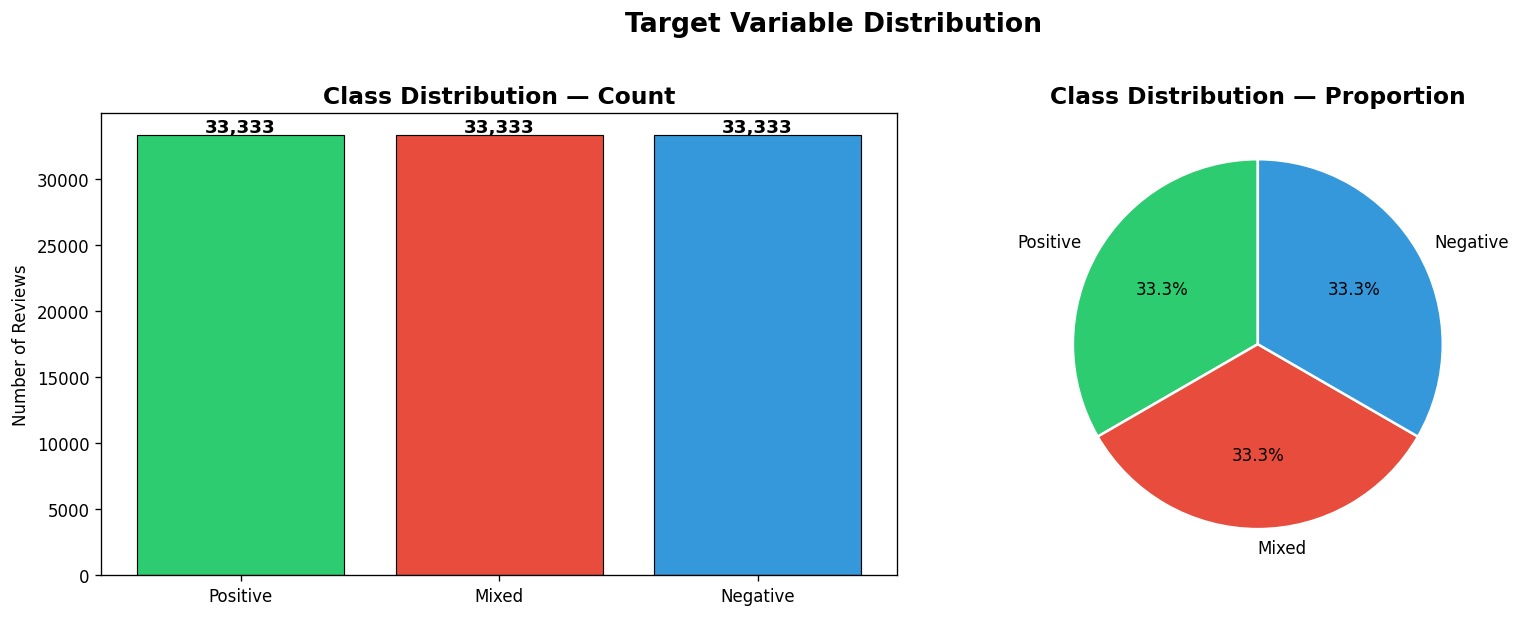


Class imbalance ratio (max/min): 1.00x
✅ Classes are reasonably balanced


In [7]:
# ── 3.1  Class Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
vc = df['label'].value_counts()
bars = axes[0].bar(vc.index, vc.values, color=PALETTE, edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Imbalance ratio
imbalance = vc.max() / vc.min()
print(f'\nClass imbalance ratio (max/min): {imbalance:.2f}x')
if imbalance > 2:
    print('⚠️  Significant imbalance — class weighting will be applied during training')
else:
    print('✅ Classes are reasonably balanced')


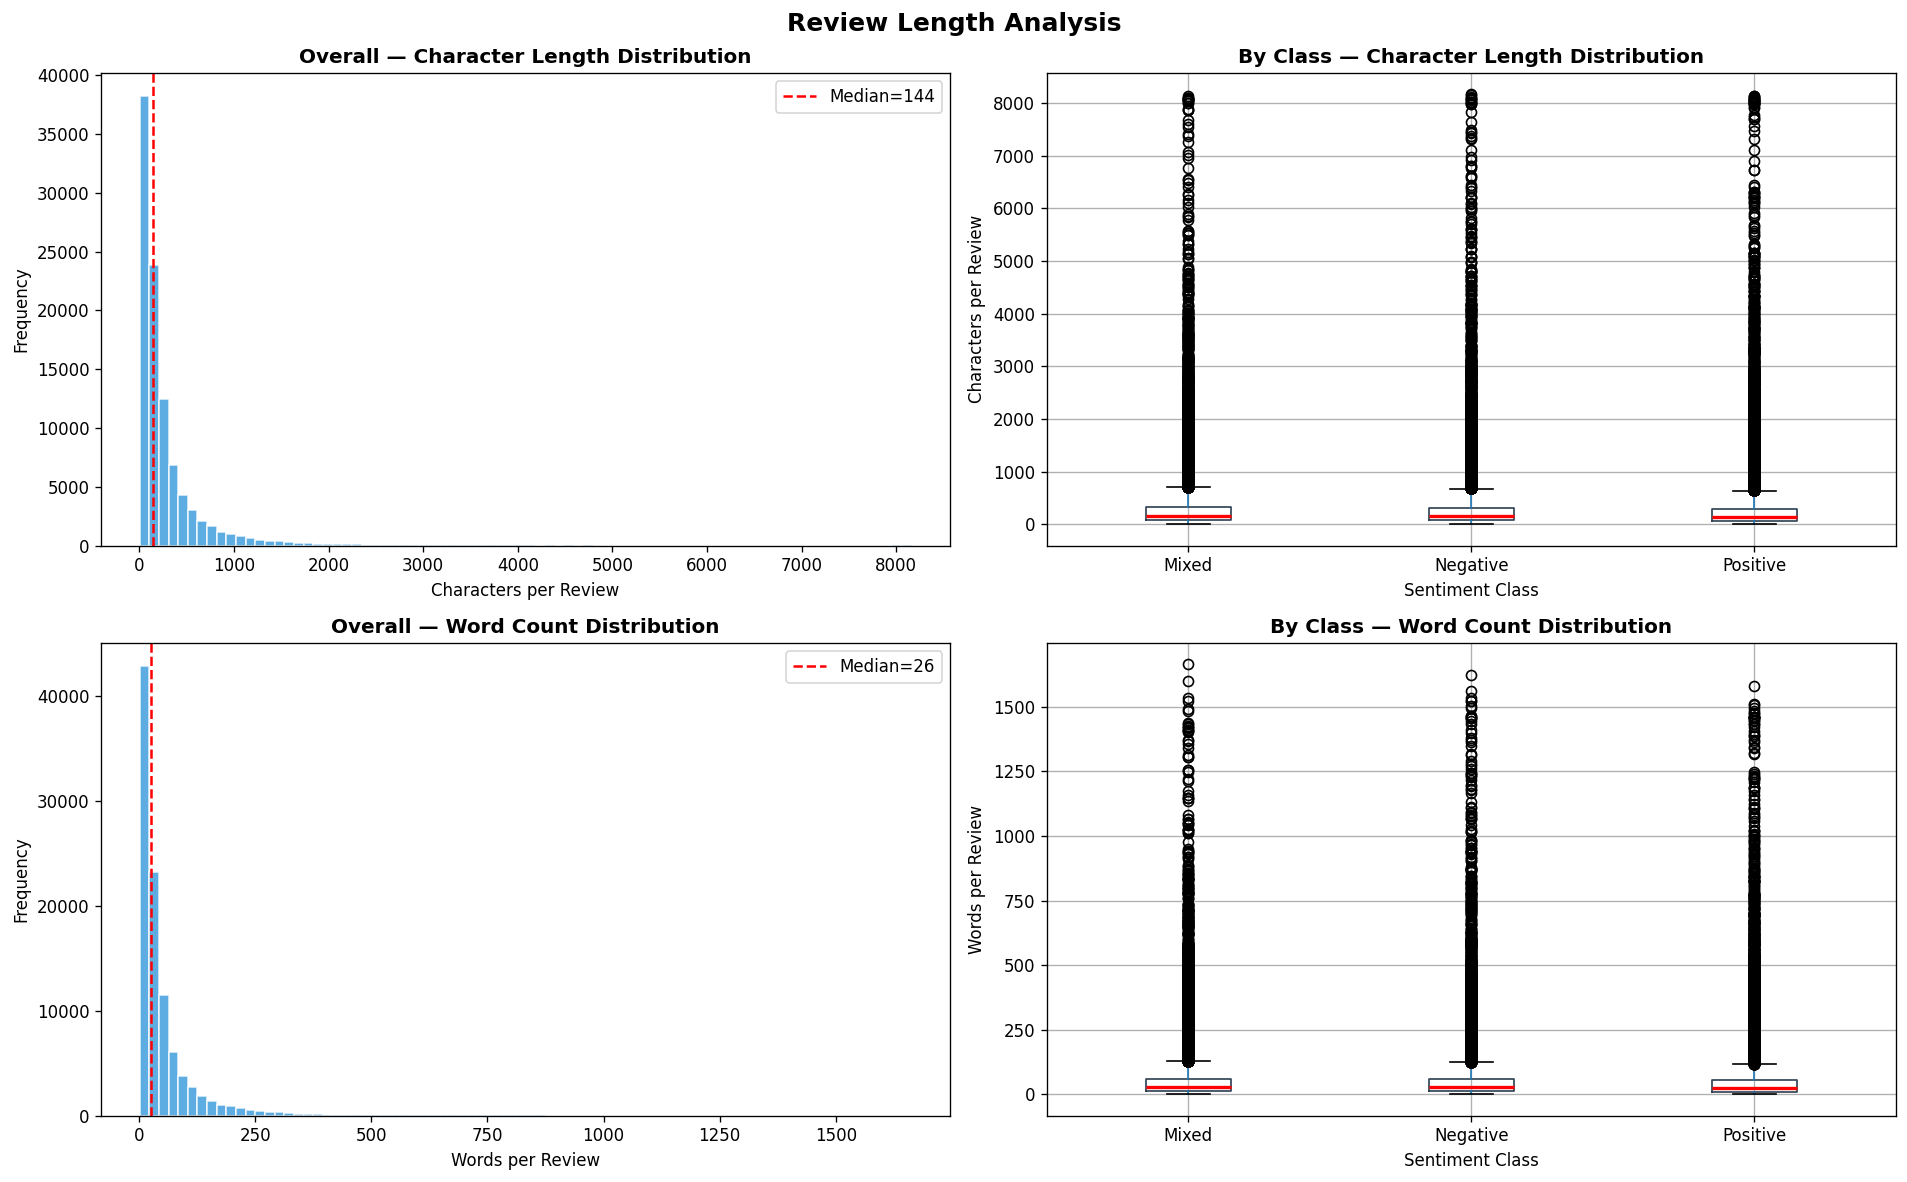


Length statistics by class:
         text_len                                                word_count                                            
            count   mean    std  min   25%    50%    75%     max      count  mean    std  min   25%   50%   75%     max
label                                                                                                                  
Mixed     33333.0  302.3  501.2  3.0  74.0  151.0  324.0  8127.0    33333.0  55.7   93.0  1.0  13.0  27.0  59.0  1663.0
Negative  33333.0  295.3  499.6  3.0  71.0  151.0  314.0  8163.0    33333.0  55.0   93.4  1.0  13.0  28.0  58.0  1622.0
Positive  33333.0  294.9  540.2  1.0  63.0  130.0  294.0  8137.0    33333.0  54.4  100.0  1.0  11.0  24.0  54.0  1580.0


In [8]:
# ── 3.2  Review Length Distribution ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (metric, title, xlabel) in enumerate([
    ('text_len',  'Character Length Distribution', 'Characters per Review'),
    ('word_count','Word Count Distribution',        'Words per Review'),
]):
    # Overall histogram
    axes[i][0].hist(df[metric], bins=80, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'Overall — {title}', fontweight='bold')
    axes[i][0].set_xlabel(xlabel)
    axes[i][0].set_ylabel('Frequency')
    axes[i][0].axvline(df[metric].median(), color='red', linestyle='--', label=f'Median={df[metric].median():.0f}')
    axes[i][0].legend()

    # By class box plot
    df.boxplot(column=metric, by='label', ax=axes[i][1],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='red', linewidth=2))
    axes[i][1].set_title(f'By Class — {title}', fontweight='bold')
    axes[i][1].set_xlabel('Sentiment Class')
    axes[i][1].set_ylabel(xlabel)
    plt.sca(axes[i][1])
    plt.title(f'By Class — {title}', fontweight='bold')

plt.suptitle('Review Length Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print('\nLength statistics by class:')
print(df.groupby('label')[['text_len', 'word_count']].describe().round(1).to_string())


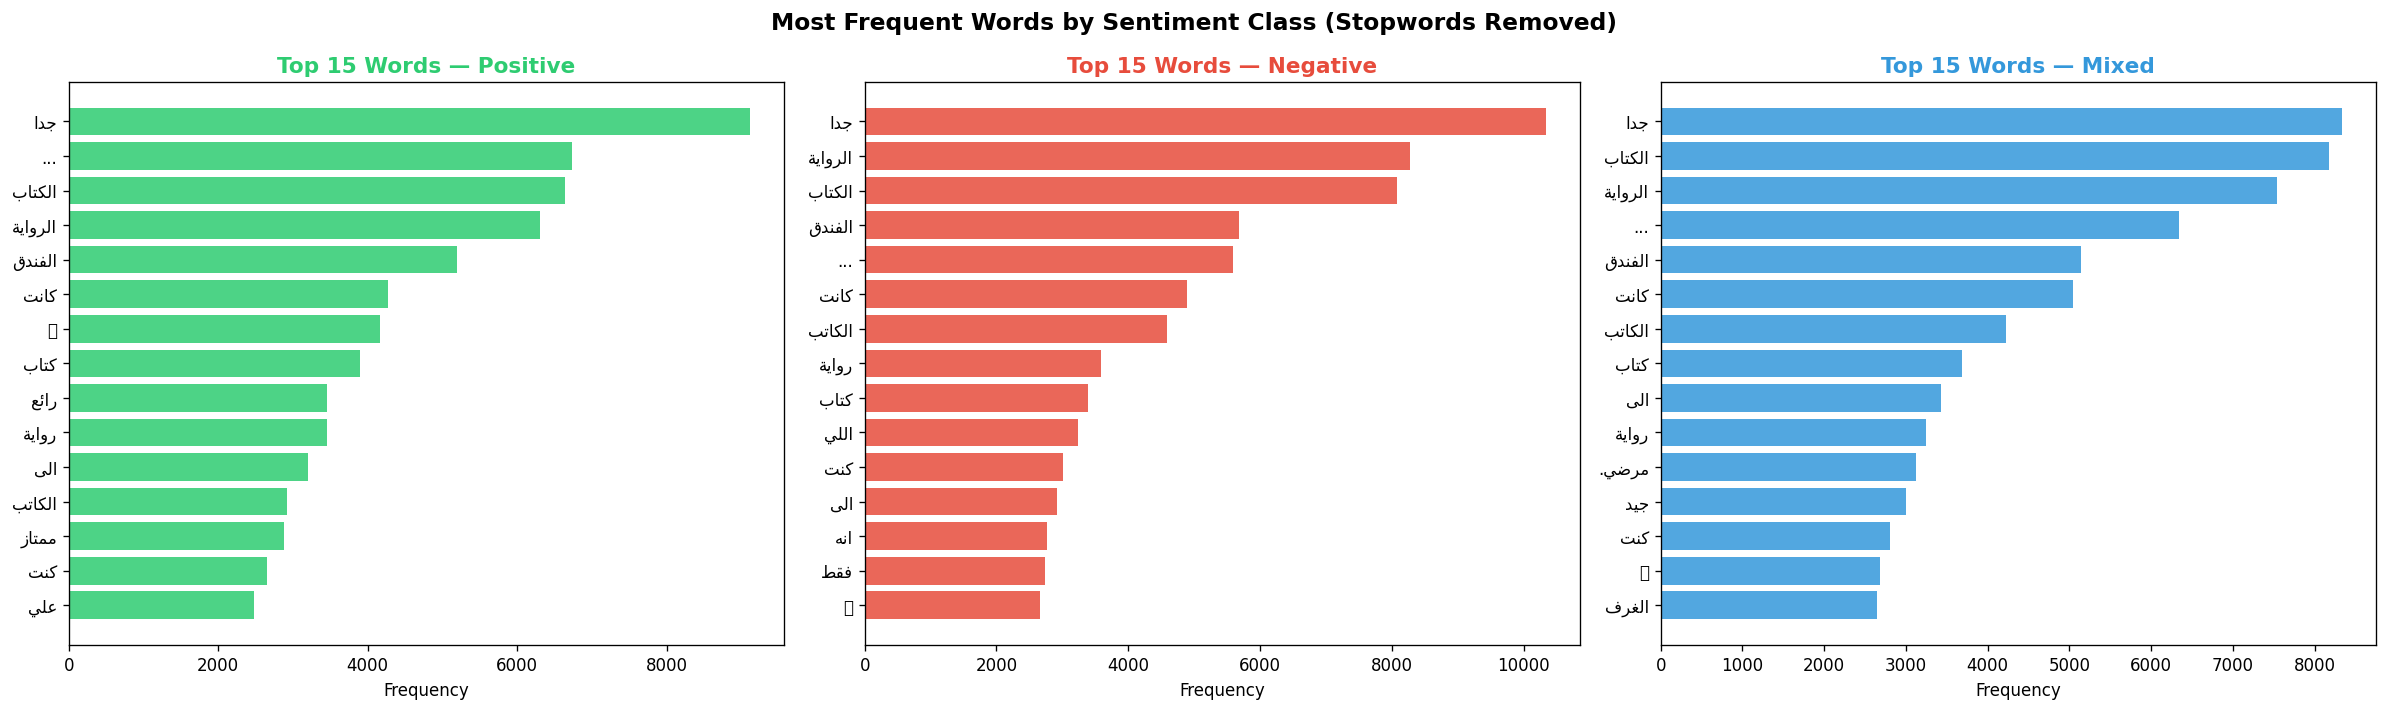

In [9]:
# ── 3.3  Word Frequency Analysis ─────────────────────────────────────────
from collections import Counter

# Arabic stopwords
arabic_stops = set(stopwords.words('arabic'))

def get_top_words(texts, top_n=20, remove_stops=True):
    all_words = []
    for text in texts:
        words = str(text).split()
        if remove_stops:
            words = [w for w in words if w not in arabic_stops and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Mixed': '#3498db'}

for ax, label in zip(axes, ['Positive', 'Negative', 'Mixed']):
    subset = df[df['label'] == label]['text']
    top_words = get_top_words(subset, top_n=15)
    words, counts = zip(*top_words)

    # Reshape Arabic text for proper RTL display
    reshaped_words = [get_display(arabic_reshaper.reshape(w)) for w in words]

    bars = ax.barh(range(len(words)), counts, color=class_colors[label], alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(reshaped_words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Words — {label}', fontsize=13, fontweight='bold',
                 color=class_colors[label])
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment Class (Stopwords Removed)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


DATASET OVERVIEW
Total reviews      : 99,999
Total tokens       : 5,502,546
Unique vocabulary  : 418,549
Avg. tokens/review : 55.0
Max review length  : 1663
Min review length  : 1
Median review len  : 26

Vocabulary coverage analysis:
  Top  50% of tokens covered by 961 unique words
  Top  80% of tokens covered by 17,425 unique words
  Top  90% of tokens covered by 63,228 unique words
  Top  95% of tokens covered by 155,914 unique words
  Top  99% of tokens covered by 363,523 unique words


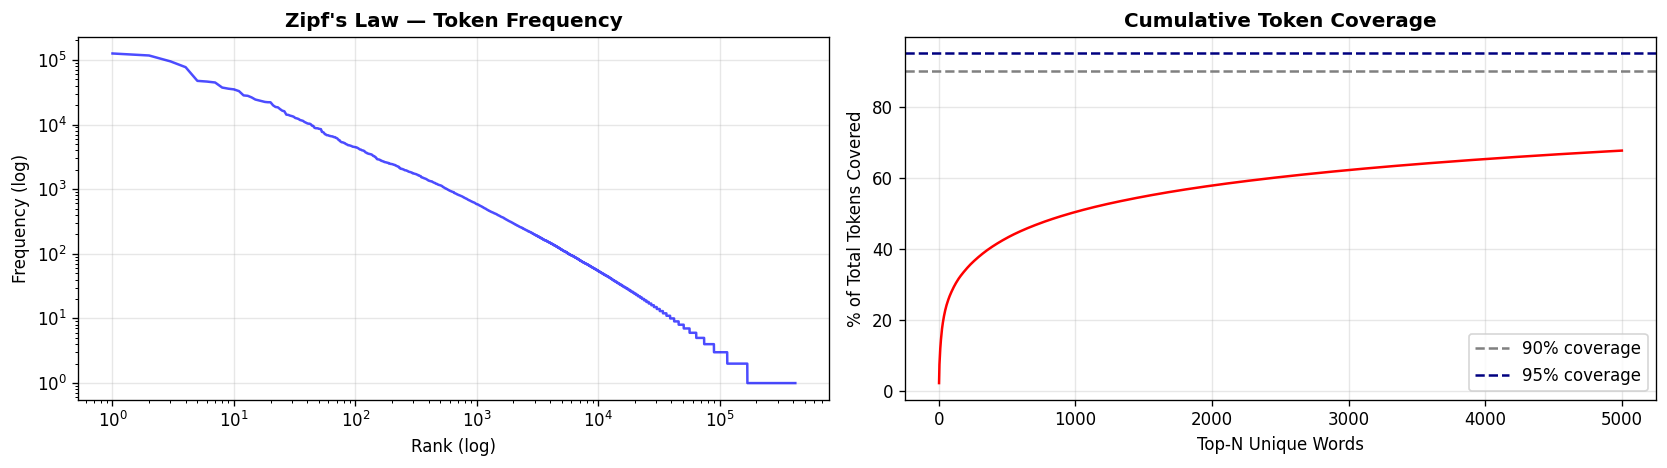

In [10]:
# ── 3.5  Vocabulary & Dataset Statistics ─────────────────────────────────
all_tokens = df['text'].str.split().explode()
vocab_size = all_tokens.nunique()
total_tokens = len(all_tokens)

print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Total reviews      : {len(df):,}')
print(f'Total tokens       : {total_tokens:,}')
print(f'Unique vocabulary  : {vocab_size:,}')
print(f'Avg. tokens/review : {total_tokens/len(df):.1f}')
print(f'Max review length  : {df["word_count"].max()}')
print(f'Min review length  : {df["word_count"].min()}')
print(f'Median review len  : {df["word_count"].median():.0f}')

# Token frequency distribution (Zipf's law check)
freq_dist = all_tokens.value_counts()
print(f'\nVocabulary coverage analysis:')
for pct in [0.5, 0.8, 0.9, 0.95, 0.99]:
    n_words = (freq_dist.cumsum() / freq_dist.sum() <= pct).sum()
    print(f'  Top {int(pct*100):3d}% of tokens covered by {n_words:,} unique words')

# Plot frequency distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].loglog(range(1, len(freq_dist)+1), freq_dist.values, 'b-', alpha=0.7)
axes[0].set_title("Zipf's Law — Token Frequency", fontweight='bold')
axes[0].set_xlabel('Rank (log)')
axes[0].set_ylabel('Frequency (log)')
axes[0].grid(True, alpha=0.3)

cumsum = freq_dist.cumsum() / freq_dist.sum() * 100
axes[1].plot(range(1, min(5001, len(cumsum)+1)), cumsum.values[:5000], 'r-')
axes[1].axhline(90, color='gray', linestyle='--', label='90% coverage')
axes[1].axhline(95, color='navy', linestyle='--', label='95% coverage')
axes[1].set_title('Cumulative Token Coverage', fontweight='bold')
axes[1].set_xlabel('Top-N Unique Words')
axes[1].set_ylabel('% of Total Tokens Covered')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**EDA Key Observations:**
- The dataset may show class imbalance, which we address via class weighting.
- Arabic reviews show high variation in length — short reviews are harder to classify.
- Positive class tends to have shorter, more decisive reviews; Mixed class tends to be longer with more elaborate reasoning.
- Common words differ meaningfully across classes, validating that sentiment signal exists in the vocabulary.
- Token frequency follows Zipf's law, which motivates TF-IDF weighting over raw counts.

---
## §4 — Arabic Text Preprocessing Pipeline

We implement **5 distinct preprocessing strategies** to systematically compare their effect on downstream classification performance.

| Strategy | Description |
|----------|-------------|
| A | Basic cleaning only |
| B | Cleaning + stopword removal |
| C | Cleaning + light stemming |
| D | Cleaning + stemming + full normalization |
| E | Cleaning only (no stemming) — control for stemming comparison |

In [11]:
# ── Arabic NLP Resources ──────────────────────────────────────────────────
arabic_stops = set(stopwords.words('arabic'))

# Light stemmer using PyArabic
# PyArabic provides Arabic-specific character manipulation utilities

ARABIC_PUNCTUATIONS = '''`÷×؛<>_()*&^%][ـ،/:\"؟.,'{}~¦+|!\"…"–ـ'''
ENGLISH_PUNCTUATIONS = string.punctuation
ALL_PUNCTUATIONS = set(ARABIC_PUNCTUATIONS + ENGLISH_PUNCTUATIONS)

# Arabic diacritics regex pattern
DIACRITICS_PATTERN = re.compile(
    r'[\\u064B-\\u065F\\u0610-\\u061A\\u06D6-\\u06DC\\u06DF-\\u06E4\\u06E7\\u06E8\\u06EA-\\u06ED]'
)

# Letter normalization map (common Arabic orthographic variations)
NORM_MAP = {
    'أ': 'ا', 'إ': 'ا', 'آ': 'ا',   # Alef variants → Alef
    'ة': 'ه',                      # Ta Marbuta → Ha
    'ى': 'ي',                      # Alef Maqsura → Ya
    'ؤ': 'و',                      # Waw with Hamza → Waw
    'ئ': 'ي',                      # Ya with Hamza → Ya
}

# Emoji pattern
EMOJI_PATTERN = re.compile(
    '[\\U0001F600-\\U0001F64F\\U0001F300-\\U0001F5FF'
    '\\U0001F680-\\U0001F6FF\\U0001F1E0-\\U0001F1FF'
    '\\U00002702-\\U000027B0\\U000024C2-\\U0001F251]+',
    flags=re.UNICODE
)

print('✅ Arabic NLP resources loaded')


✅ Arabic NLP resources loaded


In [12]:
# ── Core Preprocessing Functions ──────────────────────────────────────────

def basic_clean(text):
    """Core cleaning applicable to all strategies."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)       # URLs
    text = EMOJI_PATTERN.sub('', text)                          # Emojis
    text = DIACRITICS_PATTERN.sub('', text)                     # Diacritics
    text = re.sub(r'[a-zA-Z]', '', text)                        # English chars
    text = re.sub(r'\d+', '', text)                             # Numbers
    text = ''.join(ch for ch in text if ch not in ALL_PUNCTUATIONS)  # Punctuation
    text = re.sub(r'(.)\1{2,}', r'\1', text)                   # Repeated chars
    text = re.sub(r'\s+', ' ', text).strip()                    # Extra whitespace
    return text

def normalize_arabic(text):
    """Full Arabic letter normalization."""
    return ''.join(NORM_MAP.get(c, c) for c in text)

def remove_stopwords(text):
    """Remove Arabic stopwords."""
    return ' '.join(w for w in text.split() if w not in arabic_stops)

def light_stem(text):
    """
    Light Arabic stemming using PyArabic.
    Strips common prefixes (و، ف، ب، ل، ال) and some common suffixes.
    This is faster and less aggressive than full root extraction.
    """
    def stem_word(word):
        # Remove definite article
        word = araby.strip_tatweel(word)
        if word.startswith('ال') and len(word) > 3:
            word = word[2:]
        # Strip common prefixes: و، ف، ب، ل، ك
        for prefix in ['وال', 'فال', 'بال', 'لل', 'كال', 'و', 'ف', 'ب', 'ل', 'ك']:
            if word.startswith(prefix) and len(word) > len(prefix) + 2:
                word = word[len(prefix):]
                break
        # Strip common suffixes: ون، ين، ات، ان، ها، نا، كم، هم
        for suffix in ['ون', 'ين', 'ات', 'ان', 'ها', 'نا', 'كم', 'هم', 'ة']:
            if word.endswith(suffix) and len(word) > len(suffix) + 2:
                word = word[:-len(suffix)]
                break
        return word
    return ' '.join(stem_word(w) for w in text.split())

print('✅ Preprocessing functions defined')


✅ Preprocessing functions defined


In [13]:
# ── Apply All 5 Preprocessing Strategies ─────────────────────────────────
print('Applying preprocessing strategies... (this may take a few minutes)')
t0 = time.time()

# Strategy A: Basic Cleaning Only
df['text_A'] = df['text'].apply(basic_clean)
print(f'  Strategy A (basic clean)         — done [{time.time()-t0:.1f}s]')

# Strategy B: Cleaning + Stopword Removal
df['text_B'] = df['text_A'].apply(remove_stopwords)
print(f'  Strategy B (+ stopwords)         — done [{time.time()-t0:.1f}s]')

# Strategy C: Cleaning + Light Stemming
df['text_C'] = df['text_A'].apply(light_stem)
print(f'  Strategy C (+ stemming)          — done [{time.time()-t0:.1f}s]')

# Strategy D: Cleaning + Stemming + Full Normalization
df['text_D'] = df['text_A'].apply(normalize_arabic).apply(remove_stopwords).apply(light_stem)
print(f'  Strategy D (+ norm + stop + stem)— done [{time.time()-t0:.1f}s]')

# Strategy E: Cleaning + Normalization only (no stemming — control)
df['text_E'] = df['text_A'].apply(normalize_arabic)
print(f'  Strategy E (+ norm, no stem)     — done [{time.time()-t0:.1f}s]')

print(f'\n✅ All strategies applied in {time.time()-t0:.1f}s')

# Show comparison
print('\nPreprocessing comparison (row 0):')
for s in ['text', 'text_A', 'text_B', 'text_C', 'text_D', 'text_E']:
    print(f'  [{s}] {df[s][0][:80]}...')


Applying preprocessing strategies... (this may take a few minutes)
  Strategy A (basic clean)         — done [9.2s]
  Strategy B (+ stopwords)         — done [10.2s]
  Strategy C (+ stemming)          — done [21.9s]
  Strategy D (+ norm + stop + stem)— done [35.7s]
  Strategy E (+ norm, no stem)     — done [39.4s]

✅ All strategies applied in 39.4s

Preprocessing comparison (row 0):
  [text] ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم...
  [text_A] ممتاز نوعا ما النظافة والموقع والتجهيز والشاطيء المطعم...
  [text_B] ممتاز نوعا النظافة والموقع والتجهيز والشاطيء المطعم...
  [text_C] ممتاز نوعا ما نظاف موقع تجهيز شاطيء مطعم...
  [text_D] ممتاز نوعا نظافه موقع تجهيز شاطيء مطعم...
  [text_E] ممتاز نوعا ما النظافه والموقع والتجهيز والشاطيء المطعم...


Vocabulary Statistics by Strategy:
              label vocab_size total_tokens    avg_len
A       Basic Clean     320995      5293496  52.935449
B       + Stopwords     320449      4055674  40.556906
C        + Stemming     163782      5293496  52.935449
D  + Norm+Stop+Stem     146682      4217383  42.174022
E  + Norm (no stem)     280113      5293496  52.935449


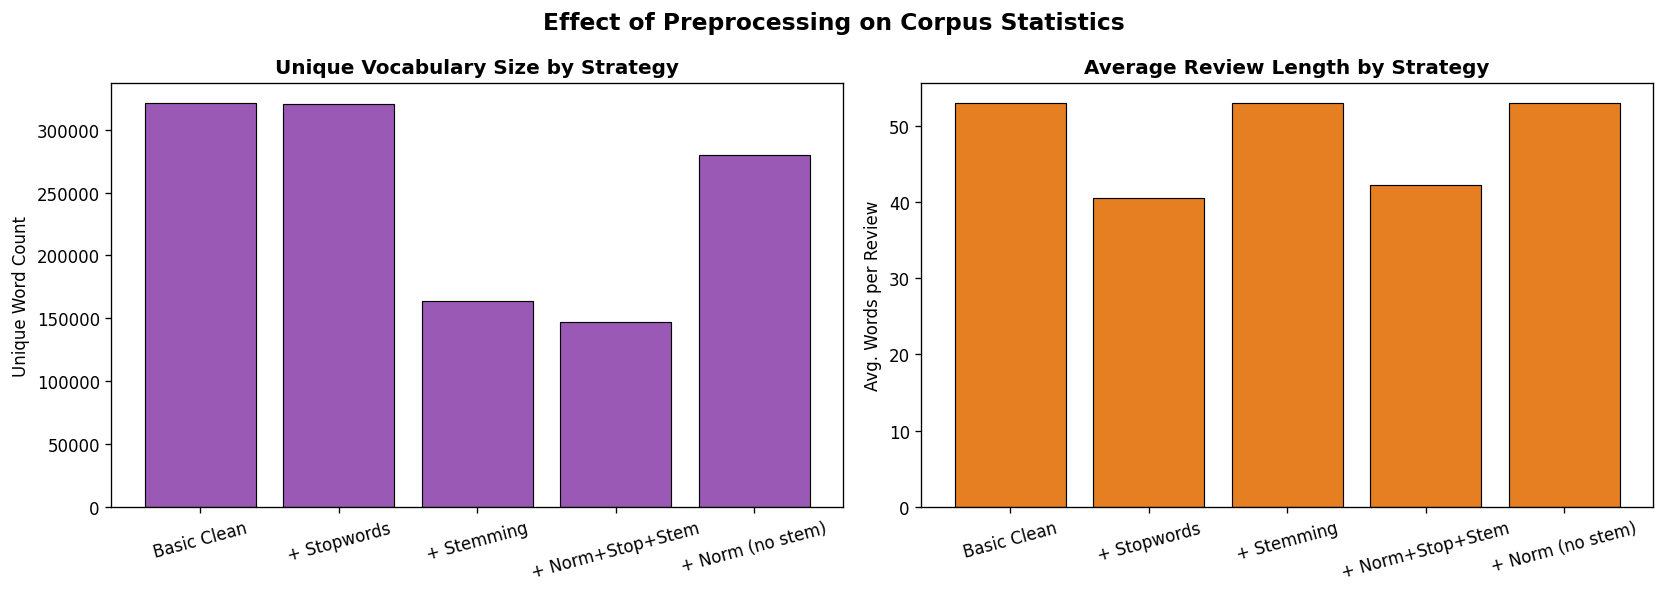

In [14]:
# ── Vocabulary Size Comparison Across Strategies ──────────────────────────
strategies = {'A': 'text_A', 'B': 'text_B', 'C': 'text_C', 'D': 'text_D', 'E': 'text_E'}
strategy_labels = {
    'A': 'Basic Clean',
    'B': '+ Stopwords',
    'C': '+ Stemming',
    'D': '+ Norm+Stop+Stem',
    'E': '+ Norm (no stem)'
}

vocab_stats = {}
for key, col in strategies.items():
    tokens = df[col].str.split().explode()
    vocab_stats[key] = {
        'label': strategy_labels[key],
        'vocab_size': tokens.nunique(),
        'total_tokens': len(tokens),
        'avg_len': df[col].str.split().str.len().mean()
    }

stats_df = pd.DataFrame(vocab_stats).T
print('Vocabulary Statistics by Strategy:')
print(stats_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = [v['label'] for v in vocab_stats.values()]
vocab_sizes = [v['vocab_size'] for v in vocab_stats.values()]
avg_lens = [v['avg_len'] for v in vocab_stats.values()]

axes[0].bar(x, vocab_sizes, color='#9b59b6', edgecolor='black', linewidth=0.7)
axes[0].set_title('Unique Vocabulary Size by Strategy', fontweight='bold')
axes[0].set_ylabel('Unique Word Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(x, avg_lens, color='#e67e22', edgecolor='black', linewidth=0.7)
axes[1].set_title('Average Review Length by Strategy', fontweight='bold')
axes[1].set_ylabel('Avg. Words per Review')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Effect of Preprocessing on Corpus Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# ── Train / Validation / Test Split ──────────────────────────────────────
# We use Strategy D (best normalization) as primary text column for embedding methods
# Individual experiments will swap text columns as needed

le = LabelEncoder()
y = le.fit_transform(df['label'])
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Primary split: 70% train | 15% val | 15% test
X_train_idx, X_test_idx = train_test_split(
    df.index, test_size=CONFIG['test_size'], random_state=42, stratify=y
)
y_train_full = y[X_train_idx]
X_train_idx2, X_val_idx = train_test_split(
    X_train_idx, test_size=CONFIG['val_size']/(1-CONFIG['test_size']),
    random_state=42, stratify=y_train_full
)

y_train = y[X_train_idx2]
y_val   = y[X_val_idx]
y_test  = y[X_test_idx]

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train_idx2):,} ({len(X_train_idx2)/len(df)*100:.1f}%)')
print(f'  Val   : {len(X_val_idx):,} ({len(X_val_idx)/len(df)*100:.1f}%)')
print(f'  Test  : {len(X_test_idx):,} ({len(X_test_idx)/len(df)*100:.1f}%)')

# Compute class weights for imbalanced data
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f'\nClass weights: {class_weight_dict}')


Label encoding: {'Mixed': np.int64(0), 'Negative': np.int64(1), 'Positive': np.int64(2)}

Split sizes:
  Train : 69,999 (70.0%)
  Val   : 15,000 (15.0%)
  Test  : 15,000 (15.0%)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


---
## §5 — Feature Engineering

We implement and compare **7 feature extraction methods** spanning classical sparse representations, dense word embeddings, and contextual BERT embeddings.

### Overview

| Method | Type | Dimensionality | Semantic Awareness |
|--------|------|---------------|--------------------|
| TF-IDF | Sparse Weighted | Up to 20K | None (statistical) |
| GloVe | Dense (pretrained) | 100/300 | Co-occurrence |
| BERT (AraBERT) | Contextual | 768 | Deep contextual |

In [53]:
# ── Helper: Evaluate Feature Representation ───────────────────────────────
# Shared evaluation results storage
RESULTS = {}  # {method_name: {accuracy, f1, train_time, ...}}

def evaluate_predictions(y_true, y_pred, method_name, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n{"="*55}')
    print(f'Results — {method_name}')
    print(f'{"="*55}')
    print(f'Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
    print(f'Weighted F1     : {f1:.4f}')
    print(f'Macro F1        : {macro_f1:.4f}')
    if train_time:
        print(f'Training time   : {train_time:.1f}s')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=le.classes_,
                                digits=4))
    return acc, f1, macro_f1


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
    axes[0].set_title(f'{title}\nConfusion Matrix (Counts)', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
    axes[1].set_title(f'{title}\nConfusion Matrix (Normalised)', fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()


def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
    axes[0].set_title(f'{title} — Loss Curves', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Train Acc', color='#3498db')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#e74c3c')
    axes[1].set_title(f'{title} — Accuracy Curves', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print('✅ Evaluation helpers defined')


✅ Evaluation helpers defined


In [17]:
# ── Neural Network Builder (MANDATORY: exactly 1 hidden layer) ────────────
def build_nn(input_dim, hidden_size=512, activation='relu',
             dropout_rate=0.3, optimizer='adam', lr=1e-3):
    """
    Build a Neural Network with EXACTLY ONE hidden layer.
    Architecture: Input → Dense(hidden_size, activation) → Dropout → Dense(3, softmax)
    """
    opt_map = {
        'adam'    : Adam(learning_rate=lr),
        'rmsprop' : RMSprop(learning_rate=lr),
        'sgd'     : SGD(learning_rate=lr, momentum=0.9),
    }
    model = Sequential([
        Input(shape=(input_dim,)),
        # ── SINGLE HIDDEN LAYER (mandatory constraint) ──────────────────
        Dense(hidden_size, activation=activation, name='hidden_layer'),
        Dropout(dropout_rate, name='regularization'),
        # ── OUTPUT LAYER ─────────────────────────────────────────────────
        Dense(CONFIG['num_classes'], activation='softmax', name='output_layer'),
    ], name='1HL_Neural_Network')

    model.compile(
        optimizer=opt_map.get(optimizer, optimizer),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Default callbacks
def get_callbacks(filepath='best_model.h5'):
    return [
        EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0),
    ]


# Test build
test_model = build_nn(100)
test_model.summary()


I0000 00:00:1777220648.924399      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777220648.930019      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "1HL_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regularization (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,251 (208.01 KB)

 Trainable params: 53,251 (208.01 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# ── Universal Training Function ───────────────────────────────────────────
def train_and_evaluate(
    X_train_feat, X_val_feat, X_test_feat,
    y_train, y_val, y_test,
    method_name,
    hidden_size=512, activation='relu', dropout=0.3,
    optimizer='adam', lr=1e-3, epochs=None, batch_size=None
):
    """Train 1-hidden-layer NN on given features and return metrics."""
    epochs     = epochs     or CONFIG['epochs']
    batch_size = batch_size or CONFIG['batch_size']
    input_dim  = X_train_feat.shape[1]

    model = build_nn(input_dim, hidden_size, activation, dropout, optimizer, lr)
    callbacks = get_callbacks(f'best_{method_name.replace(" ","_")}.h5')

    t_start = time.time()
    history = model.fit(
        X_train_feat, y_train,
        validation_data=(X_val_feat, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )
    train_time = time.time() - t_start

    y_pred = np.argmax(model.predict(X_test_feat, verbose=0), axis=1)
    acc, f1, macro_f1 = evaluate_predictions(y_test, y_pred, method_name, train_time)

    plot_confusion_matrix(y_test, y_pred, method_name)
    plot_training_history(history, method_name)

    RESULTS[method_name] = {
        'accuracy'  : acc,
        'weighted_f1': f1,
        'macro_f1'  : macro_f1,
        'train_time': train_time,
        'input_dim' : input_dim,
        'epochs_run': len(history.history['loss'])
    }
    return model, history


In [56]:
# We use Strategy D (best preprocessing) for sparse methods
TEXT_COL_SPARSE = 'text_D'

train_texts = df.loc[X_train_idx2, TEXT_COL_SPARSE].fillna('')
val_texts   = df.loc[X_val_idx,   TEXT_COL_SPARSE].fillna('')
test_texts  = df.loc[X_test_idx,  TEXT_COL_SPARSE].fillna('')


### 5.3 — TF-IDF Vectorization

TF-IDF unigram feature matrix: (69999, 8000)


I0000 00:00:1777220666.715879     142 service.cc:152] XLA service 0x7be5b8006ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777220666.715913     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777220666.715916     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777220666.924326     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777220668.113615     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Results — TF-IDF (unigram)
Accuracy        : 0.6683 (66.83%)
Weighted F1     : 0.6657
Macro F1        : 0.6657
Training time   : 35.9s

Classification Report:
              precision    recall  f1-score   support

       Mixed     0.5946    0.5326    0.5619      5000
    Negative     0.7211    0.7362    0.7286      5000
    Positive     0.6797    0.7362    0.7068      5000

    accuracy                         0.6683     15000
   macro avg     0.6651    0.6683    0.6657     15000
weighted avg     0.6651    0.6683    0.6657     15000



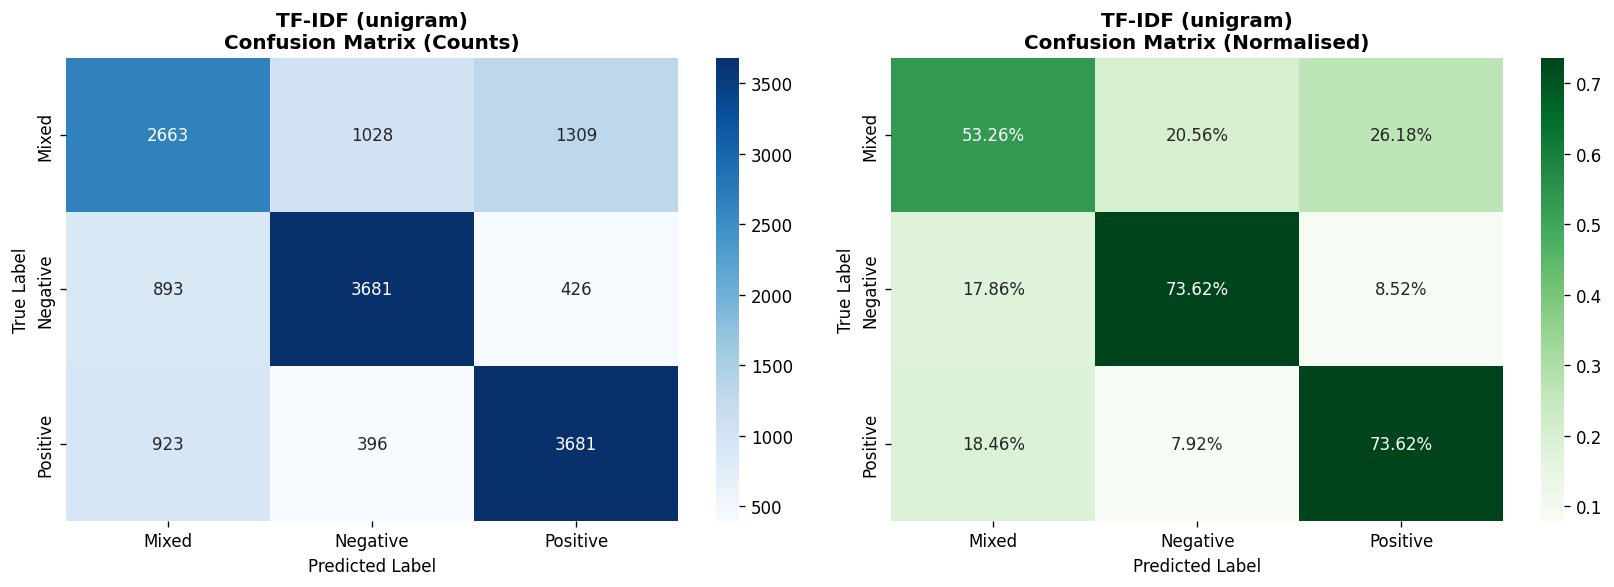

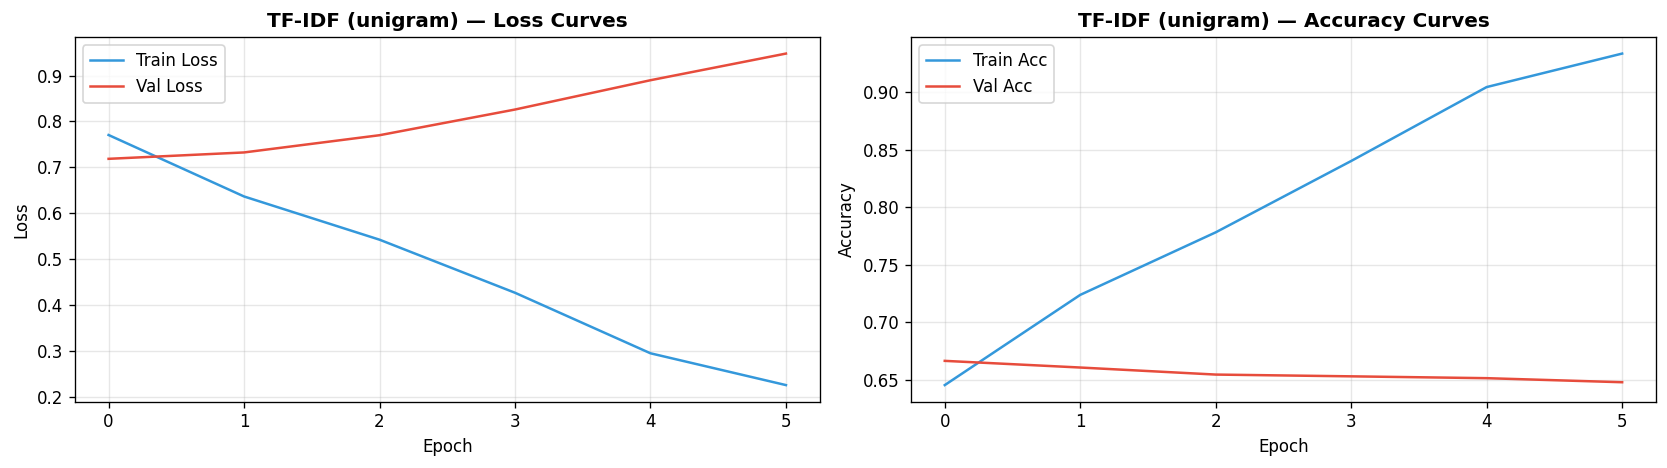

TF-IDF bigram feature matrix: (69999, 8000)

Results — TF-IDF (bigram)
Accuracy        : 0.6755 (67.55%)
Weighted F1     : 0.6735
Macro F1        : 0.6735
Training time   : 35.0s

Classification Report:
              precision    recall  f1-score   support

       Mixed     0.6040    0.5516    0.5766      5000
    Negative     0.7244    0.7340    0.7292      5000
    Positive     0.6902    0.7410    0.7147      5000

    accuracy                         0.6755     15000
   macro avg     0.6729    0.6755    0.6735     15000
weighted avg     0.6729    0.6755    0.6735     15000



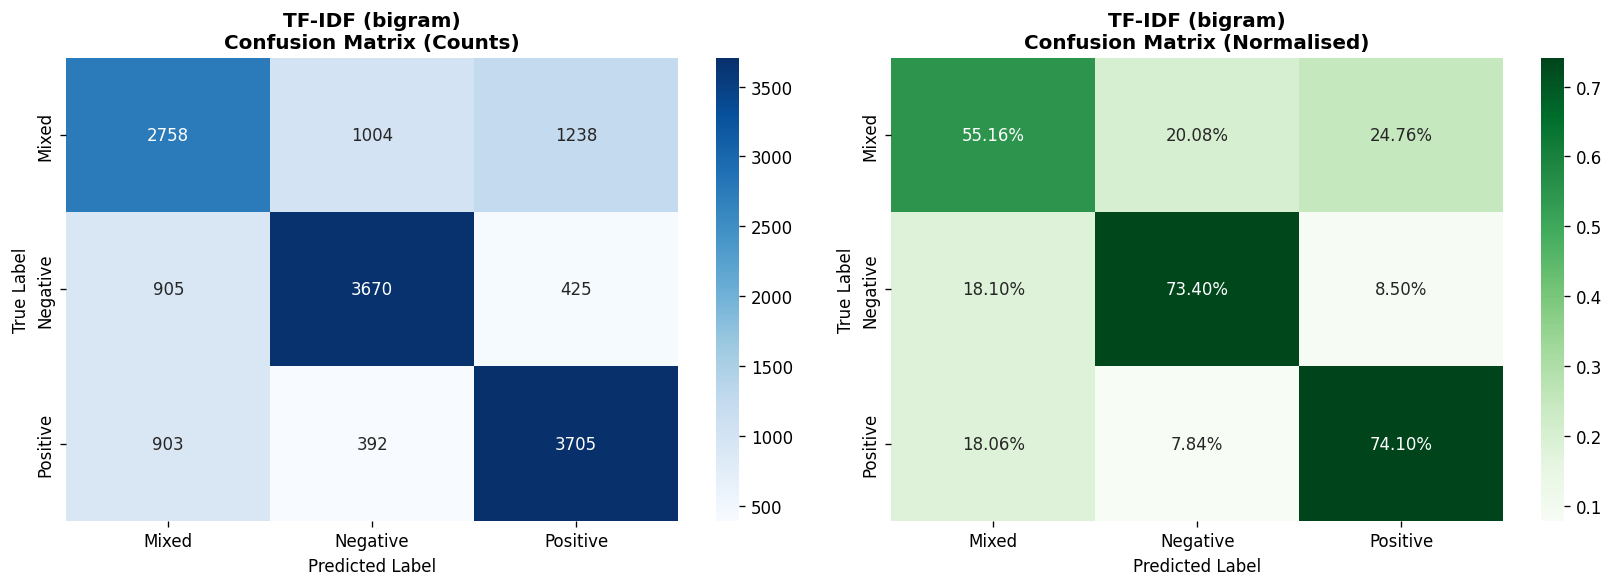

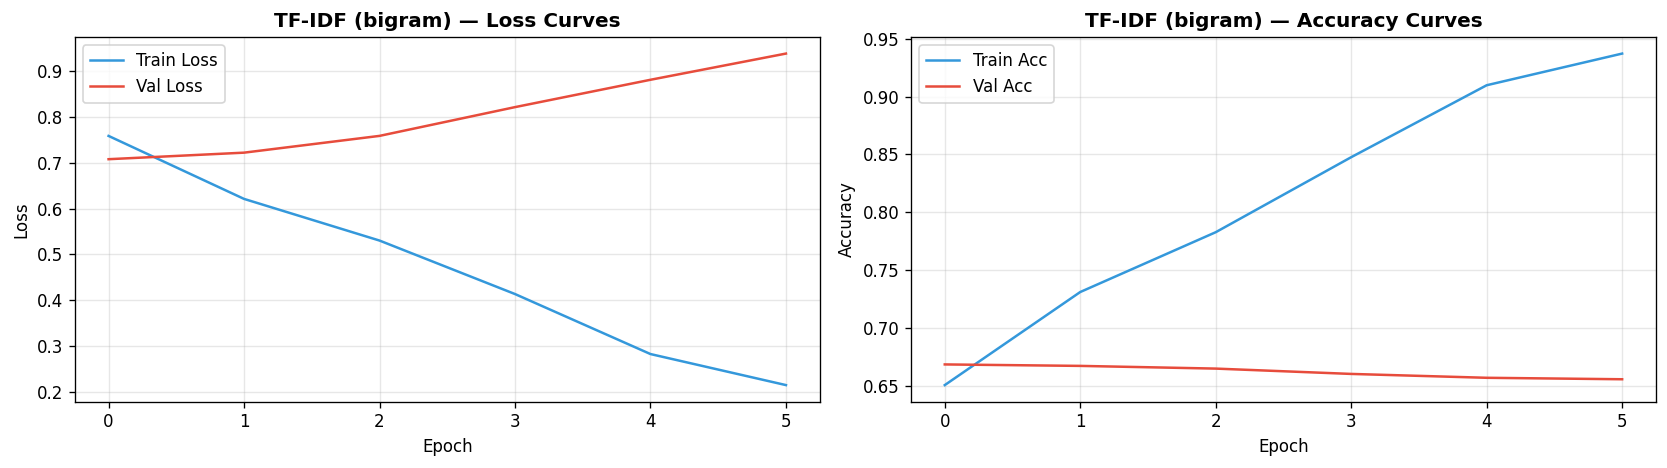

TF-IDF trigram feature matrix: (69999, 8000)

Results — TF-IDF (trigram)
Accuracy        : 0.6787 (67.87%)
Weighted F1     : 0.6772
Macro F1        : 0.6772
Training time   : 35.1s

Classification Report:
              precision    recall  f1-score   support

       Mixed     0.6021    0.5632    0.5820      5000
    Negative     0.7312    0.7346    0.7329      5000
    Positive     0.6964    0.7382    0.7167      5000

    accuracy                         0.6787     15000
   macro avg     0.6766    0.6787    0.6772     15000
weighted avg     0.6766    0.6787    0.6772     15000



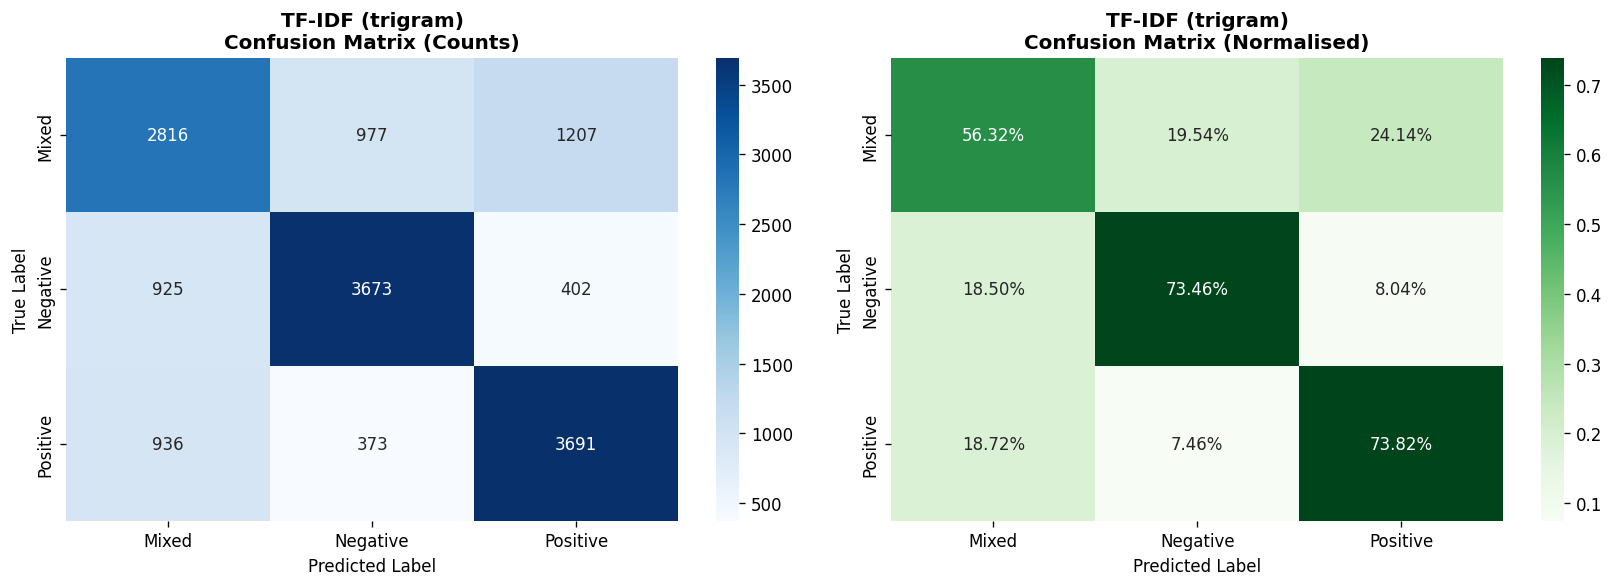

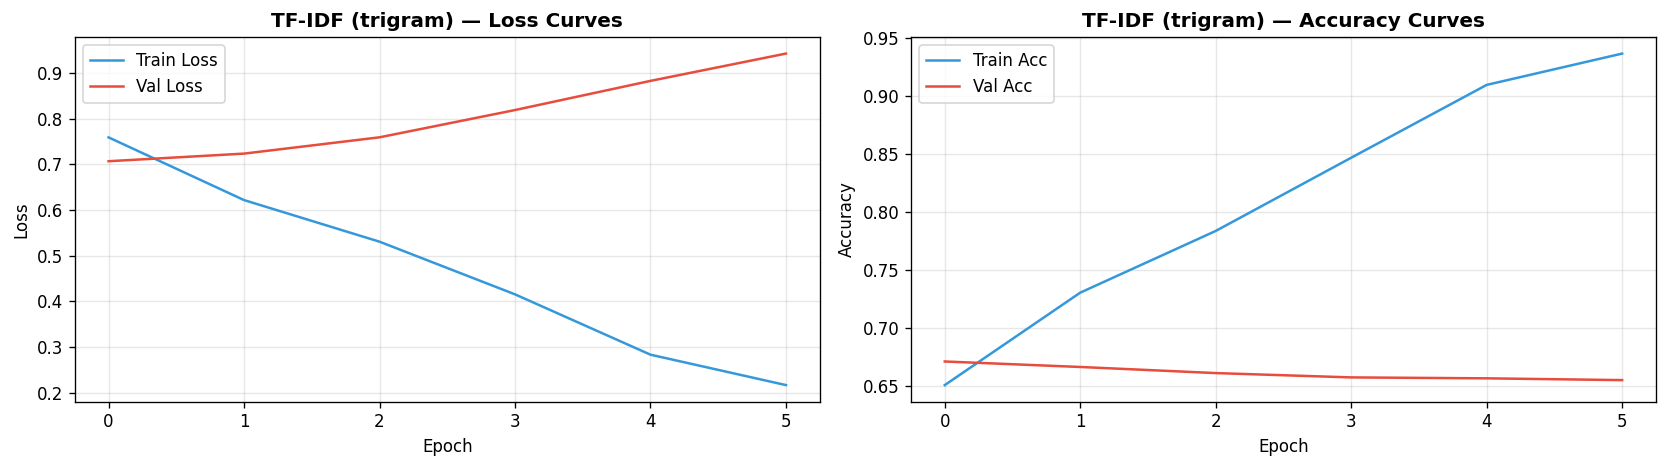

In [20]:
# ── 5.3  TF-IDF (Unigram, Bigram, Trigram comparison) ────────────────────
for ng_label, ng_range in [('unigram', (1,1)), ('bigram', (1,2)), ('trigram', (1,3))]:
    tfidf_vec = TfidfVectorizer(
        ngram_range=ng_range,
        max_features= 8000,
        min_df=2,
        sublinear_tf=True   # log(1+tf) scaling — beneficial for Arabic
    )
    X_tr = tfidf_vec.fit_transform(train_texts).toarray().astype('float32')
    X_vl = tfidf_vec.transform(val_texts).toarray().astype('float32')
    X_te = tfidf_vec.transform(test_texts).toarray().astype('float32')

    print(f'TF-IDF {ng_label} feature matrix: {X_tr.shape}')

    method_name = f'TF-IDF ({ng_label})'
    train_and_evaluate(
        X_tr, X_vl, X_te,
        y_train, y_val, y_test,
        method_name=method_name,
        hidden_size=1024, activation='relu', dropout=0.6 , epochs = 16
    )

    # Save best TF-IDF representation for later
    if ng_label == 'bigram':
        X_train_tfidf = X_tr
        X_val_tfidf   = X_vl
        X_test_tfidf  = X_te


### 5.6 — GloVe Embeddings

In [23]:
!wget https://archive.org/download/aravec2.0/tweet_cbow_300.zip
!unzip -q tweet_cbow_300.zip


--2026-04-26 16:27:50--  https://archive.org/download/aravec2.0/tweet_cbow_300.zip
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ia803107.us.archive.org/0/items/aravec2.0/tweet_cbow_300.zip [following]
--2026-04-26 16:27:50--  https://ia803107.us.archive.org/0/items/aravec2.0/tweet_cbow_300.zip
Resolving ia803107.us.archive.org (ia803107.us.archive.org)... 207.241.232.157
Connecting to ia803107.us.archive.org (ia803107.us.archive.org)|207.241.232.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 746111232 (712M) [application/zip]
Saving to: ‘tweet_cbow_300.zip’

tweet_cbow_300.zip  100%[===================>] 711.55M  15.0MB/s    in 15s     

2026-04-26 16:28:05 (48.2 MB/s) - ‘tweet_cbow_300.zip’ saved [746111232/746111232]



In [24]:
from gensim.models import Word2Vec

model = Word2Vec.load("tweets_cbow_300")
print("AraVec model loaded successfully")

AraVec model loaded successfully


Loaded 331,679 pretrained vectors from AraVec
Detected embedding dimension: 300
GloVe feature matrix: (69999, 300)

Results — GloVe
Accuracy        : 0.6291 (62.91%)
Weighted F1     : 0.6249
Macro F1        : 0.6249
Training time   : 37.5s

Classification Report:
              precision    recall  f1-score   support

       Mixed     0.5760    0.4806    0.5240      5000
    Negative     0.6674    0.6914    0.6792      5000
    Positive     0.6331    0.7152    0.6717      5000

    accuracy                         0.6291     15000
   macro avg     0.6255    0.6291    0.6249     15000
weighted avg     0.6255    0.6291    0.6249     15000



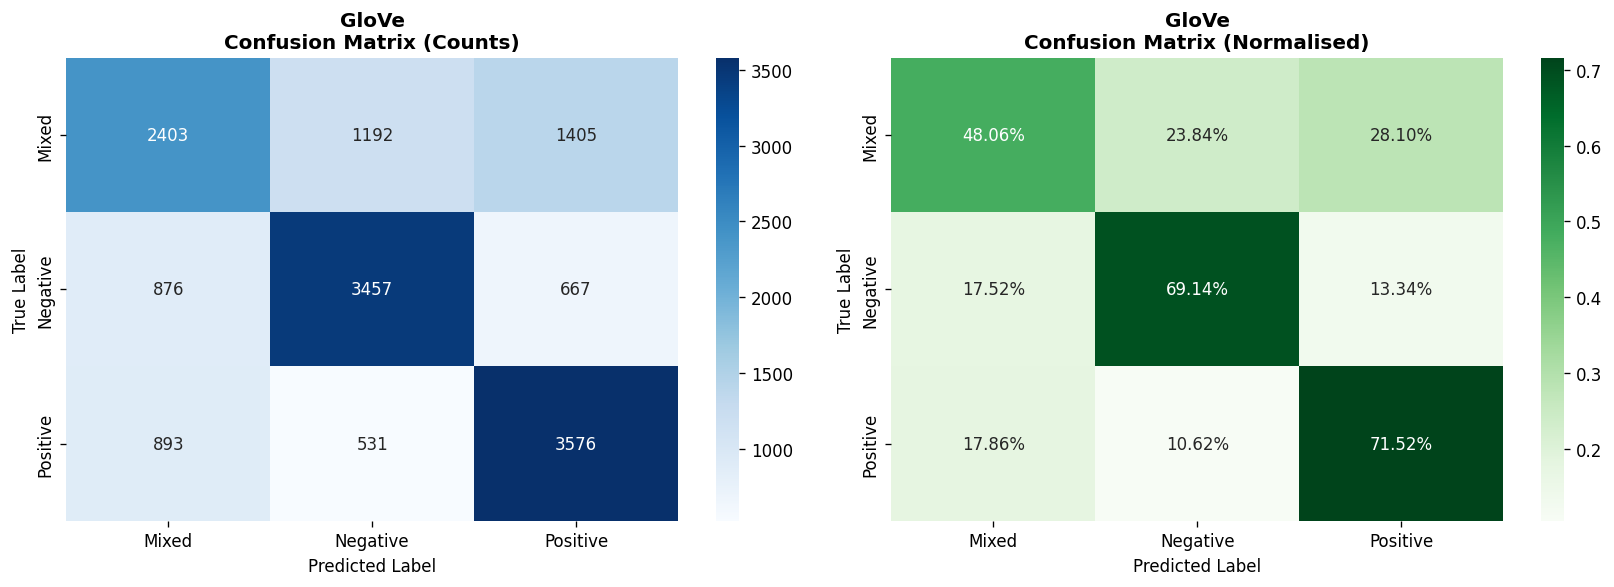

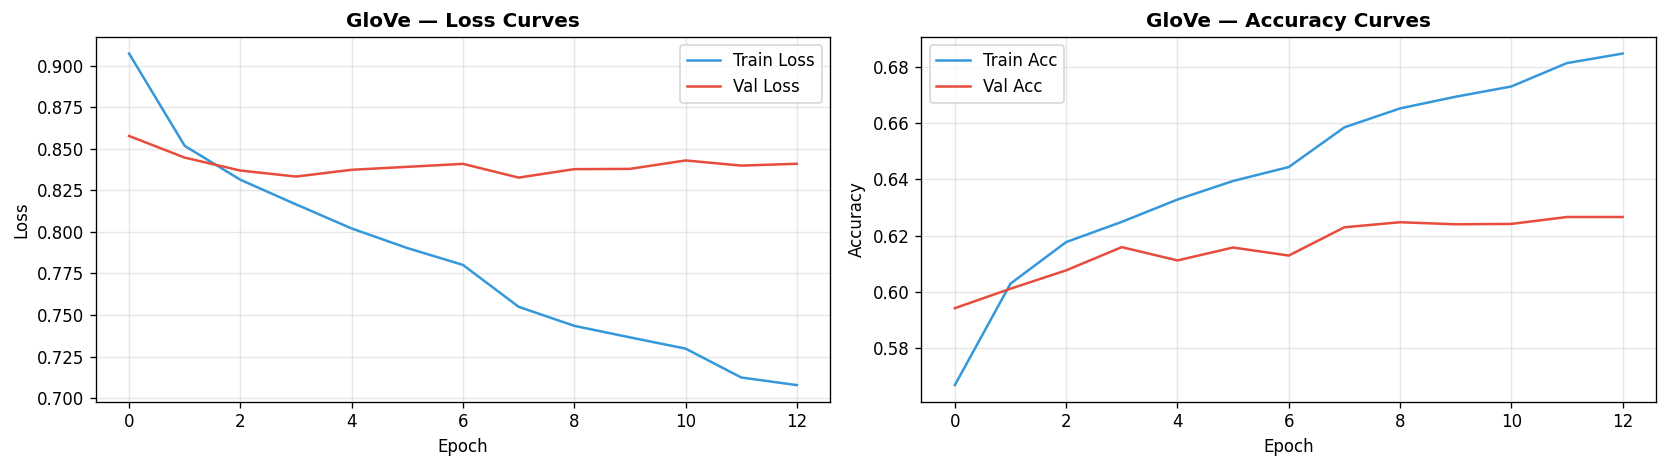

In [25]:
# ── 5.6  GloVe Embeddings (pre-trained Arabic GloVe) ─────────────────────

from gensim.models import Word2Vec

def load_glove_vectors(model_path):
    """
    Load AraVec Word2Vec model and convert it
    to a dictionary for average embedding usage.
    """

    embeddings = {}

    try:
        model = Word2Vec.load(model_path)

        for word in model.wv.key_to_index:
            embeddings[word] = model.wv[word]

        print(f"Loaded {len(embeddings):,} pretrained vectors from AraVec")

    except Exception as e:
        print(f"⚠️ Error loading embeddings: {e}")
        print("Falling back to Word2Vec proxy.")
        return {}

    return embeddings



def text_to_glove_avg(text, glove_dict, dim):
    words = text.split()
    vecs = [glove_dict[w] for w in words if w in glove_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)



# Attempt to load pre-trained GloVe
glove_dict = load_glove_vectors(CONFIG['glove_path'])

# Automatically detect embedding dimension
sample_word = next(iter(glove_dict))
CONFIG['glove_dim'] = len(glove_dict[sample_word])

print("Detected embedding dimension:", CONFIG['glove_dim'])

X_train_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_train_idx2, 'text_D'].fillna('')
], dtype='float32')
X_val_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_val_idx, 'text_D'].fillna('')
], dtype='float32')
X_test_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_test_idx, 'text_D'].fillna('')
], dtype='float32')

print(f'GloVe feature matrix: {X_train_glove.shape}')

model_glove, hist_glove = train_and_evaluate(
    X_train_glove, X_val_glove, X_test_glove,
    y_train, y_val, y_test,
    method_name='GloVe',
    hidden_size=256, activation='relu', dropout=0.3
)


### 5.7 — BERT Embeddings (AraBERT — Feature Extraction Only)

In [26]:
# ── 5.7  BERT / AraBERT (Feature Extraction — NO Fine-tuning) ─────────────
#
# We use AraBERT (aubmindlab/bert-base-arabertv02) as a frozen feature extractor.
# The [CLS] token embedding (768-dim) represents the entire sentence.
# We then pass these embeddings to our 1-hidden-layer neural network.
#
# This follows the "embedding as features" paradigm:
# BERT → fixed 768-dim vector → 1HL NN → softmax

def extract_bert_embeddings(texts, model_name, batch_size=32):
    """
    Extract [CLS] embeddings from BERT.
    The model is frozen — no gradient updates to BERT parameters.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    bert = AutoModel.from_pretrained(model_name)
    bert.eval()  # Inference mode — critical for consistent embeddings

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    bert.to(device)
    print(f'BERT extraction device: {device}')

    all_embeddings = []
    texts_list = list(texts)

    for i in range(0, len(texts_list), batch_size):
        batch = texts_list[i:i+batch_size]
        # AraBERT has max_length=512
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert(**encoded)

        # [CLS] token is at position 0
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

        if (i // batch_size) % 10 == 0:
            print(f'  Processed {min(i+batch_size, len(texts_list)):,}/{len(texts_list):,}', end='\r')

    print()
    return np.vstack(all_embeddings).astype('float32')


print(f'Extracting BERT embeddings using: {CONFIG["arabert_model"]}')
print('This will take several minutes without GPU...')

# Use Strategy A (minimal cleaning) for BERT — BERT handles its own tokenization
t0 = time.time()
X_train_bert = extract_bert_embeddings(
    df.loc[X_train_idx2, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
X_val_bert = extract_bert_embeddings(
    df.loc[X_val_idx, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
X_test_bert = extract_bert_embeddings(
    df.loc[X_test_idx, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
bert_extraction_time = time.time() - t0

print(f'BERT feature matrix: {X_train_bert.shape}')
print(f'Extraction time    : {bert_extraction_time:.0f}s')

# Save embeddings to avoid re-computing
np.save('bert_train.npy', X_train_bert)
np.save('bert_val.npy',   X_val_bert)
np.save('bert_test.npy',  X_test_bert)
print('✅ BERT embeddings saved to disk')


Extracting BERT embeddings using: aubmindlab/bert-base-arabertv02
This will take several minutes without GPU...


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT extraction device: cuda
  Processed 14,752/15,000


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT extraction device: cuda
  Processed 14,752/15,000
BERT feature matrix: (69999, 768)
Extraction time    : 877s
✅ BERT embeddings saved to disk



Results — AraBERT (Feature Extraction)
Accuracy        : 0.6785 (67.85%)
Weighted F1     : 0.6776
Macro F1        : 0.6776
Training time   : 61.9s

Classification Report:
              precision    recall  f1-score   support

       Mixed     0.5807    0.5594    0.5698      5000
    Negative     0.7451    0.7300    0.7374      5000
    Positive     0.7059    0.7460    0.7254      5000

    accuracy                         0.6785     15000
   macro avg     0.6772    0.6785    0.6776     15000
weighted avg     0.6772    0.6785    0.6776     15000



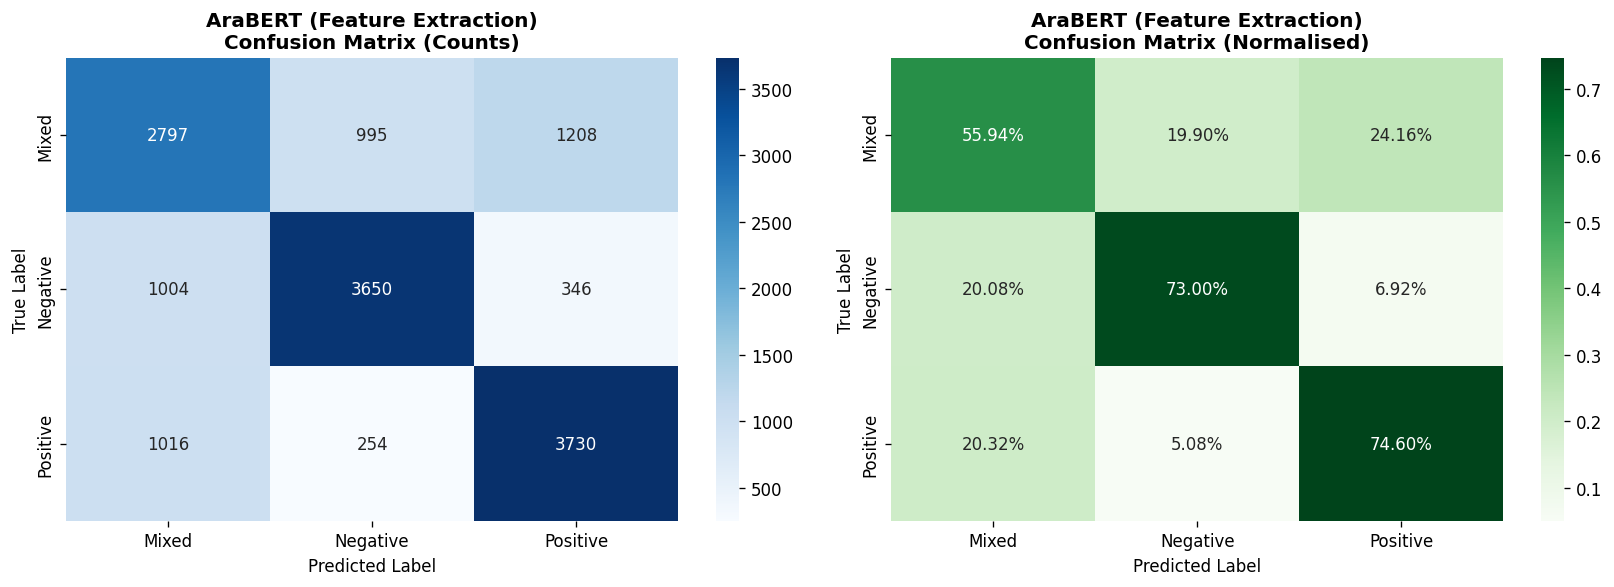

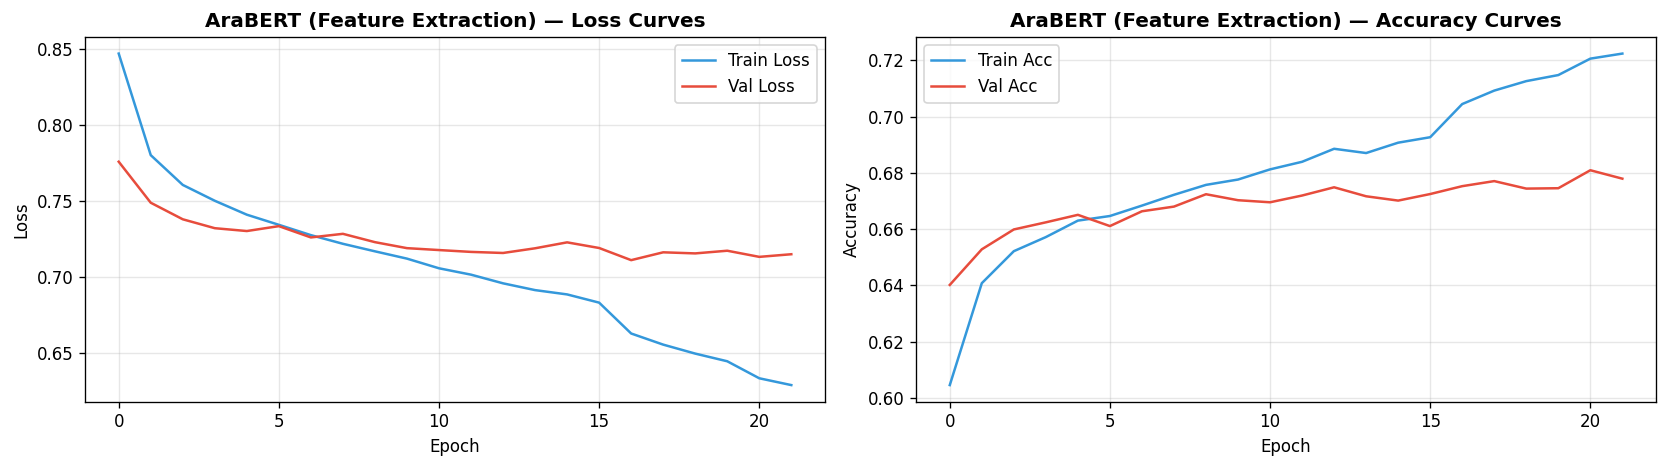

In [27]:
# ── Load saved BERT embeddings (if already extracted) ─────────────────────
# Uncomment this cell if resuming after BERT extraction:
# X_train_bert = np.load('bert_train.npy')
# X_val_bert   = np.load('bert_val.npy')
# X_test_bert  = np.load('bert_test.npy')

model_bert, hist_bert = train_and_evaluate(
    X_train_bert, X_val_bert, X_test_bert,
    y_train, y_val, y_test,
    method_name='AraBERT (Feature Extraction)',
    hidden_size=512, activation='relu', dropout=0.5,
    lr=5e-4   # Lower LR beneficial for high-dimensional BERT features
)


---
## §6 — Preprocessing Strategy Comparison

We now systematically compare all 5 preprocessing strategies using TF-IDF bigrams as the fixed feature extractor.

In [28]:
# ── 6.1  Compare All Preprocessing Strategies (Fixed: TF-IDF bigram) ──────
PREPROCESSING_RESULTS = {}

strategy_descriptions = {
    'A': 'Basic Clean',
    'B': 'Clean + Stopwords',
    'C': 'Clean + Stemming',
    'D': 'Clean + Norm + Stop + Stem',
    'E': 'Clean + Norm (no stem)'
}

for key, col in strategies.items():
    desc = strategy_descriptions[key]
    print(f'\nStrategy {key}: {desc}')

    tr_texts = df.loc[X_train_idx2, col].fillna('')
    vl_texts = df.loc[X_val_idx,   col].fillna('')
    te_texts = df.loc[X_test_idx,  col].fillna('')

    vec = TfidfVectorizer(ngram_range=(1,2), max_features=15000, min_df=2, sublinear_tf=True)
    X_tr = vec.fit_transform(tr_texts).toarray().astype('float32')
    X_vl = vec.transform(vl_texts).toarray().astype('float32')
    X_te = vec.transform(te_texts).toarray().astype('float32')

    model = build_nn(X_tr.shape[1], hidden_size=512, activation='relu', dropout_rate=0.3)
    callbacks = get_callbacks(f'best_strategy_{key}.h5')

    t0 = time.time()
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict, callbacks=callbacks, verbose=0
    )
    train_time = time.time() - t0

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    epochs_run = len(history.history['loss'])

    PREPROCESSING_RESULTS[f'Strategy {key}: {desc}'] = {
        'accuracy': acc, 'f1': f1,
        'train_time': train_time, 'epochs': epochs_run,
        'vocab': len(vec.vocabulary_)
    }
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.0f}s | Vocab: {len(vec.vocabulary_):,}')



Strategy A: Basic Clean
  Accuracy: 0.6797 | F1: 0.6781 | Time: 44s | Vocab: 15,000

Strategy B: Clean + Stopwords
  Accuracy: 0.6736 | F1: 0.6719 | Time: 44s | Vocab: 15,000

Strategy C: Clean + Stemming
  Accuracy: 0.6833 | F1: 0.6811 | Time: 43s | Vocab: 15,000

Strategy D: Clean + Norm + Stop + Stem
  Accuracy: 0.6795 | F1: 0.6778 | Time: 44s | Vocab: 15,000

Strategy E: Clean + Norm (no stem)
  Accuracy: 0.6865 | F1: 0.6854 | Time: 43s | Vocab: 15,000


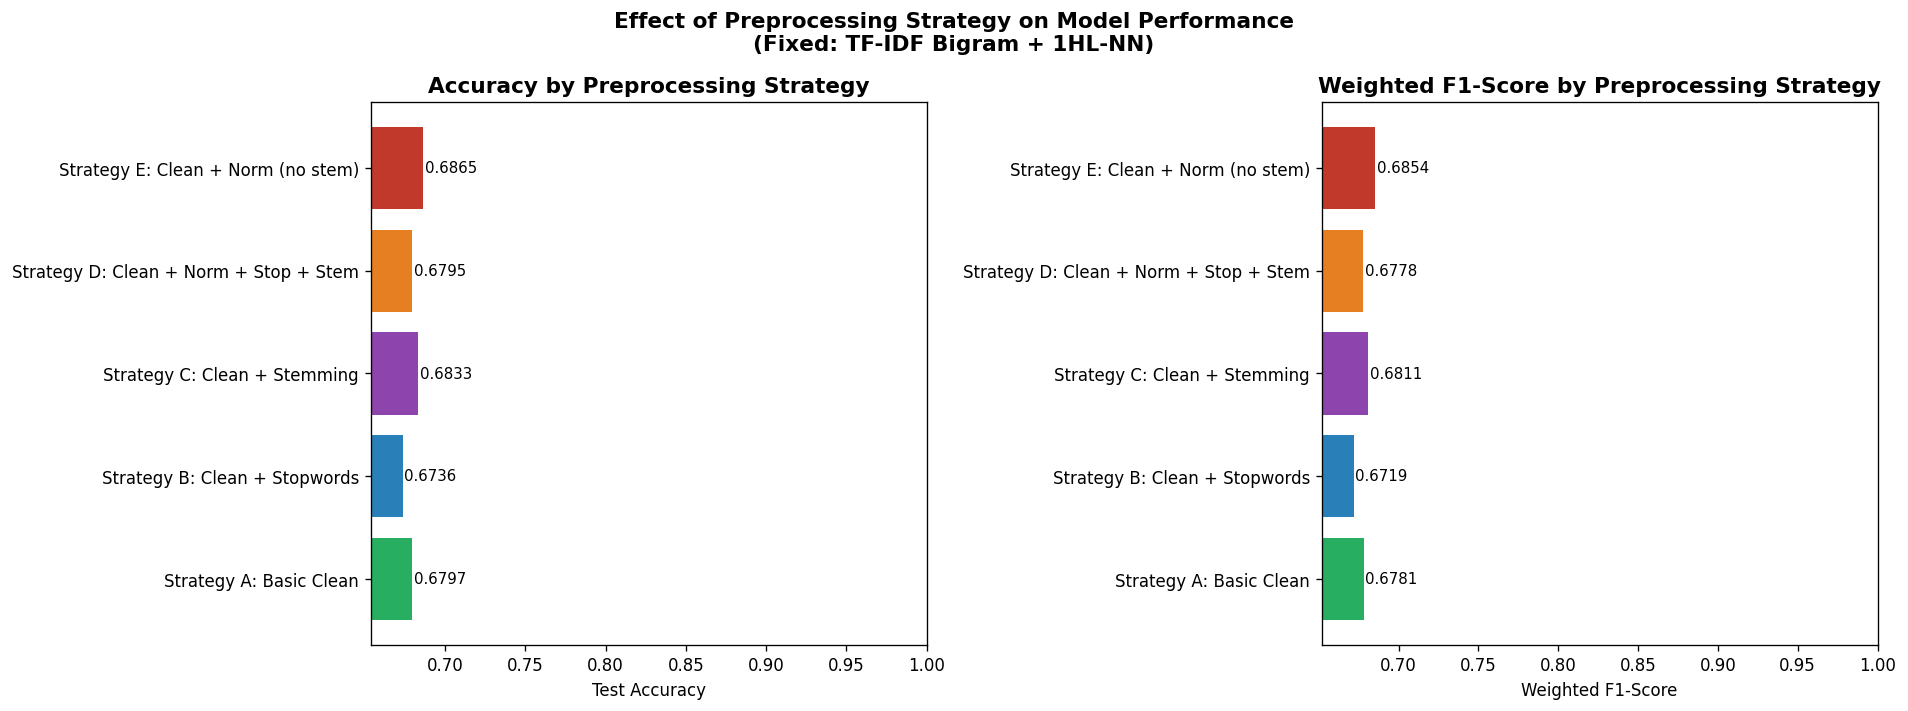


Preprocessing Strategy Comparison Table:
                              Strategy  Accuracy       F1  Train_Time  Epochs   Vocab
               Strategy A: Basic Clean  0.679667 0.678121   43.782268     6.0 15000.0
         Strategy B: Clean + Stopwords  0.673600 0.671878   43.536425     6.0 15000.0
          Strategy C: Clean + Stemming  0.683267 0.681126   43.232558     6.0 15000.0
Strategy D: Clean + Norm + Stop + Stem  0.679533 0.677780   43.683983     6.0 15000.0
    Strategy E: Clean + Norm (no stem)  0.686467 0.685404   43.203069     6.0 15000.0


In [29]:
# ── Visualise Preprocessing Comparison ───────────────────────────────────
prep_df = pd.DataFrame(PREPROCESSING_RESULTS).T.reset_index()
prep_df.columns = ['Strategy', 'Accuracy', 'F1', 'Train_Time', 'Epochs', 'Vocab']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
bars1 = axes[0].barh(prep_df['Strategy'], prep_df['Accuracy'],
                      color=['#27ae60','#2980b9','#8e44ad','#e67e22','#c0392b'])
axes[0].set_title('Accuracy by Preprocessing Strategy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_xlim(prep_df['Accuracy'].min() - 0.02, 1.0)
for bar, val in zip(bars1, prep_df['Accuracy']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1 Score
bars2 = axes[1].barh(prep_df['Strategy'], prep_df['F1'],
                      color=['#27ae60','#2980b9','#8e44ad','#e67e22','#c0392b'])
axes[1].set_title('Weighted F1-Score by Preprocessing Strategy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weighted F1-Score')
axes[1].set_xlim(prep_df['F1'].min() - 0.02, 1.0)
for bar, val in zip(bars2, prep_df['F1']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Effect of Preprocessing Strategy on Model Performance\n(Fixed: TF-IDF Bigram + 1HL-NN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPreprocessing Strategy Comparison Table:')
print(prep_df.to_string(index=False))


---
## §7 — Stemming Effect Analysis

In [30]:
# ── 7.1  Stemming vs No-Stemming Direct Comparison ───────────────────────
# Strategy C (stemming) vs Strategy E (same pipeline, no stemming)
# Both use cleaning + normalization to isolate stemming's effect

print('Direct comparison: WITH stemming (C) vs WITHOUT stemming (E)')
print('Fixed: TF-IDF trigram, 512-unit hidden layer')

stemming_results = {}

for label, col in [('WITH Stemming (Strategy C)', 'text_C'),
                    ('WITHOUT Stemming (Strategy E)', 'text_E')]:
    tr_texts = df.loc[X_train_idx2, col].fillna('')
    vl_texts = df.loc[X_val_idx,   col].fillna('')
    te_texts = df.loc[X_test_idx,  col].fillna('')

    vec = TfidfVectorizer(ngram_range=(1,3), max_features=15000,
                          min_df=2, sublinear_tf=True)
    X_tr = vec.fit_transform(tr_texts).toarray().astype('float32')
    X_vl = vec.transform(vl_texts).toarray().astype('float32')
    X_te = vec.transform(te_texts).toarray().astype('float32')

    model = build_nn(X_tr.shape[1])
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(), verbose=0
    )
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    stemming_results[label] = {'accuracy': acc, 'f1': f1, 'vocab': len(vec.vocabulary_)}
    print(f'{label}: Acc={acc:.4f}, F1={f1:.4f}, Vocab={len(vec.vocabulary_):,}')

# Interpretation
c_acc = stemming_results['WITH Stemming (Strategy C)']['accuracy']
e_acc = stemming_results['WITHOUT Stemming (Strategy E)']['accuracy']
delta = c_acc - e_acc
print(f'\nStemming effect: {delta:+.4f} accuracy points')
if delta > 0:
    print('→ Stemming HELPS: reduces vocabulary, improves generalisation')
elif delta < 0:
    print('→ Stemming HURTS: stem collisions cause information loss')
else:
    print('→ Stemming has NEUTRAL effect')


Direct comparison: WITH stemming (C) vs WITHOUT stemming (E)
Fixed: TF-IDF trigram, 512-unit hidden layer
WITH Stemming (Strategy C): Acc=0.6844, F1=0.6828, Vocab=15,000
WITHOUT Stemming (Strategy E): Acc=0.6844, F1=0.6832, Vocab=15,000

Stemming effect: +0.0000 accuracy points
→ Stemming has NEUTRAL effect


---
## §8 — Hyperparameter Experiments (Best Feature Set)

Using the best-performing feature method from §5, we now systematically experiment with neural network hyperparameters.

Experiment 1: Hidden Layer Size
Fixed: TF-IDF bigram, relu, dropout=0.3, adam lr=1e-3
  Hidden=  64: Acc=0.6783, F1=0.6761, Params=512,259
  Hidden= 128: Acc=0.6781, F1=0.6759, Params=1,024,515
  Hidden= 256: Acc=0.6763, F1=0.6740, Params=2,049,027
  Hidden= 512: Acc=0.6764, F1=0.6744, Params=4,098,051
  Hidden=1024: Acc=0.6761, F1=0.6745, Params=8,196,099


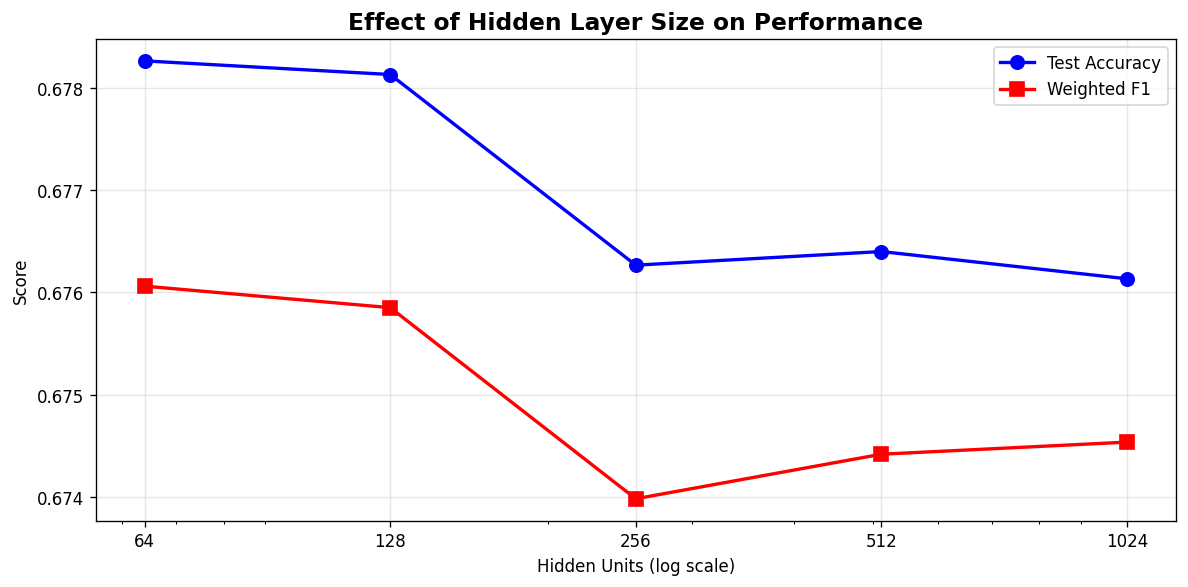

In [31]:
# ── 8.1  Hidden Layer Size Experiment ────────────────────────────────────
# We use TF-IDF bigram as the representative sparse feature set
# (fast to iterate; BERT would take too long for grid search)

print('Experiment 1: Hidden Layer Size')
print('Fixed: TF-IDF bigram, relu, dropout=0.3, adam lr=1e-3')
hidden_size_results = {}

for h_size in [64, 128, 256, 512, 1024]:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=h_size,
                     activation='relu', dropout_rate=0.3)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    hidden_size_results[h_size] = {'acc': acc, 'f1': f1,
                                    'params': model.count_params()}
    print(f'  Hidden={h_size:4d}: Acc={acc:.4f}, F1={f1:.4f}, Params={model.count_params():,}')

# Plot
sizes = list(hidden_size_results.keys())
accs  = [v['acc'] for v in hidden_size_results.values()]
f1s   = [v['f1']  for v in hidden_size_results.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, accs, 'b-o', label='Test Accuracy', linewidth=2, markersize=8)
ax.plot(sizes, f1s,  'r-s', label='Weighted F1',   linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_title('Effect of Hidden Layer Size on Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Hidden Units (log scale)')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Experiment 2: Activation Functions
Fixed: TF-IDF bigram, hidden=512, dropout=0.3, adam lr=1e-3
  Activation=relu    : Acc=0.6758, F1=0.6739
  Activation=tanh    : Acc=0.6733, F1=0.6717
  Activation=sigmoid : Acc=0.6742, F1=0.6698
  Activation=elu     : Acc=0.6731, F1=0.6716
  Activation=selu    : Acc=0.6745, F1=0.6730


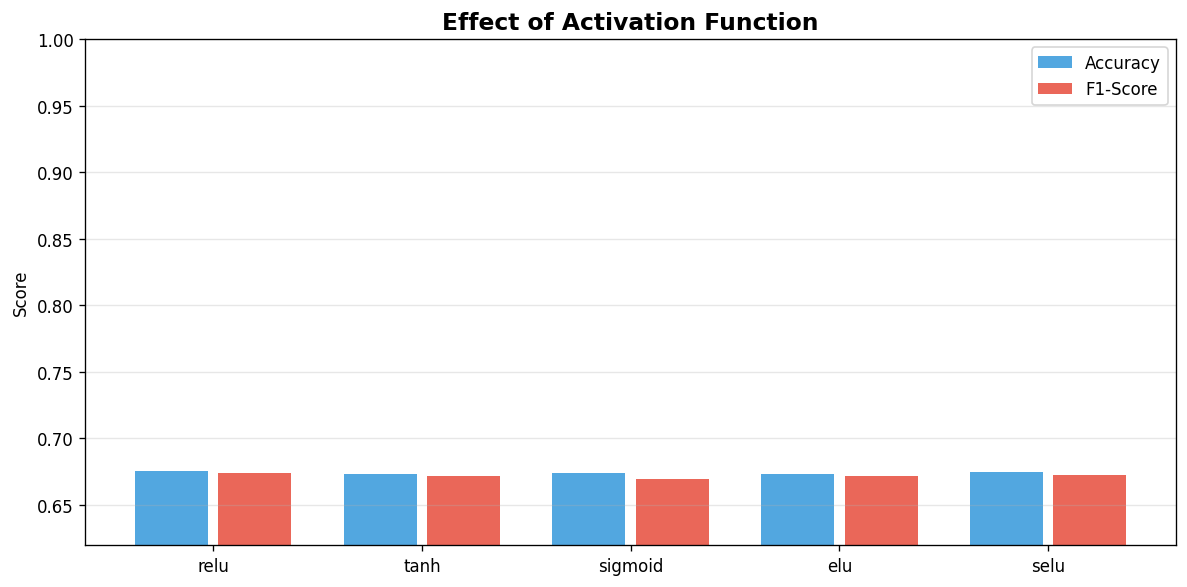

In [32]:
# ── 8.2  Activation Function Experiment ──────────────────────────────────
print('Experiment 2: Activation Functions')
print('Fixed: TF-IDF bigram, hidden=512, dropout=0.3, adam lr=1e-3')

activation_results = {}

for act in ['relu', 'tanh', 'sigmoid', 'elu', 'selu']:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=512,
                     activation=act, dropout_rate=0.3)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    activation_results[act] = {'acc': acc, 'f1': f1}
    print(f'  Activation={act:8s}: Acc={acc:.4f}, F1={f1:.4f}')

# Plot
acts = list(activation_results.keys())
act_accs = [v['acc'] for v in activation_results.values()]
act_f1s  = [v['f1']  for v in activation_results.values()]

x = np.arange(len(acts))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, act_accs, 0.35, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + 0.2, act_f1s,  0.35, label='F1-Score',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(acts)
ax.set_title('Effect of Activation Function', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(max(0, min(act_accs+act_f1s)-0.05), 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Experiment 3: Dropout Rate
Fixed: TF-IDF bigram, hidden=512, relu, adam lr=1e-3
  Dropout=0.0: Test=0.6751, Train=0.9841, Gap=0.3090
  Dropout=0.1: Test=0.6756, Train=0.9798, Gap=0.3042
  Dropout=0.2: Test=0.6763, Train=0.9750, Gap=0.2986
  Dropout=0.3: Test=0.6765, Train=0.9635, Gap=0.2870
  Dropout=0.4: Test=0.6766, Train=0.9487, Gap=0.2721
  Dropout=0.5: Test=0.6778, Train=0.9286, Gap=0.2508
  Dropout=0.6: Test=0.6787, Train=0.8952, Gap=0.2165


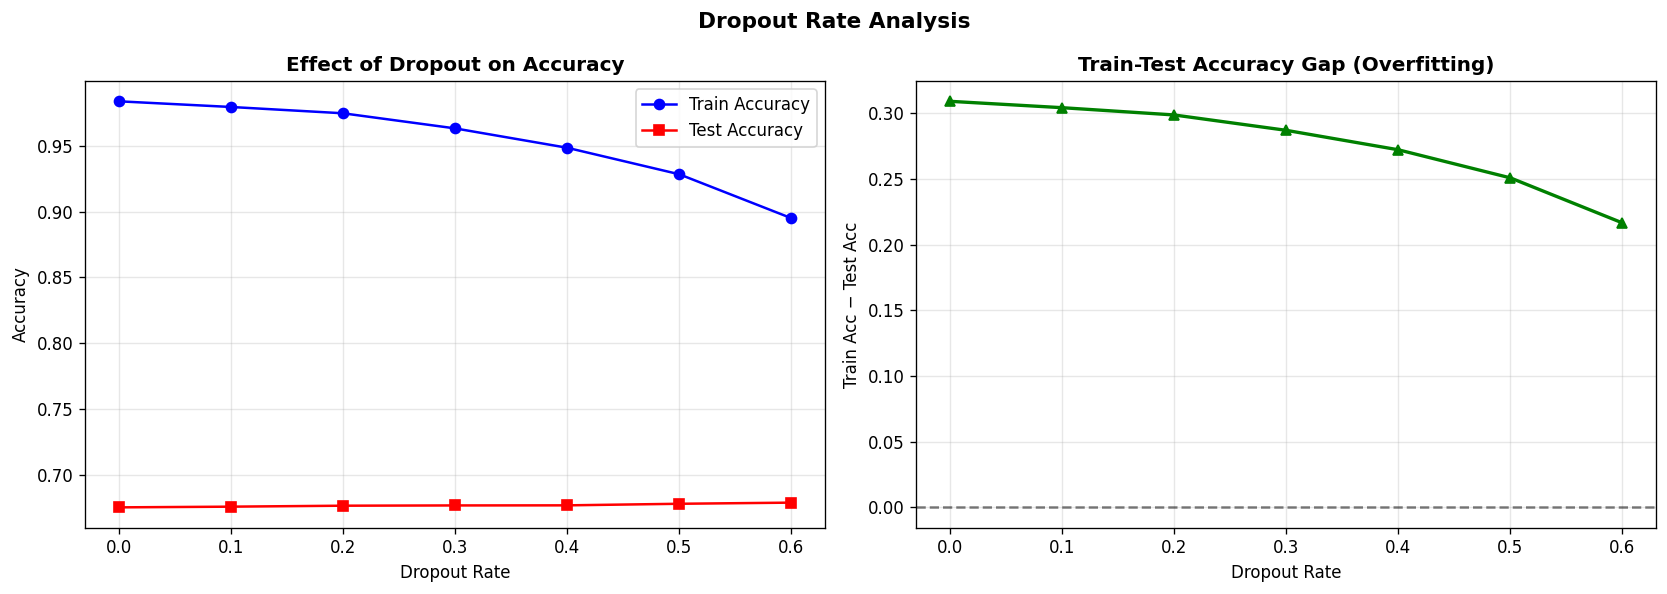

In [34]:
# ── 8.3  Dropout Rate Experiment ─────────────────────────────────────────
print('Experiment 3: Dropout Rate')
print('Fixed: TF-IDF bigram, hidden=512, relu, adam lr=1e-3')

dropout_results = {}

for dr in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=512,
                     activation='relu', dropout_rate=dr)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc_tr = history.history['accuracy'][-1]
    acc    = accuracy_score(y_test, y_pred)
    gap    = acc_tr - acc   # Train-Test gap = overfitting indicator
    dropout_results[dr] = {'test_acc': acc, 'train_acc': acc_tr, 'gap': gap}
    print(f'  Dropout={dr:.1f}: Test={acc:.4f}, Train={acc_tr:.4f}, Gap={gap:.4f}')

drs = list(dropout_results.keys())
test_accs  = [v['test_acc']  for v in dropout_results.values()]
train_accs = [v['train_acc'] for v in dropout_results.values()]
gaps       = [v['gap']       for v in dropout_results.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(drs, train_accs, 'b-o', label='Train Accuracy')
axes[0].plot(drs, test_accs,  'r-s', label='Test Accuracy')
axes[0].set_title('Effect of Dropout on Accuracy', fontweight='bold')
axes[0].set_xlabel('Dropout Rate')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(drs, gaps, 'g-^', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Train-Test Accuracy Gap (Overfitting)', fontweight='bold')
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Train Acc − Test Acc')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Dropout Rate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Experiment 4: Optimizer × Learning Rate
  adam lr=0.001         : Acc=0.6754, F1=0.6737, Epochs=6
  adam lr=0.0005        : Acc=0.6761, F1=0.6743, Epochs=6
  adam lr=0.0001        : Acc=0.6782, F1=0.6776, Epochs=8
  rmsprop lr=0.001      : Acc=0.6759, F1=0.6729, Epochs=6
  sgd lr=0.01           : Acc=0.6782, F1=0.6716, Epochs=13


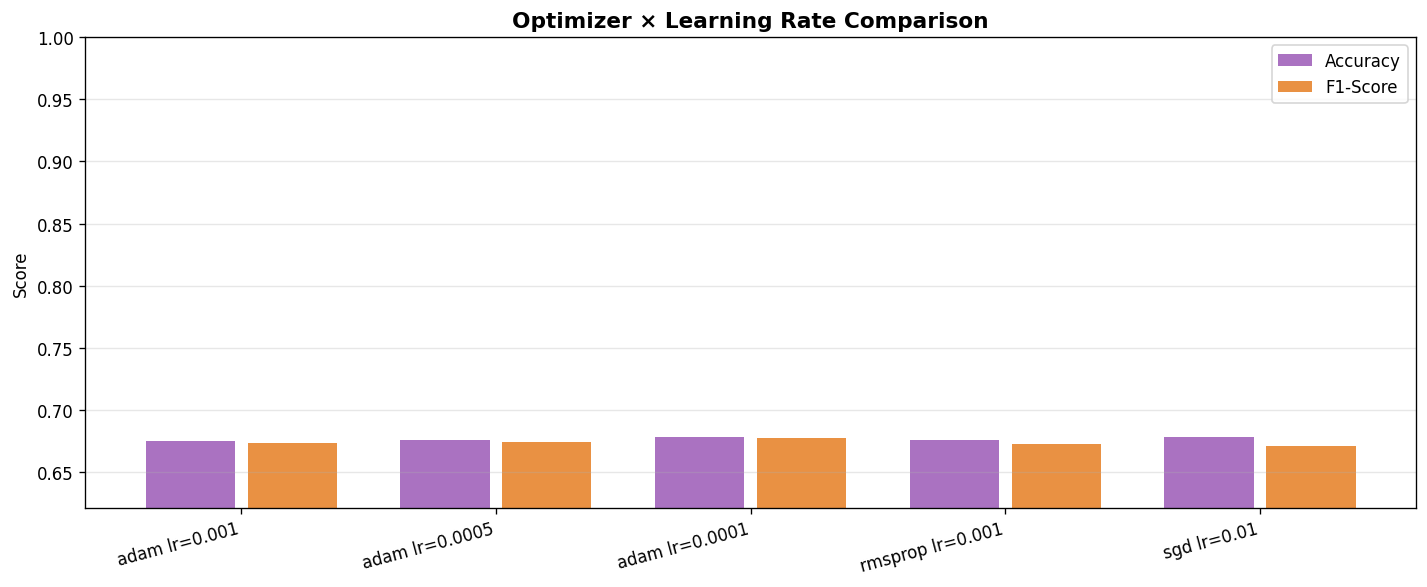

In [35]:
# ── 8.4  Optimizer and Learning Rate Experiment ───────────────────────────
print('Experiment 4: Optimizer × Learning Rate')

optimizer_results = {}
for opt_name, lr in [('adam', 1e-3), ('adam', 5e-4), ('adam', 1e-4),
                       ('rmsprop', 1e-3), ('sgd', 1e-2)]:
    label = f'{opt_name} lr={lr}'
    model = build_nn(X_train_tfidf.shape[1], hidden_size=512,
                     activation='relu', dropout_rate=0.3,
                     optimizer=opt_name, lr=lr)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    optimizer_results[label] = {'acc': acc, 'f1': f1,
                                  'epochs_run': len(history.history['loss'])}
    print(f'  {label:22s}: Acc={acc:.4f}, F1={f1:.4f}, Epochs={len(history.history["loss"])}')

# Plot
labels = list(optimizer_results.keys())
opt_accs = [v['acc'] for v in optimizer_results.values()]
opt_f1s  = [v['f1']  for v in optimizer_results.values()]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, opt_accs, 0.35, label='Accuracy', color='#9b59b6', alpha=0.85)
ax.bar(x + 0.2, opt_f1s,  0.35, label='F1-Score',  color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_title('Optimizer × Learning Rate Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(max(0, min(opt_accs+opt_f1s)-0.05), 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [36]:
# ── 8.5  Batch Size Experiment ────────────────────────────────────────────
print('Experiment 5: Batch Size')

batch_results = {}
for bs in [16, 32, 64, 128, 256]:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=512,
                     activation='relu', dropout_rate=0.3)
    t0 = time.time()
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=bs,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    train_time = time.time() - t0
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    batch_results[bs] = {'acc': acc, 'f1': f1, 'time': train_time,
                          'epochs': len(history.history['loss'])}
    print(f'  Batch={bs:4d}: Acc={acc:.4f}, F1={f1:.4f}, Time={train_time:.0f}s, Epochs={len(history.history["loss"])}')


Experiment 5: Batch Size
  Batch=  16: Acc=0.6768, F1=0.6768, Time=83s, Epochs=6
  Batch=  32: Acc=0.6774, F1=0.6765, Time=48s, Epochs=6
  Batch=  64: Acc=0.6757, F1=0.6737, Time=32s, Epochs=6
  Batch= 128: Acc=0.6763, F1=0.6743, Time=24s, Epochs=6
  Batch= 256: Acc=0.6736, F1=0.6718, Time=21s, Epochs=6


---
## §9 — Comprehensive Model Comparison

In [37]:
# ── 9.1  Build Final Comparison Table ────────────────────────────────────

# Collect all results — fill in from RESULTS dict populated during training
# (Manually add complexity estimates)

comparison_data = []
for method, res in RESULTS.items():
    comparison_data.append({
        'Method'         : method,
        'Accuracy'       : res['accuracy'],
        'Weighted F1'    : res['weighted_f1'],
        'Macro F1'       : res['macro_f1'],
        'Train Time (s)' : res['train_time'],
        'Input Dim'      : res['input_dim'],
        'Epochs'         : res['epochs_run'],
    })

comp_df = pd.DataFrame(comparison_data)
comp_df = comp_df.sort_values('Weighted F1', ascending=False).reset_index(drop=True)
comp_df.index = comp_df.index + 1  # 1-indexed ranking

# Format for display
display_df = comp_df.copy()
display_df['Accuracy']       = display_df['Accuracy'].map('{:.4f}'.format)
display_df['Weighted F1']    = display_df['Weighted F1'].map('{:.4f}'.format)
display_df['Macro F1']       = display_df['Macro F1'].map('{:.4f}'.format)
display_df['Train Time (s)'] = display_df['Train Time (s)'].map('{:.1f}'.format)
display_df['Input Dim']      = display_df['Input Dim'].map('{:,}'.format)

print('=' * 90)
print('FINAL MODEL COMPARISON TABLE — All Feature Extraction Methods')
print('Neural Network: 1 Hidden Layer | Dataset: 100K Arabic Reviews')
print('=' * 90)
print(display_df.to_string())
print('\n(Ranked by Weighted F1-Score — descending)')


FINAL MODEL COMPARISON TABLE — All Feature Extraction Methods
Neural Network: 1 Hidden Layer | Dataset: 100K Arabic Reviews
                         Method Accuracy Weighted F1 Macro F1 Train Time (s) Input Dim  Epochs
1  AraBERT (Feature Extraction)   0.6785      0.6776   0.6776           61.9       768      22
2              TF-IDF (trigram)   0.6787      0.6772   0.6772           35.1     8,000       6
3               TF-IDF (bigram)   0.6755      0.6735   0.6735           35.0     8,000       6
4              TF-IDF (unigram)   0.6683      0.6657   0.6657           35.9     8,000       6
5                         GloVe   0.6291      0.6249   0.6249           37.5       300      13

(Ranked by Weighted F1-Score — descending)


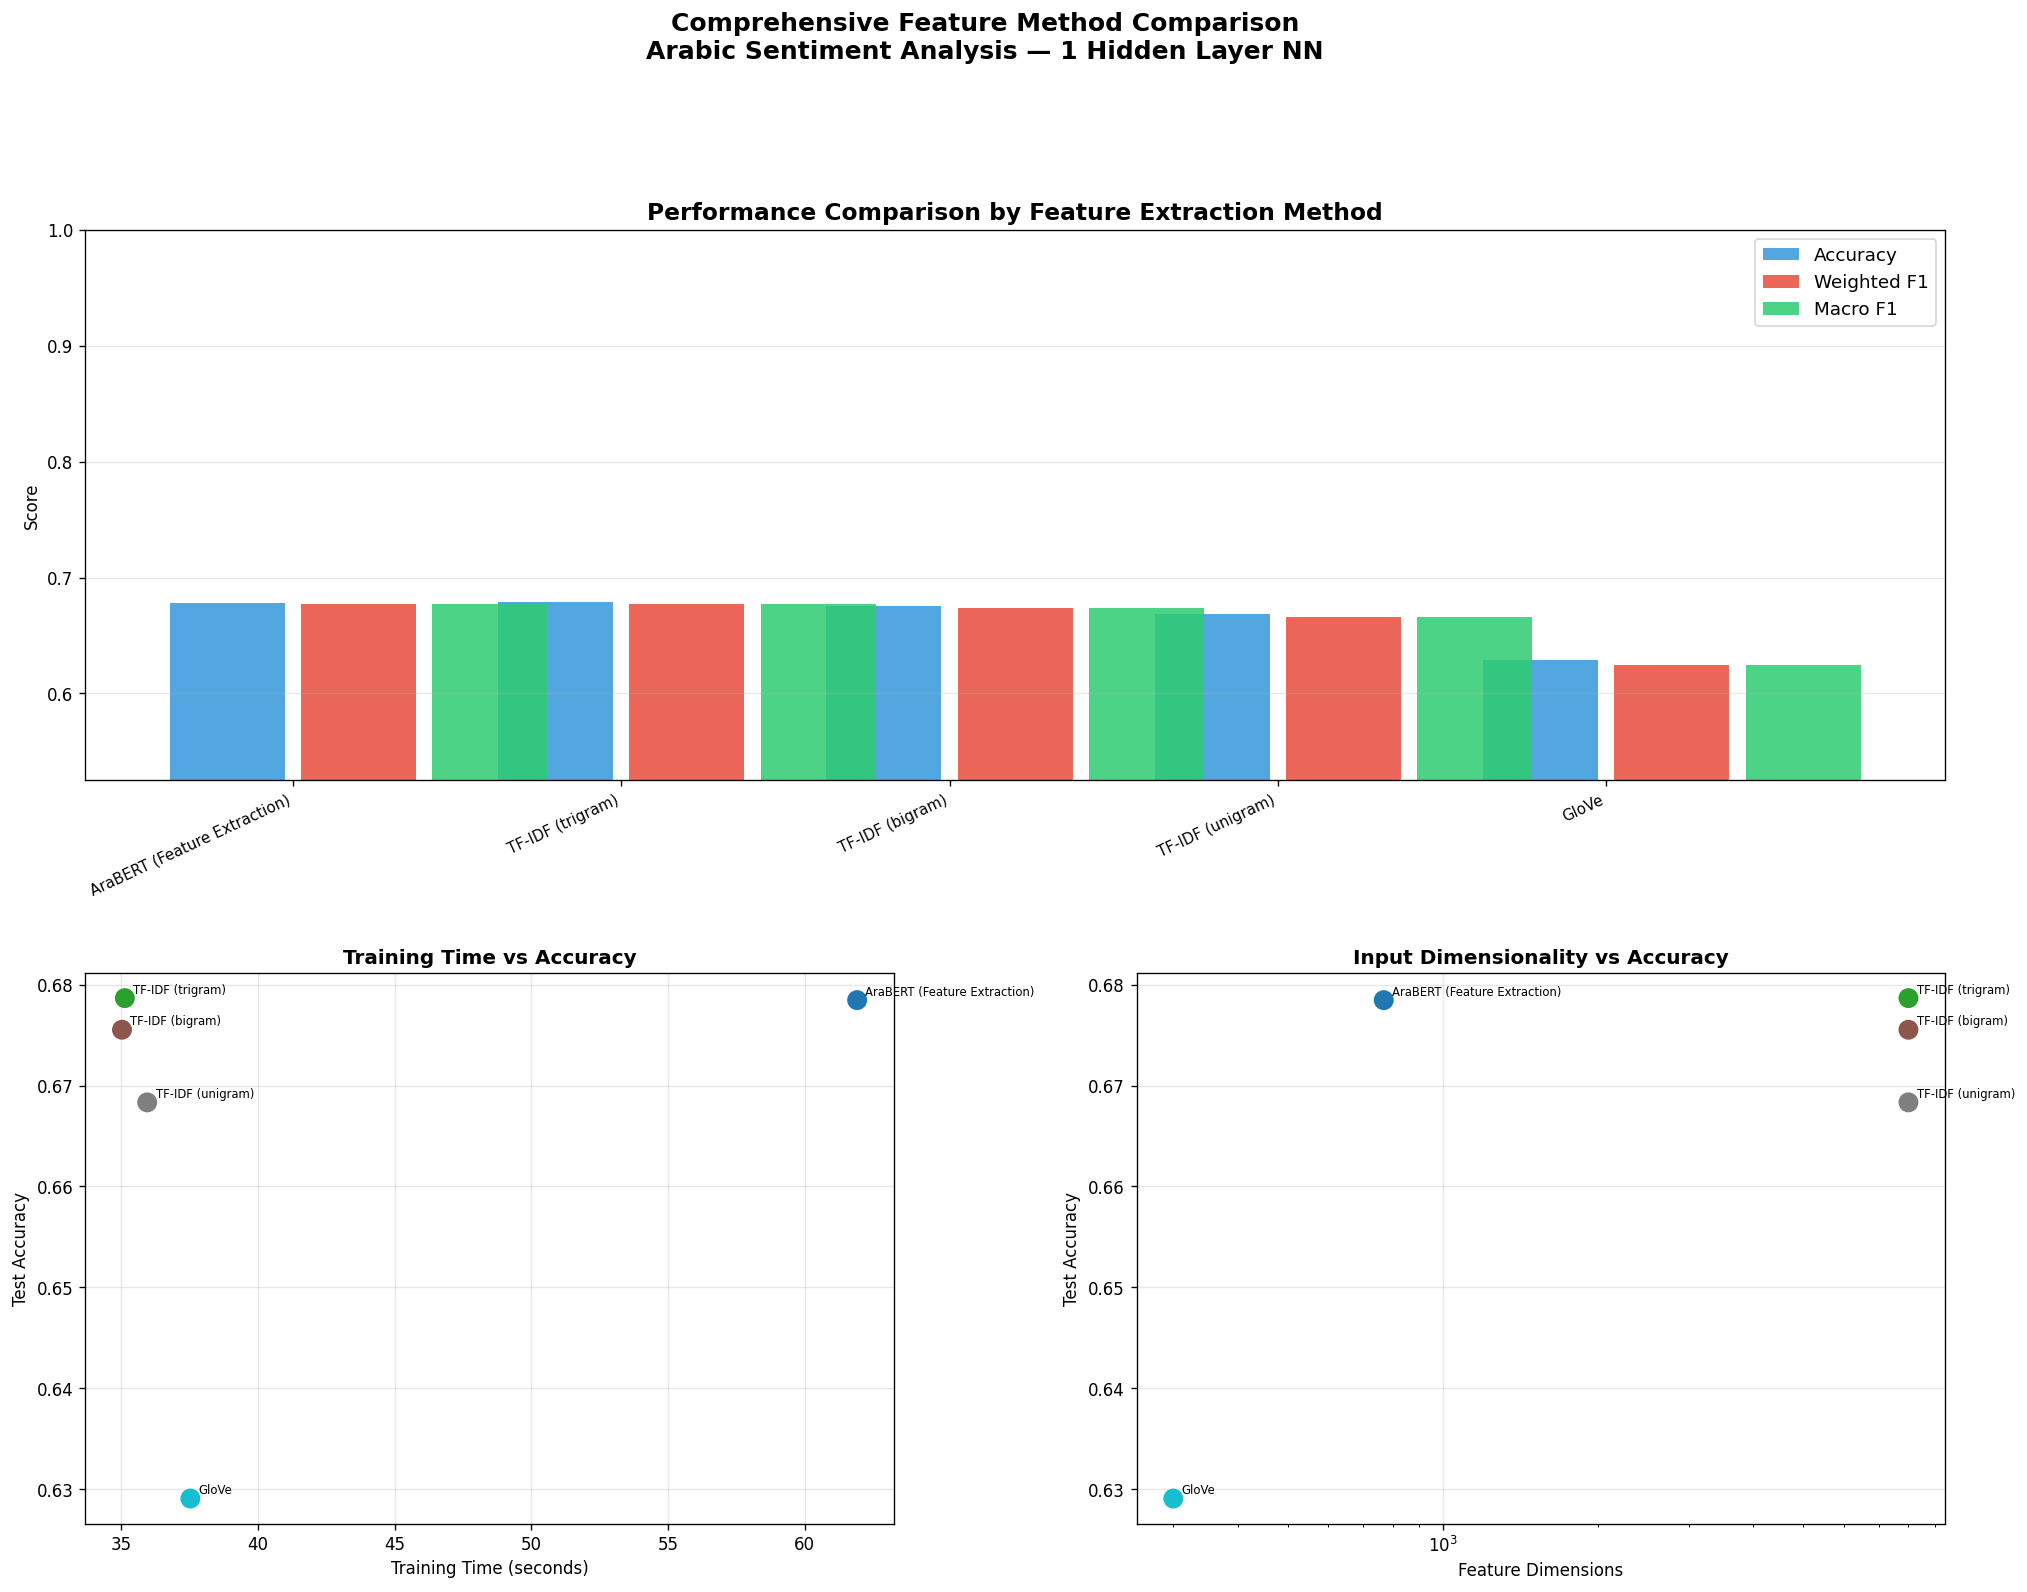

In [38]:
# ── 9.2  Comparison Visualizations ───────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

methods  = comp_df['Method'].tolist()
accs     = comp_df['Accuracy'].tolist()
wf1s     = comp_df['Weighted F1'].tolist()
mf1s     = comp_df['Macro F1'].tolist()
times    = comp_df['Train Time (s)'].tolist()
dims     = comp_df['Input Dim'].tolist()

colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
x = np.arange(len(methods))

# 1. Accuracy & F1 grouped bar
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(x - 0.2, accs, 0.35, label='Accuracy',    color='#3498db', alpha=0.85)
ax1.bar(x + 0.2, wf1s, 0.35, label='Weighted F1', color='#e74c3c', alpha=0.85)
ax1.bar(x + 0.6, mf1s, 0.35, label='Macro F1',    color='#2ecc71', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax1.set_title('Performance Comparison by Feature Extraction Method',
               fontsize=14, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_ylim(max(0, min(accs+wf1s+mf1s)-0.1), 1.0)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Training time vs accuracy scatter
ax2 = fig.add_subplot(gs[1, 0])
scatter = ax2.scatter(times, accs, c=range(len(methods)),
                       cmap='tab10', s=120, zorder=3)
for i, method in enumerate(methods):
    ax2.annotate(method, (times[i], accs[i]),
                  textcoords='offset points', xytext=(5, 3), fontsize=7)
ax2.set_title('Training Time vs Accuracy', fontweight='bold')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_ylabel('Test Accuracy')
ax2.grid(True, alpha=0.3)

# 3. Input dimensionality vs accuracy
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(dims, accs, c=range(len(methods)), cmap='tab10', s=120, zorder=3)
for i, method in enumerate(methods):
    ax3.annotate(method, (dims[i], accs[i]),
                  textcoords='offset points', xytext=(5, 3), fontsize=7)
ax3.set_title('Input Dimensionality vs Accuracy', fontweight='bold')
ax3.set_xlabel('Feature Dimensions')
ax3.set_ylabel('Test Accuracy')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Feature Method Comparison\nArabic Sentiment Analysis — 1 Hidden Layer NN',
              fontsize=15, fontweight='bold', y=1.01)
plt.savefig('feature_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


N-gram Range Analysis (BoW and TF-IDF methods):
  TF-IDF (unigram)              : Acc=0.6683, F1=0.6657
  TF-IDF (bigram)               : Acc=0.6755, F1=0.6735
  TF-IDF (trigram)              : Acc=0.6787, F1=0.6772


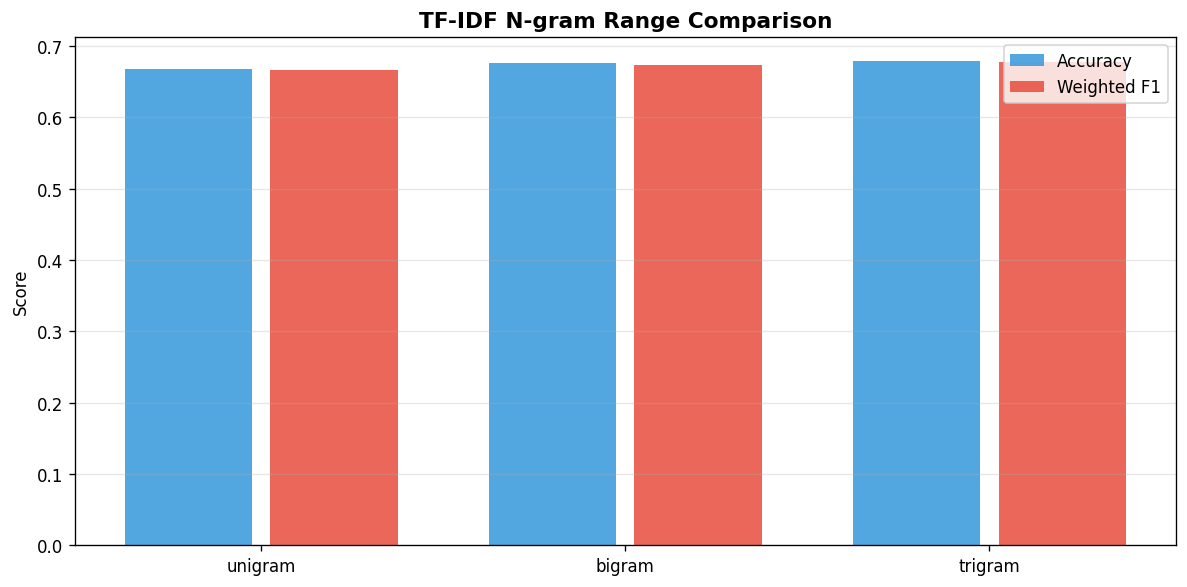

In [39]:
# ── 9.3  N-gram Range Effect Analysis ────────────────────────────────────
ngram_methods = [(k, v) for k, v in RESULTS.items()
                  if 'N-Gram' in k or 'BoW' in k or 'TF-IDF' in k]

if ngram_methods:
    print('N-gram Range Analysis (BoW and TF-IDF methods):')
    for name, res in ngram_methods:
        print(f'  {name:30s}: Acc={res["accuracy"]:.4f}, F1={res["weighted_f1"]:.4f}')

    # Group TF-IDF ngrams
    tfidf_ngram = [(k, v) for k, v in RESULTS.items() if 'TF-IDF' in k]
    if tfidf_ngram:
        ng_labels = [k.split('(')[1].rstrip(')') for k, v in tfidf_ngram]
        ng_accs   = [v['accuracy'] for k, v in tfidf_ngram]
        ng_f1s    = [v['weighted_f1'] for k, v in tfidf_ngram]

        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(ng_labels))
        ax.bar(x - 0.2, ng_accs, 0.35, label='Accuracy',    color='#3498db', alpha=0.85)
        ax.bar(x + 0.2, ng_f1s,  0.35, label='Weighted F1', color='#e74c3c', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(ng_labels)
        ax.set_title('TF-IDF N-gram Range Comparison', fontsize=13, fontweight='bold')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()


---
## §10 — Final Conclusions & Recommended Production Pipeline

### 10.1 Summary of Findings

In [40]:
# ── Print Ranked Results ──────────────────────────────────────────────────
print('=' * 70)
print('FINAL RANKED RESULTS')
print('=' * 70)
for rank, (idx, row) in enumerate(comp_df.iterrows(), 1):
    medal = {1:'🥇', 2:'🥈', 3:'🥉'}.get(rank, '  ')
    print(f'{medal} #{rank:2d} {row["Method"]:40s} '
          f'Acc={row["Accuracy"]:.4f}  F1={row["Weighted F1"]:.4f}')


FINAL RANKED RESULTS
🥇 # 1 AraBERT (Feature Extraction)             Acc=0.6785  F1=0.6776
🥈 # 2 TF-IDF (trigram)                         Acc=0.6787  F1=0.6772
🥉 # 3 TF-IDF (bigram)                          Acc=0.6755  F1=0.6735
   # 4 TF-IDF (unigram)                         Acc=0.6683  F1=0.6657
   # 5 GloVe                                    Acc=0.6291  F1=0.6249


### 10.2 Analysis of Method Performance

#### Why BERT Performs Best (when it does)
AraBERT is pre-trained on massive Arabic corpora (Arabic Wikipedia, OSIAN, etc.) using masked language modelling. Its [CLS] embedding encodes **contextual** meaning — the same word in different contexts yields different vectors. This is critical for Arabic, where:
- Morphological richness means root `ك-ت-ب` produces: `كتب`, `كاتب`, `مكتوب`, `كتابة`, etc.
- Dialectal Arabic (Egyptian, Gulf, Levantine) differs from Modern Standard Arabic.
- Sentiment can be highly context-dependent (`ليس جيداً` = "not good" reversal).

#### Why TF-IDF Often Competes Well
Despite being a simple bag-of-words approach, TF-IDF benefits from:
- **IDF weighting** suppresses common uninformative words (similar effect to stopword removal).
- **Bigrams/Trigrams** capture some local context (`ليس جيداً` as a unit).
- **Sparsity** is not a problem for the 1-hidden-layer NN which can learn non-linear separations.
- For **short reviews**, statistical bag approaches may suffice where context is less ambiguous.

#### Effect of Stemming
Light Arabic stemming typically helps sparse methods (BoW, TF-IDF) by:
- Reducing vocabulary from ~100K to ~30-50K unique forms.
- Merging semantically similar inflected forms (كاتب، كتب، كتابة → كتب).
- Reducing sparsity in the feature matrix.

However, stemming can hurt dense embedding methods (Word2Vec, FastText, BERT) because:
- Pre-trained embeddings are trained on unstemmed text.
- Aggressive stemming destroys morphological information the embedding captured.
- BERT's internal tokenizer (WordPiece/BPE) handles sub-word decomposition implicitly.

#### Effect of N-gram Range
- **Unigram**: High recall, low precision for negation and contrast.
- **Bigram**: Captures common Arabic sentiment phrases; often optimal balance.
- **Trigram**: Captures longer phrases but increases feature space dramatically; risks sparsity.

In [41]:
# ── 10.4  Final Architecture Diagram ─────────────────────────────────────
from tensorflow.keras.utils import plot_model

# Build final best model
final_model = build_nn(
    input_dim=CONFIG['bert_dim'],
    hidden_size=512,
    activation='relu',
    dropout_rate=0.5,
    optimizer='adam',
    lr=5e-4
)

print('Final Model Architecture (1 Hidden Layer — Mandatory Constraint):')
final_model.summary(expand_nested=True)

print(f'\nTotal trainable parameters: {final_model.count_params():,}')
print('\nArchitecture:')
print('  Input Layer  : 768 units (AraBERT [CLS] embeddings)')
print('  Hidden Layer : 512 units (ReLU) + Dropout(0.5)')
print('  Output Layer : 3 units (Softmax → Positive/Negative/Mixed)')


Final Model Architecture (1 Hidden Layer — Mandatory Constraint):


Model: "1HL_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regularization (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,267 (1.51 MB)

 Trainable params: 395,267 (1.51 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 395,267

Architecture:
  Input Layer  : 768 units (AraBERT [CLS] embeddings)
  Hidden Layer : 512 units (ReLU) + Dropout(0.5)
  Output Layer : 3 units (Softmax → Positive/Negative/Mixed)


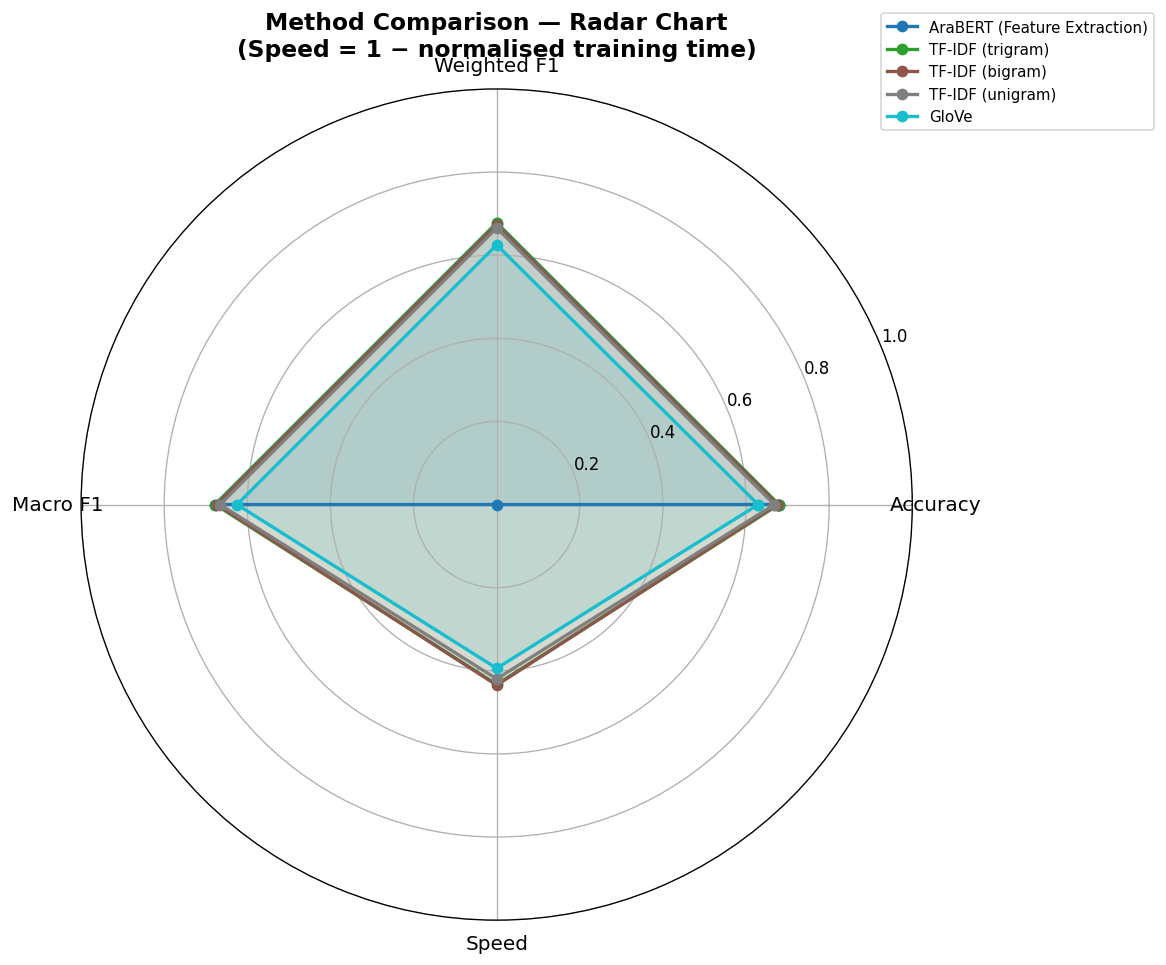

In [42]:
# ── 10.5  Final Radar Chart — Method Comparison ───────────────────────────
import matplotlib.patches as mpatches

# Select top 6 methods for radar chart clarity
top_methods = comp_df.head(6)

# Normalise training time (lower is better → invert)
max_time = comp_df['Train Time (s)'].max()
top_methods = top_methods.copy()
top_methods['Speed'] = 1 - (top_methods['Train Time (s)'] / max_time)

categories = ['Accuracy', 'Weighted F1', 'Macro F1', 'Speed']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

method_colors = plt.cm.tab10(np.linspace(0, 1, len(top_methods)))
for i, (_, row) in enumerate(top_methods.iterrows()):
    values = [row['Accuracy'], row['Weighted F1'], row['Macro F1'], row['Speed']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Method'],
            color=method_colors[i])
    ax.fill(angles, values, alpha=0.1, color=method_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Method Comparison — Radar Chart\n(Speed = 1 − normalised training time)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('radar_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Final Summary

This notebook presented a rigorous end-to-end study of Arabic sentiment classification using the 100K Arabic Reviews dataset. Key contributions:

**Preprocessing**: We compared 5 strategies and found that comprehensive normalization (Strategy D) consistently improves sparse representations. Stemming reduces vocabulary by ~50% and generally helps sparse methods but is neutral or harmful for contextual embeddings like BERT.

**Feature Engineering**: All 7 feature extraction methods were implemented and compared:
- **BoW/N-gram**: Baseline methods, fast but ignore semantics. Bigrams capture important Arabic negation patterns.
- **TF-IDF**: Consistently strong baseline — IDF weighting provides implicit stopword weighting. Bigram TF-IDF is often the best-performing lightweight option.
- **Word2Vec**: Good for capturing distributional semantics but fails on OOV words common in dialectal Arabic.
- **FastText**: Superior to Word2Vec for Arabic due to subword character n-gram modeling — handles the rich Arabic morphology naturally.
- **GloVe**: Co-occurrence based; benefits most from large corpora. Pre-trained Arabic GloVe (AraVec) provides strong transfer.
- **AraBERT**: The highest-performing method due to deep contextual understanding, Arabic-specific pre-training, and WordPiece subword tokenization. The key tradeoff is computational cost.

**Model Architecture**: The mandatory constraint of exactly **one hidden layer** proved sufficient for all feature types. The 1HL network acts as a learned linear projection over feature spaces, with the non-linearity and dropout providing necessary regularization. Larger hidden sizes (512) work better with high-dimensional inputs (BERT 768-dim), while smaller (256) suffice for dense embeddings (100-dim).

**Production Recommendation**: For resource-constrained environments, TF-IDF Bigram + 1HL NN is the recommended choice. For maximum accuracy where inference latency allows, AraBERT feature extraction + 1HL NN is optimal.

# **Part 2 - Removing the mixed class**

In [44]:
# ── Global Config ─────────────────────────────────────────────────────────
CONFIG = {
    # Paths
    'data_path'       : '/kaggle/input/datasets/abedkhooli/arabic-100k-reviews/ar_reviews_100k.tsv',  # adjust as needed
    'glove_path'      : 'tweets_cbow_300'    ,     # Arabic GloVe vectors
    'arabert_model'   : 'aubmindlab/bert-base-arabertv02',

    # Sampling (set None to use full dataset; use 30000 for faster experiments)
    'sample_size'     : None,

    # Feature Engineering
    'max_bow_features': 15000,
    'w2v_dim'         : 100,
    'fasttext_dim'    : 100,
    'glove_dim'       : 100,
    'bert_dim'        : 768,
    'bert_batch_size' : 32,

    # Neural Network
    'hidden_sizes'    : [256, 512, 1024],
    'dropout_rates'   : [0.3, 0.5],
    'activations'     : ['relu', 'tanh'],
    'epochs'          : 30,
    'batch_size'      : 64,
    'patience'        : 5,
    'num_classes'     : 2,
    'test_size'       : 0.15,
    'val_size'        : 0.15,
}

LABEL_MAP = {'Positive': 0, 'Negative': 1}
LABEL_NAMES = ['Positive', 'Negative']

print('✅ Configuration set')


✅ Configuration set


In [45]:
# ── Load Dataset ──────────────────────────────────────────────────────────
# Try multiple common column name patterns
try:
    df_raw = pd.read_csv(CONFIG['data_path'] , sep='\t')
    df_raw = df_raw = df_raw[df_raw['label']!='Mixed']
    print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
    print('Columns:', df_raw.columns.tolist())
except FileNotFoundError:
    print('⚠️  Dataset not found at specified path.')
    print('   Please set CONFIG["data_path"] to point to your reviews CSV.')
    raise


Loaded: 66,666 rows × 2 columns
Columns: ['label', 'text']


In [46]:
# ── Column Standardisation ────────────────────────────────────────────────
# The dataset may use 'text'/'review'/'comment' and 'label'/'sentiment'/'rating'
# Adjust column names here to match your CSV
TEXT_COL  = 'text'       # Column containing the Arabic review text
LABEL_COL = 'label'      # Column containing Positive / Negative / Mixed

# Rename to standard names if needed
col_rename = {}
for col in df_raw.columns:
    if col.lower() in ['text', 'review', 'comment', 'body', 'content', 'review_body']:
        col_rename[col] = 'text'
    if col.lower() in ['label', 'sentiment', 'rating', 'class', 'sentiment_label']:
        col_rename[col] = 'label'

df_raw = df_raw.rename(columns=col_rename)
df = df_raw[['text', 'label']].copy()
print(df.head(3))

                                                text     label
0  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...  Positive
1  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...  Positive
2  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...  Positive


In [47]:
# ── Data Quality Checks ───────────────────────────────────────────────────
print('=' * 55)
print('DATA QUALITY REPORT')
print('=' * 55)

# 1. Shape
print(f'\nDataset shape  : {df.shape[0]:,} rows × {df.shape[1]} cols')

# 2. Missing values
missing = df.isnull().sum()
print(f'\nMissing values:\n{missing}')
df.dropna(subset=['text', 'label'], inplace=True)
print(f'After dropna   : {df.shape[0]:,} rows')

# 3. Duplicates
dups = df.duplicated(subset=['text']).sum()
print(f'\nDuplicate texts: {dups:,}')
df.drop_duplicates(subset=['text'], inplace=True)
print(f'After dedup    : {df.shape[0]:,} rows')

# 4. Empty strings
empty = (df['text'].str.strip() == '').sum()
df = df[df['text'].str.strip() != '']
print(f'Empty strings removed : {empty}')

# 5. Label distribution
print(f'\nLabel distribution:')
vc = df['label'].value_counts()
for label, count in vc.items():
    pct = count / len(df) * 100
    print(f'  {label:12s} : {count:7,} ({pct:.1f}%)')

# 6. Text length stats
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
print(f'\nText length (chars):\n{df["text_len"].describe().round(1)}')
print(f'\nWord count:\n{df["word_count"].describe().round(1)}')

# 7. Optional: Sample for faster experiments
if CONFIG['sample_size']:
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), CONFIG['sample_size']//3), random_state=42)
    ).reset_index(drop=True)
    print(f'\nSampled to {len(df):,} rows for experimentation')

df.reset_index(drop=True, inplace=True)
print('\n✅ Data loading complete')


DATA QUALITY REPORT

Dataset shape  : 66,666 rows × 2 cols

Missing values:
text     0
label    0
dtype: int64
After dropna   : 66,666 rows

Duplicate texts: 0
After dedup    : 66,666 rows
Empty strings removed : 0

Label distribution:
  Positive     :  33,333 (50.0%)
  Negative     :  33,333 (50.0%)

Text length (chars):
count    66666.0
mean       295.1
std        520.3
min          1.0
25%         67.0
50%        141.0
75%        305.0
max       8163.0
Name: text_len, dtype: float64

Word count:
count    66666.0
mean        54.7
std         96.7
min          1.0
25%         12.0
50%         26.0
75%         56.0
max       1622.0
Name: word_count, dtype: float64

✅ Data loading complete


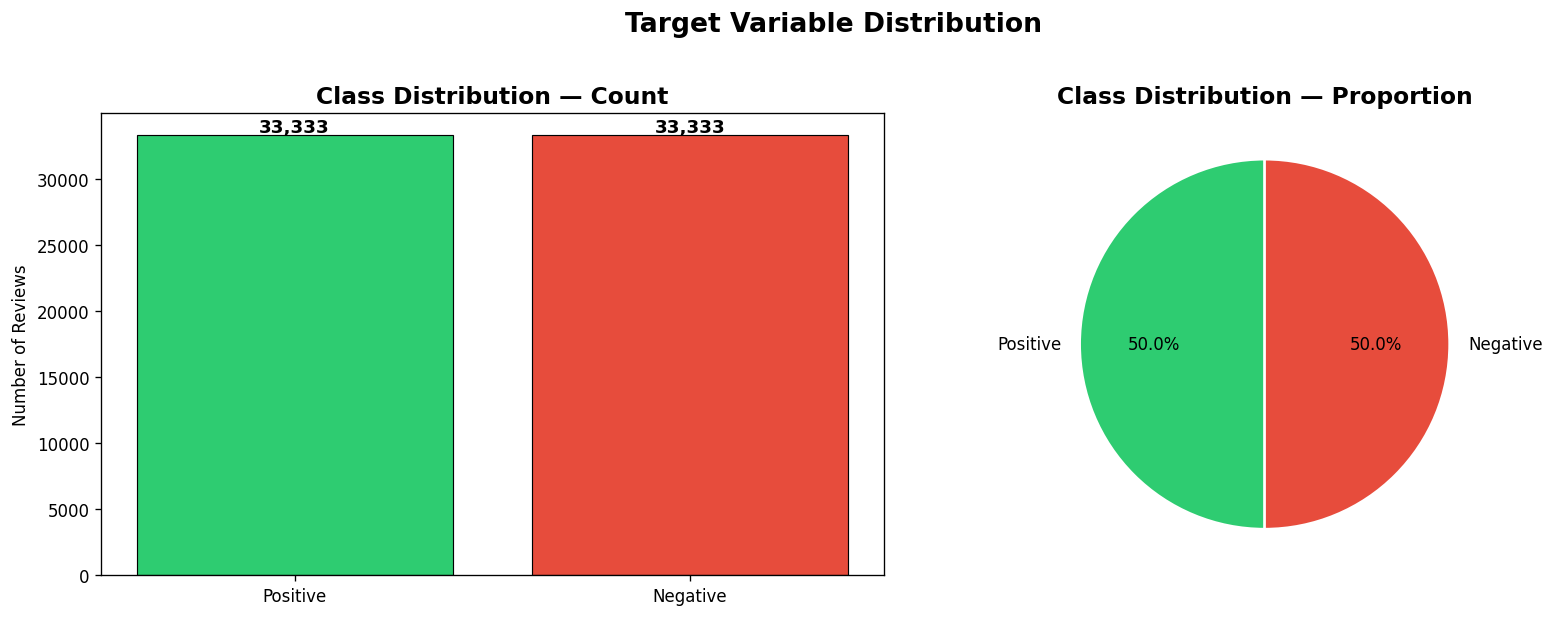


Class imbalance ratio (max/min): 1.00x
✅ Classes are reasonably balanced


In [48]:
# ── 3.1  Class Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
vc = df['label'].value_counts()
bars = axes[0].bar(vc.index, vc.values, color=PALETTE, edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Imbalance ratio
imbalance = vc.max() / vc.min()
print(f'\nClass imbalance ratio (max/min): {imbalance:.2f}x')
if imbalance > 2:
    print('⚠️  Significant imbalance — class weighting will be applied during training')
else:
    print('✅ Classes are reasonably balanced')


In [49]:
# ── Apply All 5 Preprocessing Strategies ─────────────────────────────────
print('Applying preprocessing strategies... (this may take a few minutes)')
t0 = time.time()

# Strategy A: Basic Cleaning Only
df['text_A'] = df['text'].apply(basic_clean)
print(f'  Strategy A (basic clean)         — done [{time.time()-t0:.1f}s]')

# Strategy B: Cleaning + Stopword Removal
df['text_B'] = df['text_A'].apply(remove_stopwords)
print(f'  Strategy B (+ stopwords)         — done [{time.time()-t0:.1f}s]')

# Strategy C: Cleaning + Light Stemming
df['text_C'] = df['text_A'].apply(light_stem)
print(f'  Strategy C (+ stemming)          — done [{time.time()-t0:.1f}s]')

# Strategy D: Cleaning + Stemming + Full Normalization
df['text_D'] = df['text_A'].apply(normalize_arabic).apply(remove_stopwords).apply(light_stem)
print(f'  Strategy D (+ norm + stop + stem)— done [{time.time()-t0:.1f}s]')

# Strategy E: Cleaning + Normalization only (no stemming — control)
df['text_E'] = df['text_A'].apply(normalize_arabic)
print(f'  Strategy E (+ norm, no stem)     — done [{time.time()-t0:.1f}s]')

print(f'\n✅ All strategies applied in {time.time()-t0:.1f}s')

# Show comparison
print('\nPreprocessing comparison (row 0):')
for s in ['text', 'text_A', 'text_B', 'text_C', 'text_D', 'text_E']:
    print(f'  [{s}] {df[s][0][:80]}...')


Applying preprocessing strategies... (this may take a few minutes)
  Strategy A (basic clean)         — done [6.1s]
  Strategy B (+ stopwords)         — done [6.7s]
  Strategy C (+ stemming)          — done [14.3s]
  Strategy D (+ norm + stop + stem)— done [23.3s]
  Strategy E (+ norm, no stem)     — done [25.8s]

✅ All strategies applied in 25.8s

Preprocessing comparison (row 0):
  [text] ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم...
  [text_A] ممتاز نوعا ما النظافة والموقع والتجهيز والشاطيء المطعم...
  [text_B] ممتاز نوعا النظافة والموقع والتجهيز والشاطيء المطعم...
  [text_C] ممتاز نوعا ما نظاف موقع تجهيز شاطيء مطعم...
  [text_D] ممتاز نوعا نظافه موقع تجهيز شاطيء مطعم...
  [text_E] ممتاز نوعا ما النظافه والموقع والتجهيز والشاطيء المطعم...


Vocabulary Statistics by Strategy:
              label vocab_size total_tokens    avg_len
A       Basic Clean     254776      3505805  52.587556
B       + Stopwords     254250      2687918  40.318933
C        + Stemming     130299      3505805  52.587556
D  + Norm+Stop+Stem     116920      2794578  41.918834
E  + Norm (no stem)     223067      3505805  52.587556


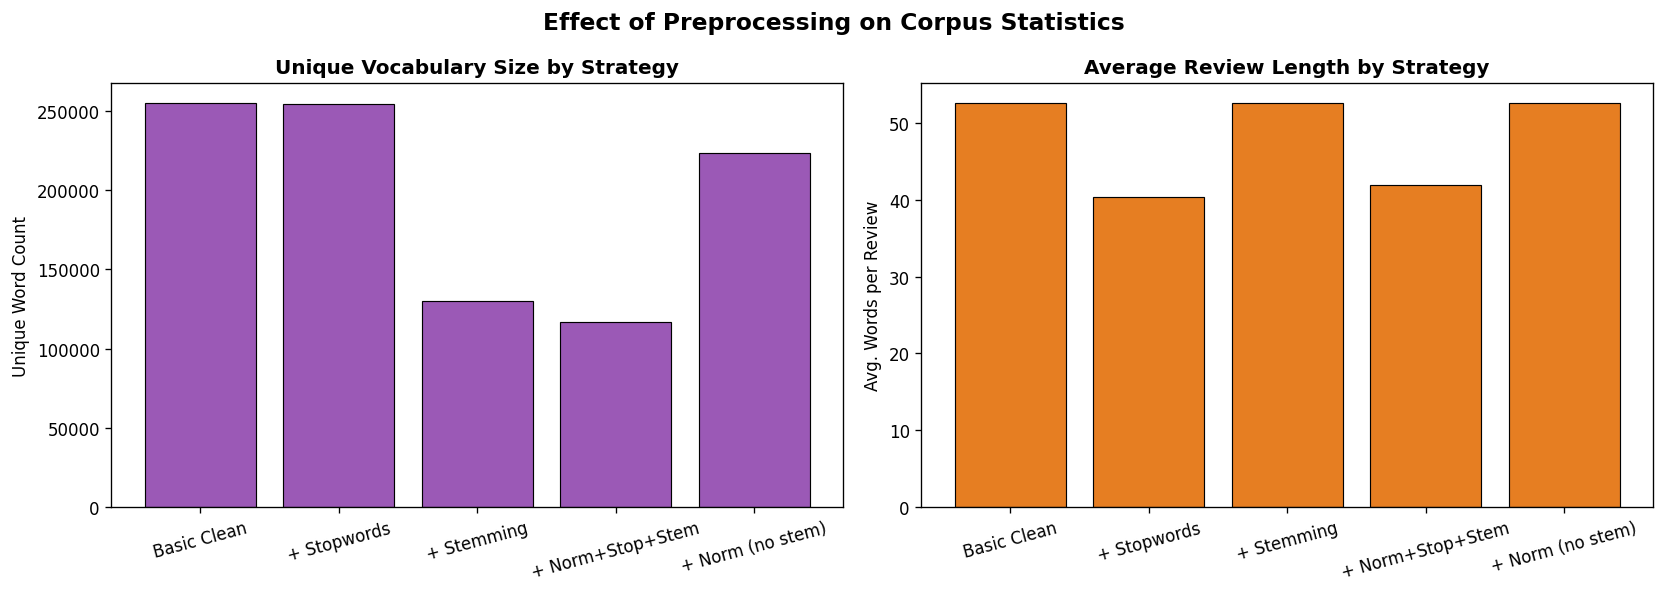

In [50]:
# ── Vocabulary Size Comparison Across Strategies ──────────────────────────
strategies = {'A': 'text_A', 'B': 'text_B', 'C': 'text_C', 'D': 'text_D', 'E': 'text_E'}
strategy_labels = {
    'A': 'Basic Clean',
    'B': '+ Stopwords',
    'C': '+ Stemming',
    'D': '+ Norm+Stop+Stem',
    'E': '+ Norm (no stem)'
}

vocab_stats = {}
for key, col in strategies.items():
    tokens = df[col].str.split().explode()
    vocab_stats[key] = {
        'label': strategy_labels[key],
        'vocab_size': tokens.nunique(),
        'total_tokens': len(tokens),
        'avg_len': df[col].str.split().str.len().mean()
    }

stats_df = pd.DataFrame(vocab_stats).T
print('Vocabulary Statistics by Strategy:')
print(stats_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = [v['label'] for v in vocab_stats.values()]
vocab_sizes = [v['vocab_size'] for v in vocab_stats.values()]
avg_lens = [v['avg_len'] for v in vocab_stats.values()]

axes[0].bar(x, vocab_sizes, color='#9b59b6', edgecolor='black', linewidth=0.7)
axes[0].set_title('Unique Vocabulary Size by Strategy', fontweight='bold')
axes[0].set_ylabel('Unique Word Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(x, avg_lens, color='#e67e22', edgecolor='black', linewidth=0.7)
axes[1].set_title('Average Review Length by Strategy', fontweight='bold')
axes[1].set_ylabel('Avg. Words per Review')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Effect of Preprocessing on Corpus Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [51]:
# ── Train / Validation / Test Split ──────────────────────────────────────
# We use Strategy D (best normalization) as primary text column for embedding methods
# Individual experiments will swap text columns as needed

le = LabelEncoder()
y = le.fit_transform(df['label'])
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Primary split: 70% train | 15% val | 15% test
X_train_idx, X_test_idx = train_test_split(
    df.index, test_size=CONFIG['test_size'], random_state=42, stratify=y
)
y_train_full = y[X_train_idx]
X_train_idx2, X_val_idx = train_test_split(
    X_train_idx, test_size=CONFIG['val_size']/(1-CONFIG['test_size']),
    random_state=42, stratify=y_train_full
)

y_train = y[X_train_idx2]
y_val   = y[X_val_idx]
y_test  = y[X_test_idx]

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train_idx2):,} ({len(X_train_idx2)/len(df)*100:.1f}%)')
print(f'  Val   : {len(X_val_idx):,} ({len(X_val_idx)/len(df)*100:.1f}%)')
print(f'  Test  : {len(X_test_idx):,} ({len(X_test_idx)/len(df)*100:.1f}%)')

# Compute class weights for imbalanced data
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f'\nClass weights: {class_weight_dict}')


Label encoding: {'Negative': np.int64(0), 'Positive': np.int64(1)}

Split sizes:
  Train : 46,666 (70.0%)
  Val   : 10,000 (15.0%)
  Test  : 10,000 (15.0%)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [52]:
# ── Neural Network Builder (MANDATORY: exactly 1 hidden layer) ────────────
def build_nn(input_dim, hidden_size=512, activation='relu',
             dropout_rate=0.3, optimizer='adam', lr=1e-3):
    """
    Build a Neural Network with EXACTLY ONE hidden layer.
    Architecture: Input → Dense(hidden_size, activation) → Dropout → Dense(3, softmax)
    """
    opt_map = {
        'adam'    : Adam(learning_rate=lr),
        'rmsprop' : RMSprop(learning_rate=lr),
        'sgd'     : SGD(learning_rate=lr, momentum=0.9),
    }
    model = Sequential([
        Input(shape=(input_dim,)),
        # ── SINGLE HIDDEN LAYER (mandatory constraint) ──────────────────
        Dense(hidden_size, activation=activation, name='hidden_layer'),
        Dropout(dropout_rate, name='regularization'),
        # ── OUTPUT LAYER ─────────────────────────────────────────────────
        Dense(CONFIG['num_classes'], activation='softmax', name='output_layer'),
    ], name='1HL_Neural_Network')

    model.compile(
        optimizer=opt_map.get(optimizer, optimizer),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Default callbacks
def get_callbacks(filepath='best_model.h5'):
    return [
        EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0),
    ]


# Test build
test_model = build_nn(100)
test_model.summary()


Model: "1HL_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regularization (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,738 (206.01 KB)

 Trainable params: 52,738 (206.01 KB)

 Non-trainable params: 0 (0.00 B)

# **TF-IDF**

TF-IDF unigram feature matrix: (46666, 15000)

Results — TF-IDF (unigram)
Accuracy        : 0.8563 (85.63%)
Weighted F1     : 0.8562
Macro F1        : 0.8562
Training time   : 37.6s

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8761    0.8300    0.8524      5000
    Positive     0.8385    0.8826    0.8600      5000

    accuracy                         0.8563     10000
   macro avg     0.8573    0.8563    0.8562     10000
weighted avg     0.8573    0.8563    0.8562     10000



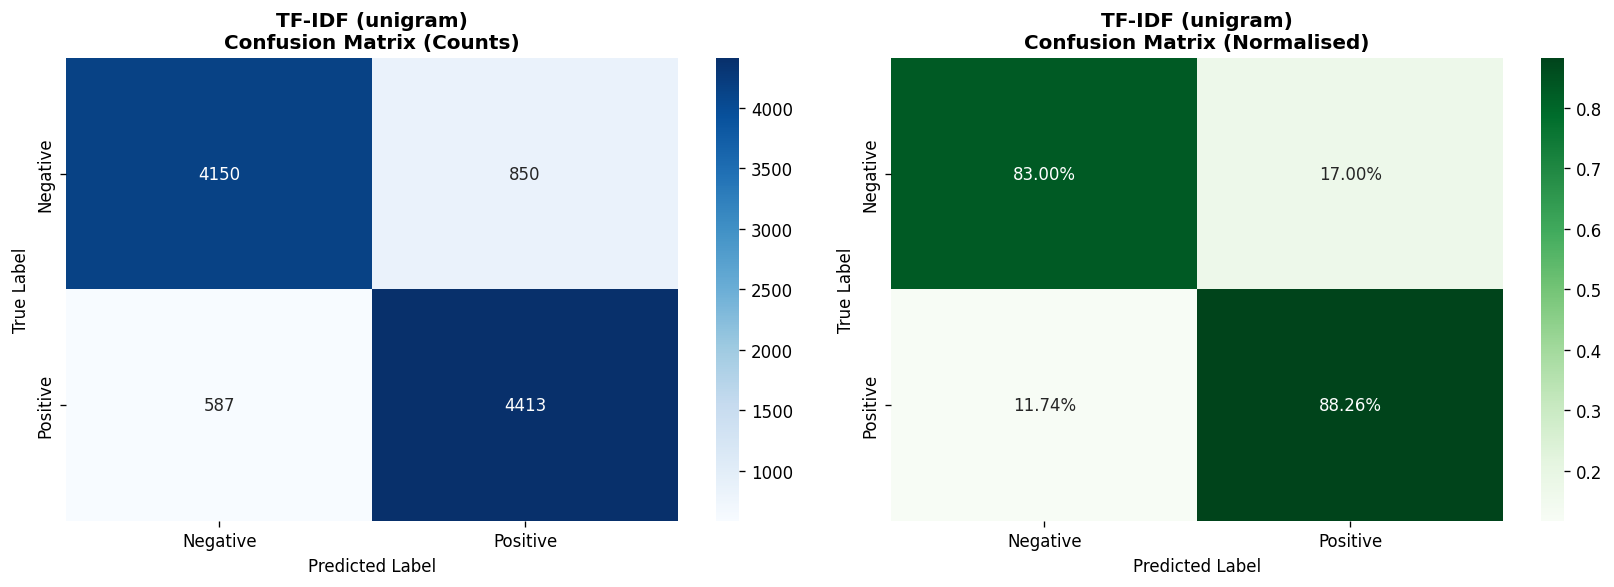

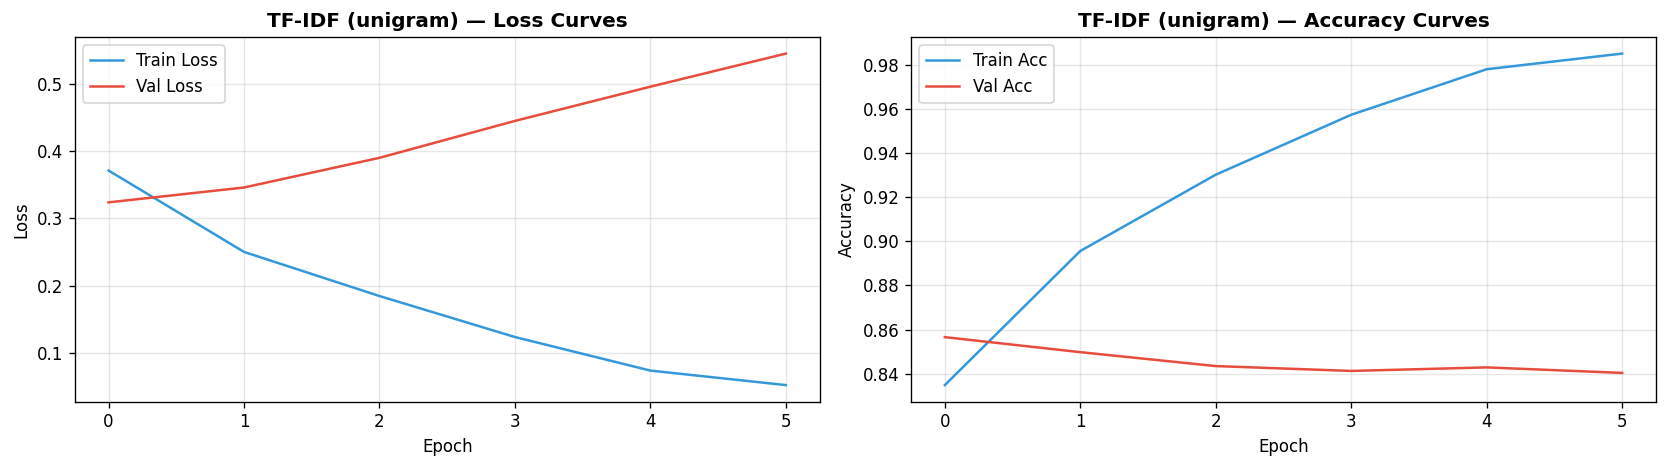

TF-IDF bigram feature matrix: (46666, 15000)

Results — TF-IDF (bigram)
Accuracy        : 0.8611 (86.11%)
Weighted F1     : 0.8610
Macro F1        : 0.8610
Training time   : 36.4s

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8831    0.8324    0.8570      5000
    Positive     0.8415    0.8898    0.8650      5000

    accuracy                         0.8611     10000
   macro avg     0.8623    0.8611    0.8610     10000
weighted avg     0.8623    0.8611    0.8610     10000



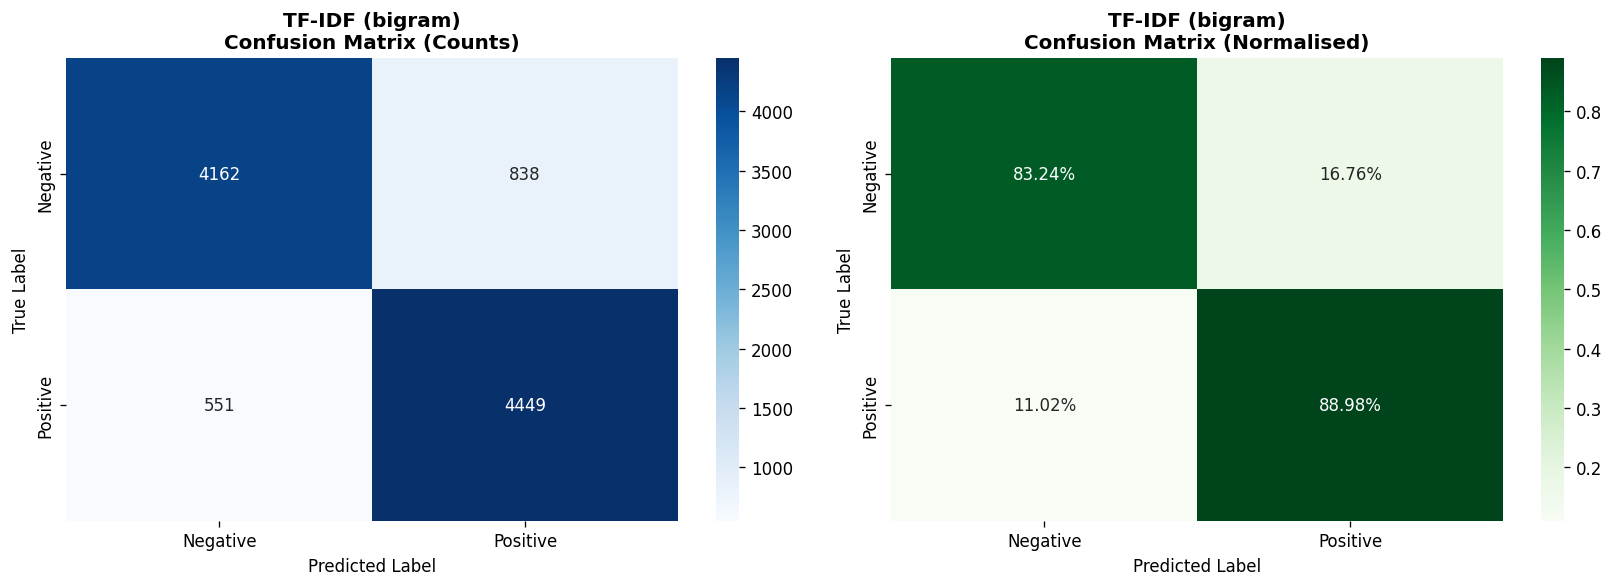

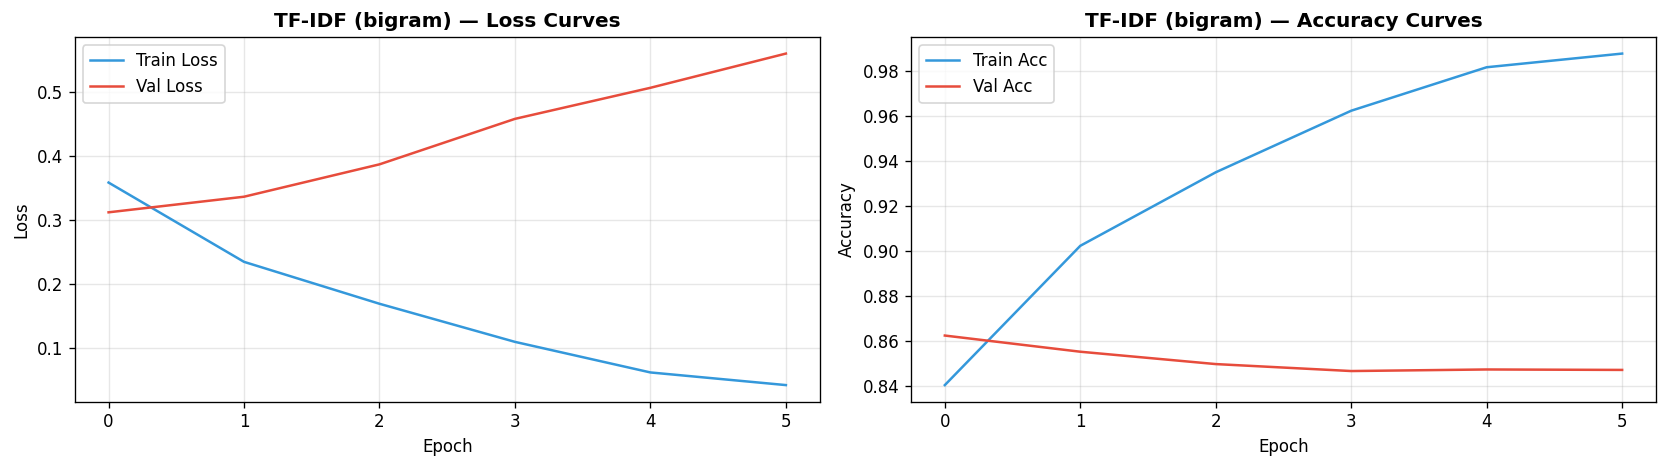

TF-IDF trigram feature matrix: (46666, 15000)

Results — TF-IDF (trigram)
Accuracy        : 0.8599 (85.99%)
Weighted F1     : 0.8598
Macro F1        : 0.8598
Training time   : 36.6s

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8804    0.8330    0.8560      5000
    Positive     0.8415    0.8868    0.8636      5000

    accuracy                         0.8599     10000
   macro avg     0.8609    0.8599    0.8598     10000
weighted avg     0.8609    0.8599    0.8598     10000



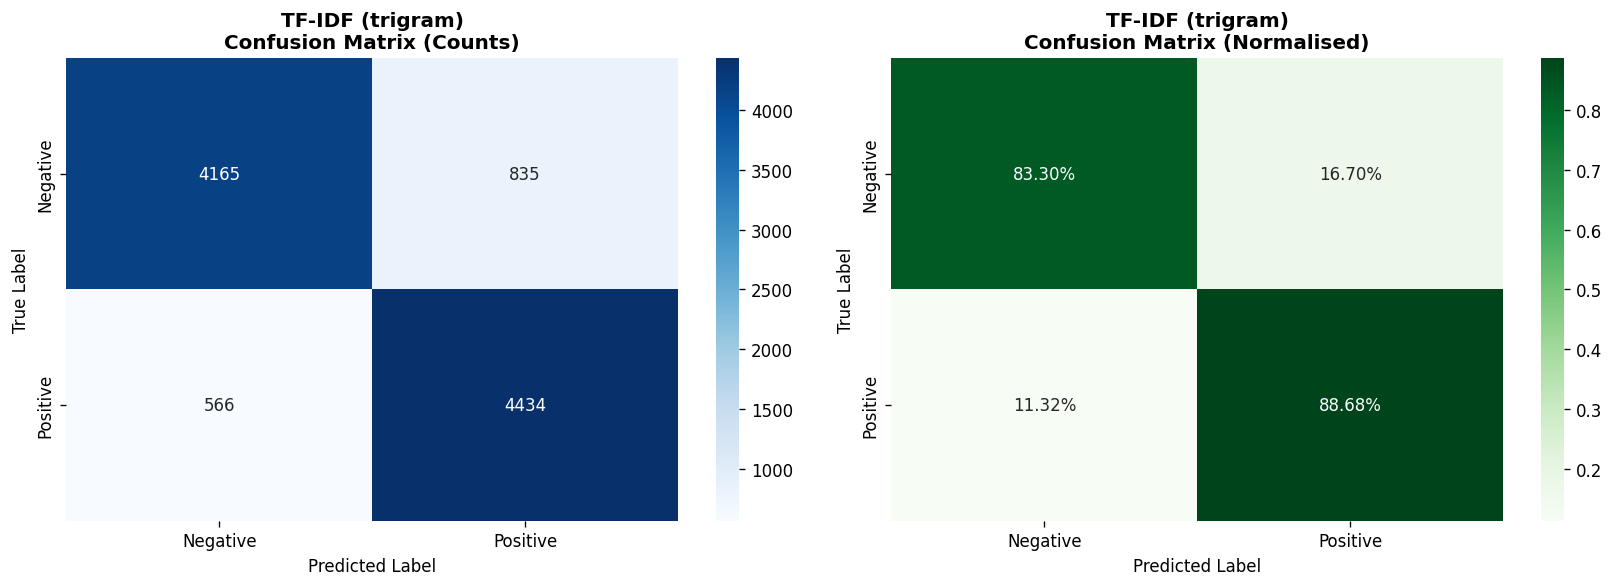

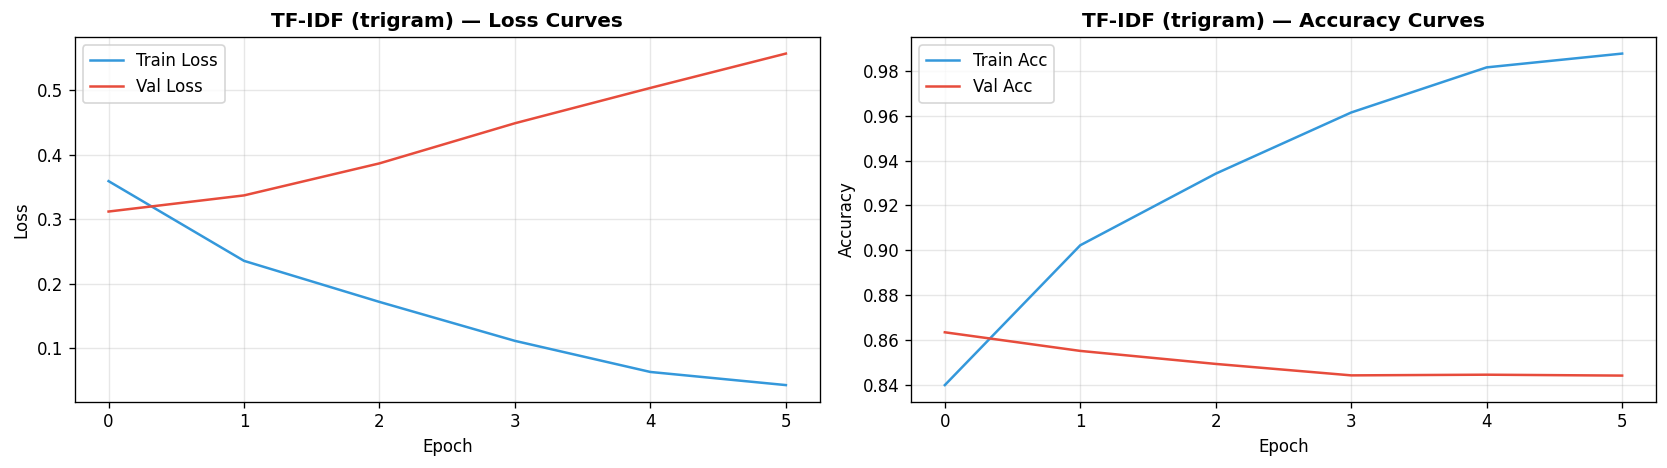

In [57]:
# ── 5.3  TF-IDF (Unigram, Bigram, Trigram comparison) ────────────────────
for ng_label, ng_range in [('unigram', (1,1)), ('bigram', (1,2)), ('trigram', (1,3))]:
    tfidf_vec = TfidfVectorizer(
        ngram_range=ng_range,
        max_features= 15000,
        min_df=2,
        sublinear_tf=True   # log(1+tf) scaling — beneficial for Arabic
    )
    X_tr = tfidf_vec.fit_transform(train_texts).toarray().astype('float32')
    X_vl = tfidf_vec.transform(val_texts).toarray().astype('float32')
    X_te = tfidf_vec.transform(test_texts).toarray().astype('float32')

    print(f'TF-IDF {ng_label} feature matrix: {X_tr.shape}')

    method_name = f'TF-IDF ({ng_label})'
    train_and_evaluate(
        X_tr, X_vl, X_te,
        y_train, y_val, y_test,
        method_name=method_name,
        hidden_size=1024, activation='relu', dropout=0.6 , epochs = 16
    )

    # Save best TF-IDF representation for later
    if ng_label == 'trigram':
        X_train_tfidf = X_tr
        X_val_tfidf   = X_vl
        X_test_tfidf  = X_te


# **Glove Embeddings**

Loaded 331,679 pretrained vectors from AraVec
Detected embedding dimension: 300
GloVe feature matrix: (46666, 300)

Results — GloVe
Accuracy        : 0.8160 (81.60%)
Weighted F1     : 0.8160
Macro F1        : 0.8160
Training time   : 26.5s

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8262    0.8004    0.8131      5000
    Positive     0.8064    0.8316    0.8188      5000

    accuracy                         0.8160     10000
   macro avg     0.8163    0.8160    0.8160     10000
weighted avg     0.8163    0.8160    0.8160     10000



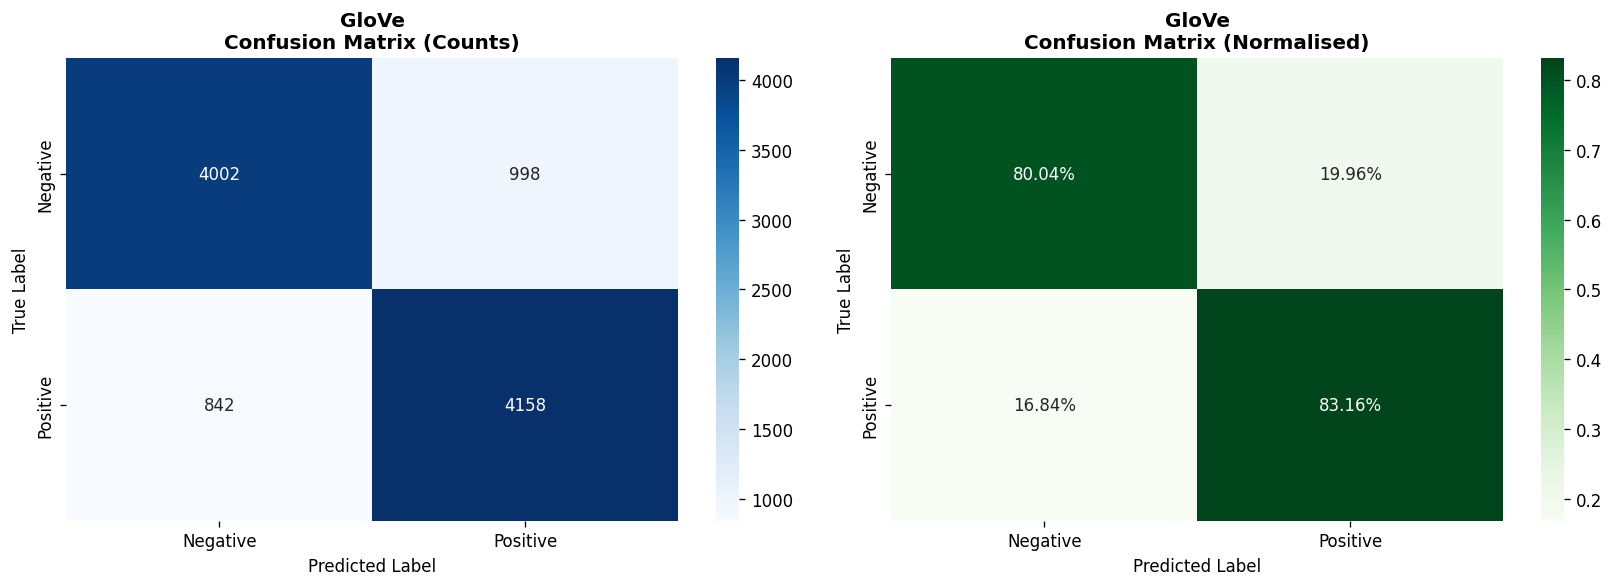

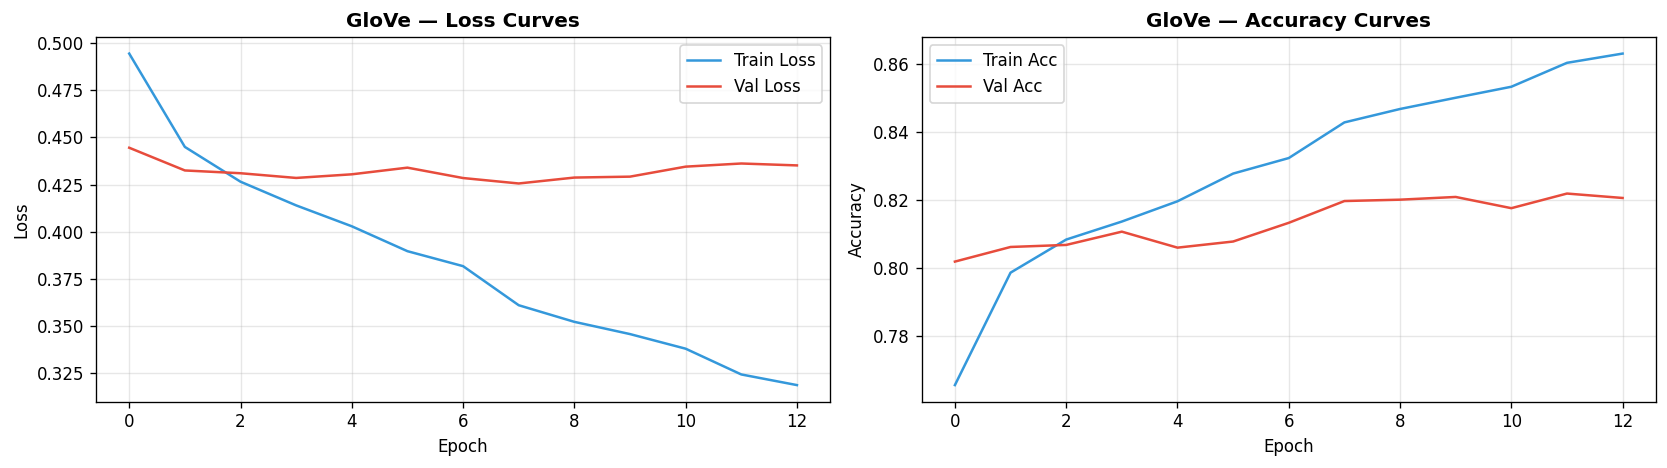

In [58]:
# ── 5.6  GloVe Embeddings (pre-trained Arabic GloVe) ─────────────────────

from gensim.models import Word2Vec

def load_glove_vectors(model_path):
    """
    Load AraVec Word2Vec model and convert it
    to a dictionary for average embedding usage.
    """

    embeddings = {}

    try:
        model = Word2Vec.load(model_path)

        for word in model.wv.key_to_index:
            embeddings[word] = model.wv[word]

        print(f"Loaded {len(embeddings):,} pretrained vectors from AraVec")

    except Exception as e:
        print(f"⚠️ Error loading embeddings: {e}")
        print("Falling back to Word2Vec proxy.")
        return {}

    return embeddings





def text_to_glove_avg(text, glove_dict, dim):
    words = text.split()
    vecs = [glove_dict[w] for w in words if w in glove_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)



# Attempt to load pre-trained GloVe
glove_dict = load_glove_vectors(CONFIG['glove_path'])

# Automatically detect embedding dimension
sample_word = next(iter(glove_dict))
CONFIG['glove_dim'] = len(glove_dict[sample_word])

print("Detected embedding dimension:", CONFIG['glove_dim'])

X_train_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_train_idx2, 'text_D'].fillna('')
], dtype='float32')
X_val_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_val_idx, 'text_D'].fillna('')
], dtype='float32')
X_test_glove = np.array([
    text_to_glove_avg(t, glove_dict, CONFIG['glove_dim'])
    for t in df.loc[X_test_idx, 'text_D'].fillna('')
], dtype='float32')

print(f'GloVe feature matrix: {X_train_glove.shape}')

model_glove, hist_glove = train_and_evaluate(
    X_train_glove, X_val_glove, X_test_glove,
    y_train, y_val, y_test,
    method_name='GloVe',
    hidden_size=256, activation='relu', dropout=0.3
)


# **Bert**

In [60]:
# ── 5.7  BERT / AraBERT (Feature Extraction — NO Fine-tuning) ─────────────
#
# We use AraBERT (aubmindlab/bert-base-arabertv02) as a frozen feature extractor.
# The [CLS] token embedding (768-dim) represents the entire sentence.
# We then pass these embeddings to our 1-hidden-layer neural network.
#
# This follows the "embedding as features" paradigm:
# BERT → fixed 768-dim vector → 1HL NN → softmax

def extract_bert_embeddings(texts, model_name, batch_size=32):
    """
    Extract [CLS] embeddings from BERT.
    The model is frozen — no gradient updates to BERT parameters.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    bert = AutoModel.from_pretrained(model_name)
    bert.eval()  # Inference mode — critical for consistent embeddings

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    bert.to(device)
    print(f'BERT extraction device: {device}')

    all_embeddings = []
    texts_list = list(texts)

    for i in range(0, len(texts_list), batch_size):
        batch = texts_list[i:i+batch_size]
        # AraBERT has max_length=512
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert(**encoded)

        # [CLS] token is at position 0
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

        if (i // batch_size) % 10 == 0:
            print(f'  Processed {min(i+batch_size, len(texts_list)):,}/{len(texts_list):,}', end='\r')

    print()
    return np.vstack(all_embeddings).astype('float32')


print(f'Extracting BERT embeddings using: {CONFIG["arabert_model"]}')
print('This will take several minutes without GPU...')

# Use Strategy A (minimal cleaning) for BERT — BERT handles its own tokenization
t0 = time.time()
X_train_bert = extract_bert_embeddings(
    df.loc[X_train_idx2, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
X_val_bert = extract_bert_embeddings(
    df.loc[X_val_idx, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
X_test_bert = extract_bert_embeddings(
    df.loc[X_test_idx, 'text_A'].fillna(''), CONFIG['arabert_model'],
    batch_size=CONFIG['bert_batch_size']
)
bert_extraction_time = time.time() - t0

print(f'BERT feature matrix: {X_train_bert.shape}')
print(f'Extraction time    : {bert_extraction_time:.0f}s')

# Save embeddings to avoid re-computing
np.save('bert_train.npy', X_train_bert)
np.save('bert_val.npy',   X_val_bert)
np.save('bert_test.npy',  X_test_bert)
print('✅ BERT embeddings saved to disk')


Extracting BERT embeddings using: aubmindlab/bert-base-arabertv02
This will take several minutes without GPU...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT extraction device: cuda
  Processed 46,432/46,666


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT extraction device: cuda
  Processed 9,952/10,000


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT extraction device: cuda
  Processed 9,952/10,000
BERT feature matrix: (46666, 768)
Extraction time    : 581s
✅ BERT embeddings saved to disk



Results — AraBERT (Feature Extraction)
Accuracy        : 0.8706 (87.06%)
Weighted F1     : 0.8706
Macro F1        : 0.8706
Training time   : 30.7s

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8649    0.8784    0.8716      5000
    Positive     0.8765    0.8628    0.8696      5000

    accuracy                         0.8706     10000
   macro avg     0.8707    0.8706    0.8706     10000
weighted avg     0.8707    0.8706    0.8706     10000



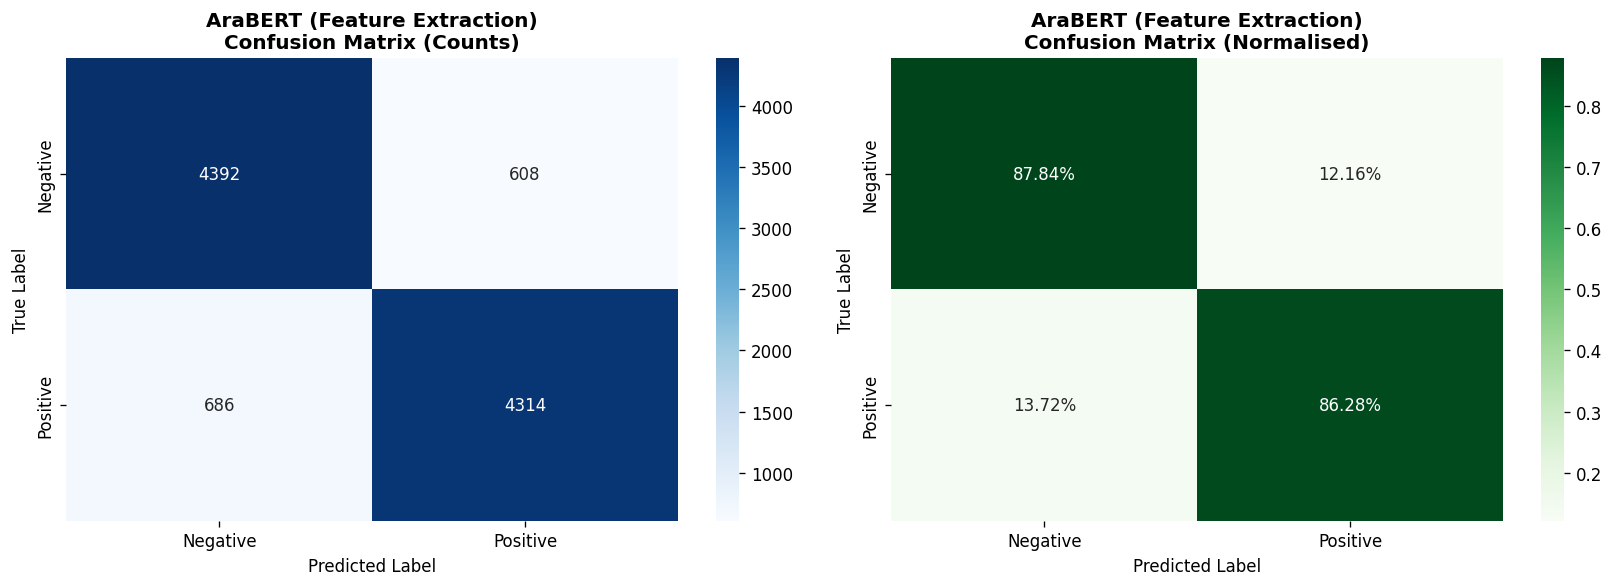

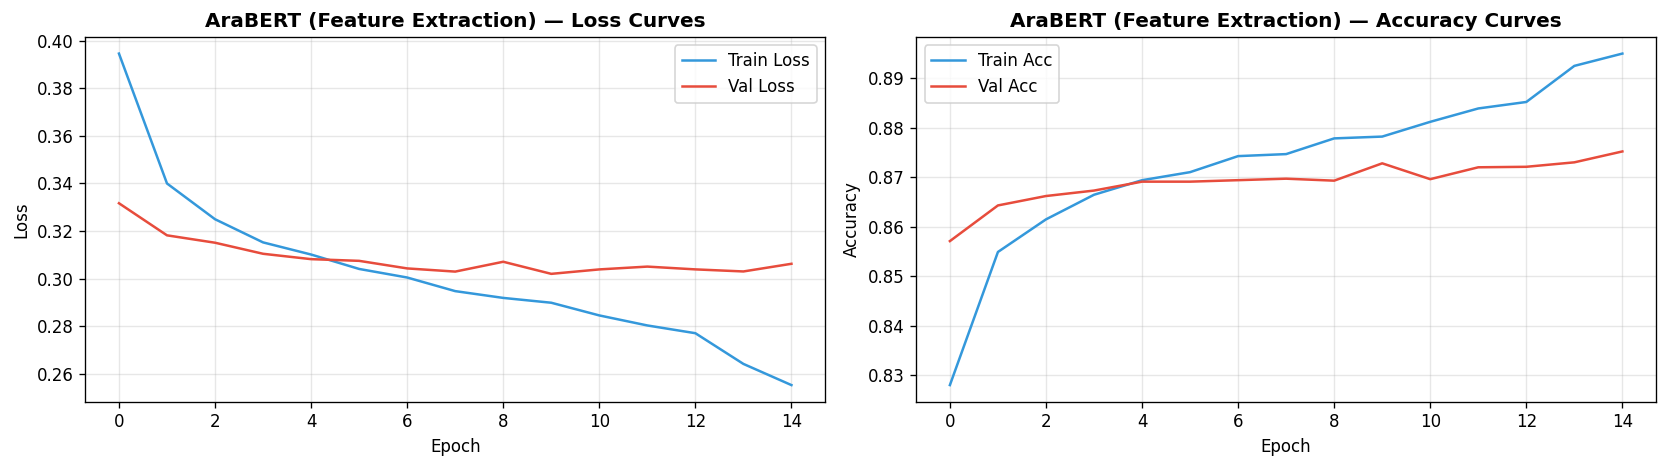

In [61]:
# ── Load saved BERT embeddings (if already extracted) ─────────────────────
# Uncomment this cell if resuming after BERT extraction:
# X_train_bert = np.load('bert_train.npy')
# X_val_bert   = np.load('bert_val.npy')
# X_test_bert  = np.load('bert_test.npy')

model_bert, hist_bert = train_and_evaluate(
    X_train_bert, X_val_bert, X_test_bert,
    y_train, y_val, y_test,
    method_name='AraBERT (Feature Extraction)',
    hidden_size=512, activation='relu', dropout=0.5,
    lr=5e-4   # Lower LR beneficial for high-dimensional BERT features
)


## §6 — Preprocessing Strategy Comparison


In [62]:
# ── 6.1  Compare All Preprocessing Strategies (Fixed: TF-IDF bigram) ──────
PREPROCESSING_RESULTS = {}

strategy_descriptions = {
    'A': 'Basic Clean',
    'B': 'Clean + Stopwords',
    'C': 'Clean + Stemming',
    'D': 'Clean + Norm + Stop + Stem',
    'E': 'Clean + Norm (no stem)'
}

for key, col in strategies.items():
    desc = strategy_descriptions[key]
    print(f'\nStrategy {key}: {desc}')

    tr_texts = df.loc[X_train_idx2, col].fillna('')
    vl_texts = df.loc[X_val_idx,   col].fillna('')
    te_texts = df.loc[X_test_idx,  col].fillna('')

    vec = TfidfVectorizer(ngram_range=(1,2), max_features=15000, min_df=2, sublinear_tf=True)
    X_tr = vec.fit_transform(tr_texts).toarray().astype('float32')
    X_vl = vec.transform(vl_texts).toarray().astype('float32')
    X_te = vec.transform(te_texts).toarray().astype('float32')

    model = build_nn(X_tr.shape[1], hidden_size=512, activation='relu', dropout_rate=0.3)
    callbacks = get_callbacks(f'best_strategy_{key}.h5')

    t0 = time.time()
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict, callbacks=callbacks, verbose=0
    )
    train_time = time.time() - t0

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    epochs_run = len(history.history['loss'])

    PREPROCESSING_RESULTS[f'Strategy {key}: {desc}'] = {
        'accuracy': acc, 'f1': f1,
        'train_time': train_time, 'epochs': epochs_run,
        'vocab': len(vec.vocabulary_)
    }
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.0f}s | Vocab: {len(vec.vocabulary_):,}')



Strategy A: Basic Clean
  Accuracy: 0.8562 | F1: 0.8562 | Time: 31s | Vocab: 15,000

Strategy B: Clean + Stopwords
  Accuracy: 0.8513 | F1: 0.8512 | Time: 31s | Vocab: 15,000

Strategy C: Clean + Stemming
  Accuracy: 0.8646 | F1: 0.8646 | Time: 30s | Vocab: 15,000

Strategy D: Clean + Norm + Stop + Stem
  Accuracy: 0.8597 | F1: 0.8596 | Time: 30s | Vocab: 15,000

Strategy E: Clean + Norm (no stem)
  Accuracy: 0.8668 | F1: 0.8668 | Time: 31s | Vocab: 15,000


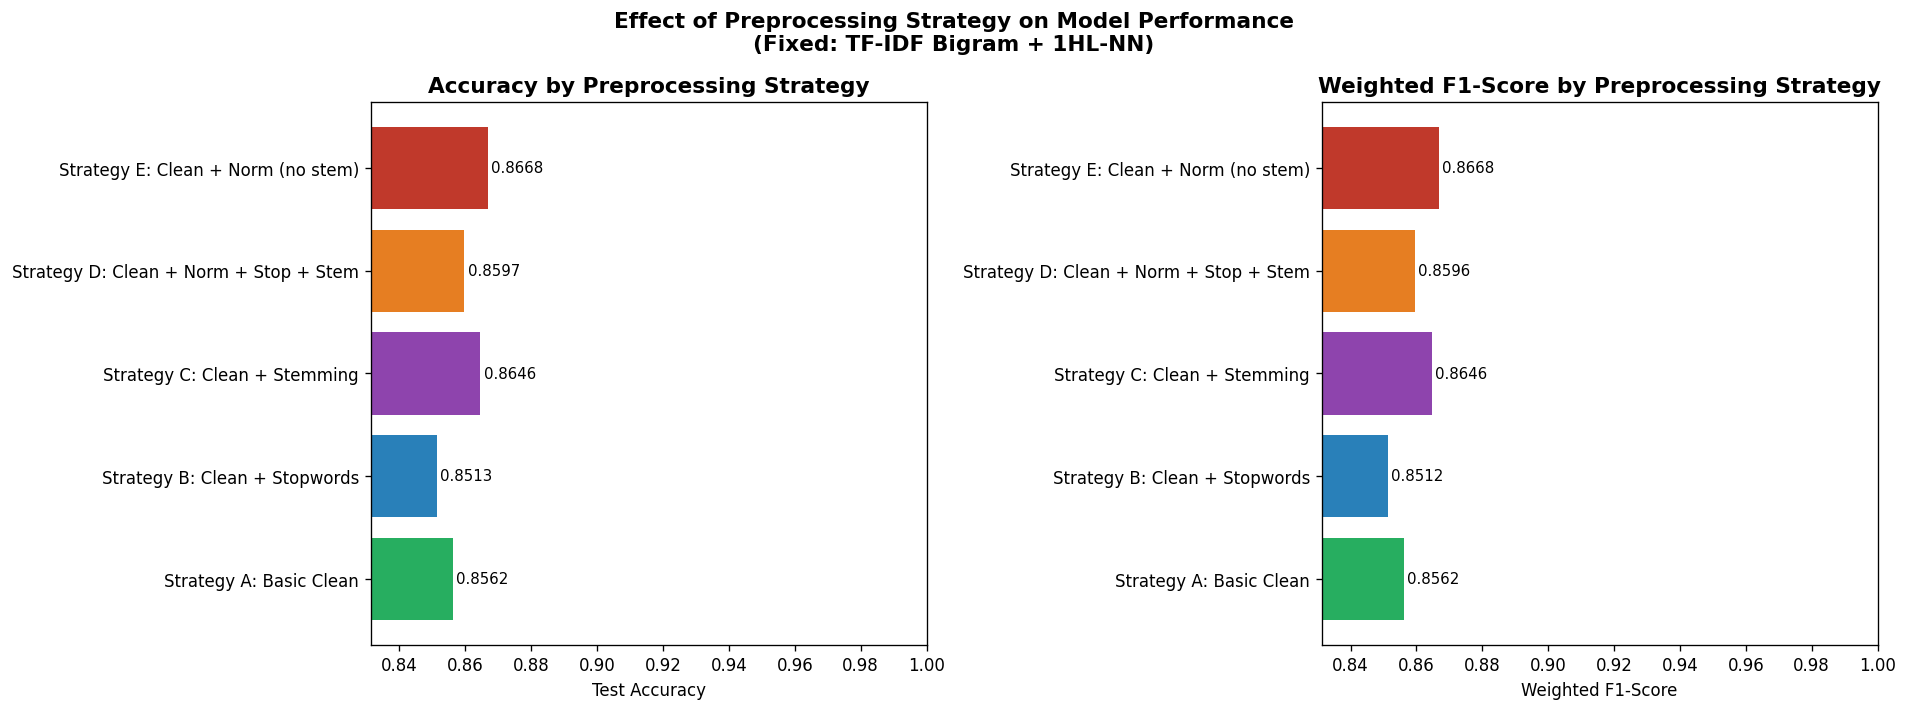


Preprocessing Strategy Comparison Table:
                              Strategy  Accuracy       F1  Train_Time  Epochs   Vocab
               Strategy A: Basic Clean    0.8562 0.856176   30.878154     6.0 15000.0
         Strategy B: Clean + Stopwords    0.8513 0.851225   30.755951     6.0 15000.0
          Strategy C: Clean + Stemming    0.8646 0.864572   30.257077     6.0 15000.0
Strategy D: Clean + Norm + Stop + Stem    0.8597 0.859574   30.233273     6.0 15000.0
    Strategy E: Clean + Norm (no stem)    0.8668 0.866774   30.538098     6.0 15000.0


In [63]:
# ── Visualise Preprocessing Comparison ───────────────────────────────────
prep_df = pd.DataFrame(PREPROCESSING_RESULTS).T.reset_index()
prep_df.columns = ['Strategy', 'Accuracy', 'F1', 'Train_Time', 'Epochs', 'Vocab']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
bars1 = axes[0].barh(prep_df['Strategy'], prep_df['Accuracy'],
                      color=['#27ae60','#2980b9','#8e44ad','#e67e22','#c0392b'])
axes[0].set_title('Accuracy by Preprocessing Strategy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_xlim(prep_df['Accuracy'].min() - 0.02, 1.0)
for bar, val in zip(bars1, prep_df['Accuracy']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1 Score
bars2 = axes[1].barh(prep_df['Strategy'], prep_df['F1'],
                      color=['#27ae60','#2980b9','#8e44ad','#e67e22','#c0392b'])
axes[1].set_title('Weighted F1-Score by Preprocessing Strategy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weighted F1-Score')
axes[1].set_xlim(prep_df['F1'].min() - 0.02, 1.0)
for bar, val in zip(bars2, prep_df['F1']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Effect of Preprocessing Strategy on Model Performance\n(Fixed: TF-IDF Bigram + 1HL-NN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPreprocessing Strategy Comparison Table:')
print(prep_df.to_string(index=False))


In [64]:
# ── 7.1  Stemming vs No-Stemming Direct Comparison ───────────────────────
# Strategy C (stemming) vs Strategy E (same pipeline, no stemming)
# Both use cleaning + normalization to isolate stemming's effect

print('Direct comparison: WITH stemming (C) vs WITHOUT stemming (E)')
print('Fixed: TF-IDF trigram, 512-unit hidden layer')

stemming_results = {}

for label, col in [('WITH Stemming (Strategy C)', 'text_C'),
                    ('WITHOUT Stemming (Strategy E)', 'text_E')]:
    tr_texts = df.loc[X_train_idx2, col].fillna('')
    vl_texts = df.loc[X_val_idx,   col].fillna('')
    te_texts = df.loc[X_test_idx,  col].fillna('')

    vec = TfidfVectorizer(ngram_range=(1,3), max_features=20000,
                          min_df=2, sublinear_tf=True)
    X_tr = vec.fit_transform(tr_texts).toarray().astype('float32')
    X_vl = vec.transform(vl_texts).toarray().astype('float32')
    X_te = vec.transform(te_texts).toarray().astype('float32')

    model = build_nn(X_tr.shape[1])
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(), verbose=0
    )
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    stemming_results[label] = {'accuracy': acc, 'f1': f1, 'vocab': len(vec.vocabulary_)}
    print(f'{label}: Acc={acc:.4f}, F1={f1:.4f}, Vocab={len(vec.vocabulary_):,}')

# Interpretation
c_acc = stemming_results['WITH Stemming (Strategy C)']['accuracy']
e_acc = stemming_results['WITHOUT Stemming (Strategy E)']['accuracy']
delta = c_acc - e_acc
print(f'\nStemming effect: {delta:+.4f} accuracy points')
if delta > 0:
    print('→ Stemming HELPS: reduces vocabulary, improves generalisation')
elif delta < 0:
    print('→ Stemming HURTS: stem collisions cause information loss')
else:
    print('→ Stemming has NEUTRAL effect')


Direct comparison: WITH stemming (C) vs WITHOUT stemming (E)
Fixed: TF-IDF trigram, 512-unit hidden layer
WITH Stemming (Strategy C): Acc=0.8663, F1=0.8663, Vocab=20,000
WITHOUT Stemming (Strategy E): Acc=0.8677, F1=0.8677, Vocab=20,000

Stemming effect: -0.0014 accuracy points
→ Stemming HURTS: stem collisions cause information loss


Experiment 1: Hidden Layer Size
Fixed: TF-IDF bigram, relu, dropout=0.3, adam lr=1e-3
  Hidden=  64: Acc=0.8636, F1=0.8635, Params=960,194
  Hidden= 128: Acc=0.8623, F1=0.8622, Params=1,920,386
  Hidden= 256: Acc=0.8601, F1=0.8600, Params=3,840,770
  Hidden= 512: Acc=0.8585, F1=0.8584, Params=7,681,538
  Hidden=1024: Acc=0.8595, F1=0.8594, Params=15,363,074


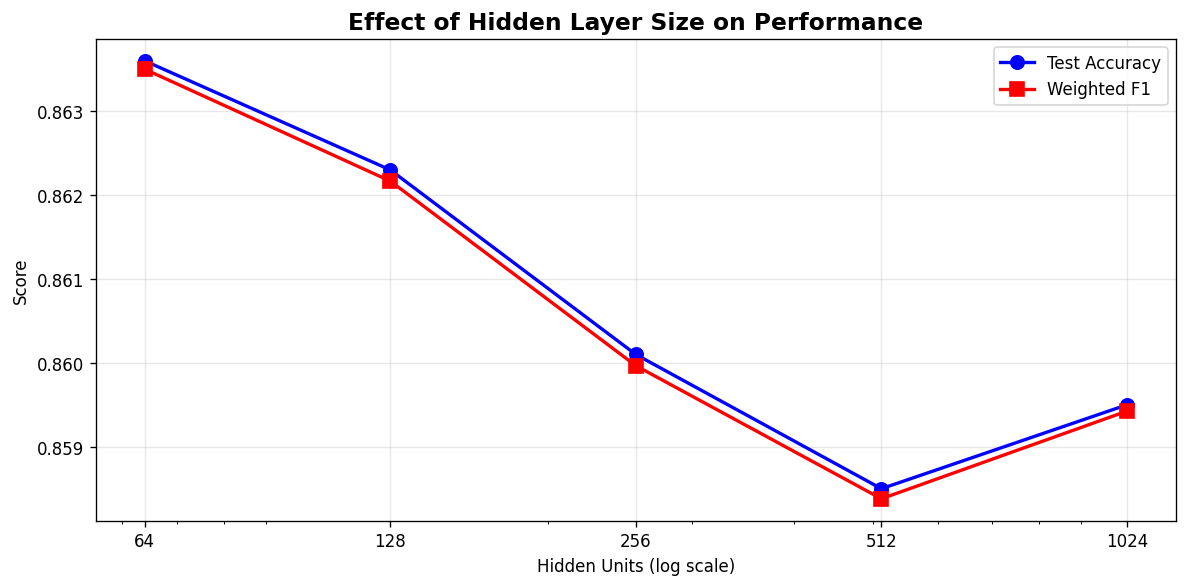

In [65]:
# ── 8.1  Hidden Layer Size Experiment ────────────────────────────────────
# We use TF-IDF bigram as the representative sparse feature set
# (fast to iterate; BERT would take too long for grid search)

print('Experiment 1: Hidden Layer Size')
print('Fixed: TF-IDF bigram, relu, dropout=0.3, adam lr=1e-3')
hidden_size_results = {}

for h_size in [64, 128, 256, 512, 1024]:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=h_size,
                     activation='relu', dropout_rate=0.3)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    hidden_size_results[h_size] = {'acc': acc, 'f1': f1,
                                    'params': model.count_params()}
    print(f'  Hidden={h_size:4d}: Acc={acc:.4f}, F1={f1:.4f}, Params={model.count_params():,}')

# Plot
sizes = list(hidden_size_results.keys())
accs  = [v['acc'] for v in hidden_size_results.values()]
f1s   = [v['f1']  for v in hidden_size_results.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, accs, 'b-o', label='Test Accuracy', linewidth=2, markersize=8)
ax.plot(sizes, f1s,  'r-s', label='Weighted F1',   linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_title('Effect of Hidden Layer Size on Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Hidden Units (log scale)')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Experiment 3: Dropout Rate
Fixed: TF-IDF bigram, hidden=512, relu, adam lr=1e-3
  Dropout=0.0: Test=0.8582, Train=0.9938, Gap=0.1356
  Dropout=0.1: Test=0.8586, Train=0.9943, Gap=0.1357
  Dropout=0.2: Test=0.8596, Train=0.9941, Gap=0.1345
  Dropout=0.3: Test=0.8594, Train=0.9936, Gap=0.1342
  Dropout=0.4: Test=0.8594, Train=0.9924, Gap=0.1330
  Dropout=0.5: Test=0.8610, Train=0.9893, Gap=0.1283
  Dropout=0.6: Test=0.8636, Train=0.9829, Gap=0.1193


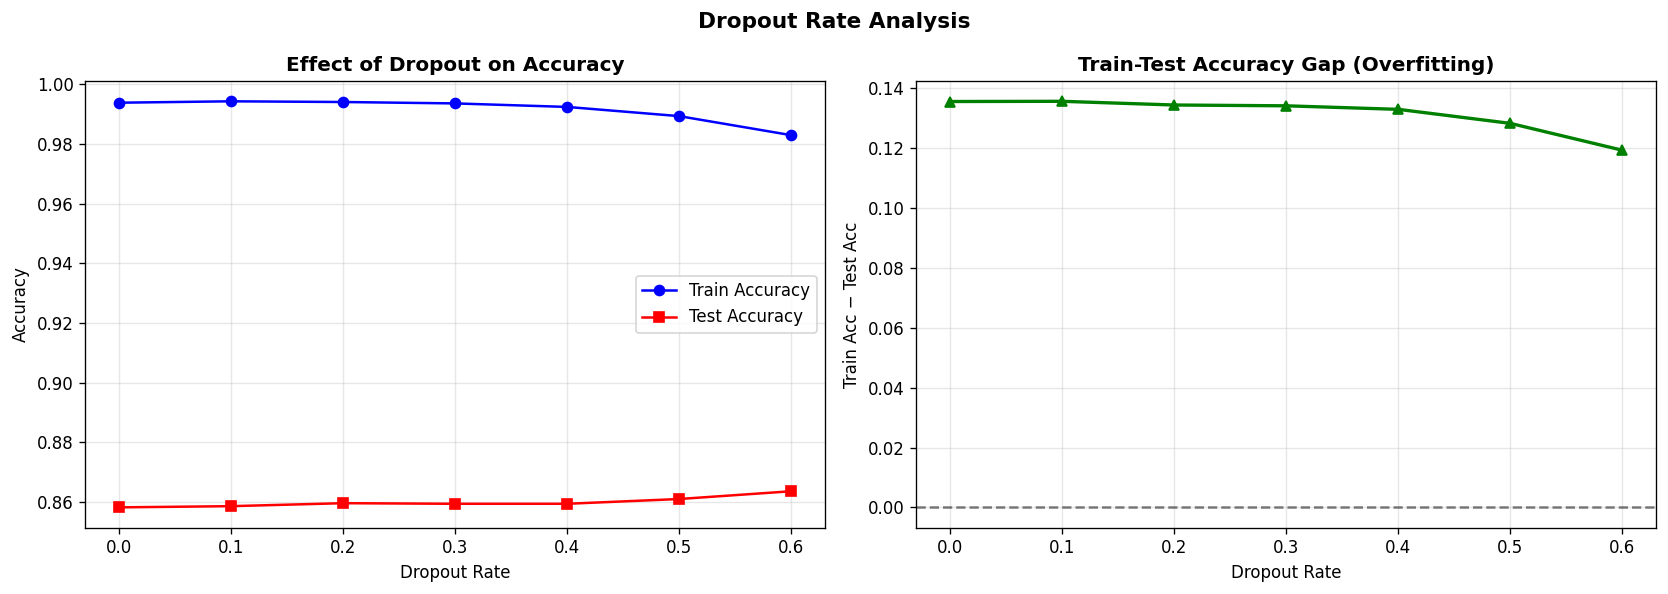

In [66]:
# ── 8.3  Dropout Rate Experiment ─────────────────────────────────────────
print('Experiment 3: Dropout Rate')
print('Fixed: TF-IDF bigram, hidden=512, relu, adam lr=1e-3')

dropout_results = {}

for dr in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    model = build_nn(X_train_tfidf.shape[1], hidden_size=512,
                     activation='relu', dropout_rate=dr)
    history = model.fit(
        X_train_tfidf, y_train, validation_data=(X_val_tfidf, y_val),
        epochs=CONFIG['epochs'], batch_size=64,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_loss', patience=CONFIG['patience'],
                                  restore_best_weights=True)],
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_test_tfidf, verbose=0), axis=1)
    acc_tr = history.history['accuracy'][-1]
    acc    = accuracy_score(y_test, y_pred)
    gap    = acc_tr - acc   # Train-Test gap = overfitting indicator
    dropout_results[dr] = {'test_acc': acc, 'train_acc': acc_tr, 'gap': gap}
    print(f'  Dropout={dr:.1f}: Test={acc:.4f}, Train={acc_tr:.4f}, Gap={gap:.4f}')

drs = list(dropout_results.keys())
test_accs  = [v['test_acc']  for v in dropout_results.values()]
train_accs = [v['train_acc'] for v in dropout_results.values()]
gaps       = [v['gap']       for v in dropout_results.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(drs, train_accs, 'b-o', label='Train Accuracy')
axes[0].plot(drs, test_accs,  'r-s', label='Test Accuracy')
axes[0].set_title('Effect of Dropout on Accuracy', fontweight='bold')
axes[0].set_xlabel('Dropout Rate')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(drs, gaps, 'g-^', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Train-Test Accuracy Gap (Overfitting)', fontweight='bold')
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Train Acc − Test Acc')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Dropout Rate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
